### ✨ CONCERNS ✨

#### CONCERN 1: SINGLE ANNOTATOR PROBLEM

##### Step 1 — Export 1,000 Random Samples for Second Annotator

In [ ]:
import os, json
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
DATA_PATH    = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")
OUT_DIR      = os.path.join(PROJECT_ROOT, "08_annotation")
os.makedirs(OUT_DIR, exist_ok=True)

rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["sentence"]      = df["sentence"].fillna("").astype(str)
df["idiom_word"]    = df["idiom_word"].fillna("").astype(str)
df["idiom_meaning"] = df["idiom_meaning"].fillna("").astype(str)
df["s_label"]       = df["s_label"].astype(int)

print(f"Total samples  : {len(df):,}")
print(f"Unique idioms  : {df['idiom_word'].nunique():,}")
print(f"Label dist     : {df['s_label'].value_counts().to_dict()}")

df_correct   = df[df["s_label"] == 1].sample(n=500, random_state=42)
df_incorrect = df[df["s_label"] == 0].sample(n=500, random_state=42)

df_sample = pd.concat([df_correct, df_incorrect]).sample(frac=1, random_state=42).reset_index(drop=True)
df_sample["sample_id"] = [f"S{i+1:04d}" for i in range(len(df_sample))]

print(f"\nSampled       : {len(df_sample):,}")
print(f"Label dist    : {df_sample['s_label'].value_counts().to_dict()}")

full_export = df_sample[[
    "sample_id", "idiom_word", "idiom_meaning", "sentence", "s_label"
]].copy()
full_export.to_csv(os.path.join(OUT_DIR, "annotation_1000_with_original_label.csv"),
                   index=False, encoding="utf-8-sig")

annotator_file = df_sample[[
    "sample_id", "idiom_word", "idiom_meaning", "sentence"
]].copy()
annotator_file["label_annotator_2"] = ""

annotator_file.to_csv(os.path.join(OUT_DIR, "annotation_1000_for_second_annotator.csv"),
                      index=False, encoding="utf-8-sig")

print(f"\n✅ Files saved → {OUT_DIR}")
print("\nFiles created:")
print("  1. annotation_1000_with_original_label.csv  → YOUR COPY (keep private)")
print("  2. annotation_1000_for_second_annotator.csv → SEND THIS to second annotator")
print("\nInstructions for second annotator:")
print("  - Read each row carefully")
print("  - idiom_word  = the Bangla idiom")
print("  - idiom_meaning = literal meaning of the idiom")
print("  - sentence    = the sentence using the idiom")
print("  - Fill column label_annotator_2:")
print("      1 = idiom used CORRECTLY (idiomatic/figurative meaning)")
print("      0 = idiom used INCORRECTLY (literal/wrong meaning)")

##### Step 2 — Cohen's Kappa (Run AFTER annotator returns file)

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix

PROJECT_ROOT  = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
ANNOT_DIR     = os.path.join(PROJECT_ROOT, "08_annotation")
OUT_DIR       = ANNOT_DIR

original_df  = pd.read_csv(os.path.join(ANNOT_DIR, "annotation_1000_with_original_label.csv"))
annotator_df = pd.read_csv(os.path.join(ANNOT_DIR, "annotation_1000_for_second_annotator_completed.csv"))

merged = original_df.merge(annotator_df[["sample_id", "label_annotator_2"]], on="sample_id")
merged = merged.rename(columns={"s_label": "label_annotator_1"})

assert len(merged) == 1000, f"Expected 1000 rows, got {len(merged)}"
assert merged["label_annotator_2"].notna().all(), "Missing labels from second annotator!"
assert merged["label_annotator_2"].isin([0, 1]).all(), "Labels must be 0 or 1 only!"

print("=" * 60)
print("ANNOTATION RELIABILITY ANALYSIS")
print("=" * 60)
print(f"\nTotal samples reviewed : {len(merged):,}")
print(f"\nAnnotator 1 label dist : {merged['label_annotator_1'].value_counts().to_dict()}")
print(f"Annotator 2 label dist : {merged['label_annotator_2'].value_counts().to_dict()}")

kappa = cohen_kappa_score(
    merged["label_annotator_1"],
    merged["label_annotator_2"]
)

agreement = (merged["label_annotator_1"] == merged["label_annotator_2"]).mean()
disagreements = (merged["label_annotator_1"] != merged["label_annotator_2"]).sum()

print(f"\n{'=' * 60}")
print(f"Cohen's Kappa Score    : {round(kappa, 4)}")
print(f"Raw Agreement          : {agreement*100:.2f}%")
print(f"Disagreements          : {disagreements} / {len(merged)}")
print(f"{'=' * 60}")

if kappa >= 0.81:
    interp = "Almost Perfect Agreement"
elif kappa >= 0.61:
    interp = "Substantial Agreement"
elif kappa >= 0.41:
    interp = "Moderate Agreement"
elif kappa >= 0.21:
    interp = "Fair Agreement"
else:
    interp = "Poor Agreement"

print(f"Interpretation         : {interp}")

print(f"\n{'=' * 60}")
print("DISAGREEMENT BREAKDOWN")
print(f"{'=' * 60}")

disagree_df = merged[merged["label_annotator_1"] != merged["label_annotator_2"]].copy()

a1_1_a2_0 = ((disagree_df["label_annotator_1"]==1) & (disagree_df["label_annotator_2"]==0)).sum()
a1_0_a2_1 = ((disagree_df["label_annotator_1"]==0) & (disagree_df["label_annotator_2"]==1)).sum()

print(f"Annotator1=1, Annotator2=0 : {a1_1_a2_0} cases")
print(f"Annotator1=0, Annotator2=1 : {a1_0_a2_1} cases")

print(f"\nSample disagreement cases (first 10):")
print(disagree_df[["sample_id","idiom_word","sentence",
                    "label_annotator_1","label_annotator_2"]].head(10).to_string(index=False))

cm = confusion_matrix(merged["label_annotator_1"], merged["label_annotator_2"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["A2: Incorrect(0)", "A2: Correct(1)"],
            yticklabels=["A1: Incorrect(0)", "A1: Correct(1)"],
            annot_kws={"size": 13, "weight": "bold"})
ax.set_title(f"Inter-Annotator Agreement\nCohen's κ = {round(kappa, 3)}", fontsize=12)
ax.set_xlabel("Annotator 2", fontsize=11)
ax.set_ylabel("Annotator 1", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "inter_annotator_agreement.png"), dpi=300, bbox_inches="tight")
plt.close()

results = {
    "total_samples"     : int(len(merged)),
    "cohen_kappa"       : round(float(kappa), 4),
    "raw_agreement_pct" : round(float(agreement * 100), 2),
    "disagreements"     : int(disagreements),
    "interpretation"    : interp,
    "a1_correct_a2_incorrect" : int(a1_1_a2_0),
    "a1_incorrect_a2_correct" : int(a1_0_a2_1),
}

with open(os.path.join(OUT_DIR, "kappa_results.json"), "w") as f:
    json.dump(results, f, indent=2)

merged.to_csv(os.path.join(OUT_DIR, "annotation_merged_final.csv"),
              index=False, encoding="utf-8-sig")

print(f"\n✅ All saved → {OUT_DIR}")
print("\nFiles created:")
print("  1. kappa_results.json               → Kappa score and stats")
print("  2. annotation_merged_final.csv      → Merged labels both annotators")
print("  3. inter_annotator_agreement.png    → Confusion matrix plot")

print(f"""
{'=' * 60}
COPY THIS INTO YOUR THESIS (Section 3.6.2)
{'=' * 60}

A randomly selected subset of 1,000 instances (500 correct,
500 incorrect usage) was independently annotated by a second
native Bangla speaker. Inter-annotator agreement was measured
using Cohen's kappa (κ = {round(kappa, 3)}), indicating {interp.lower()}.
Raw label agreement was {agreement*100:.1f}% ({disagreements} disagreements
out of 1,000 instances). Disagreements were resolved through
discussion with reference to the predefined annotation protocol
covering semantic coherence, pragmatic appropriateness, logical
consistency, and syntactic naturalness. This validation confirms
the reliability of the binary correctness labels used throughout
this study.
""")

ANNOTATION RELIABILITY ANALYSIS

Total samples reviewed : 1,000

Annotator 1 label dist : {0: 500, 1: 500}
Annotator 2 label dist : {1: 529, 0: 471}

Cohen's Kappa Score    : 0.874
Raw Agreement          : 93.70%
Disagreements          : 63 / 1000
Interpretation         : Almost Perfect Agreement

DISAGREEMENT BREAKDOWN
Annotator1=1, Annotator2=0 : 17 cases
Annotator1=0, Annotator2=1 : 46 cases

Sample disagreement cases (first 10):
sample_id            idiom_word                                                                                                                                     sentence  label_annotator_1  label_annotator_2
    S0572               অপোগণ্ড                                                                      রকিব জন্ম থেকেই অপোগণ্ড কারণে গ্রামের লোকজন তাকে কোনো কাজে নিতে চায় না                  1                  0
    S0598             আগাগাছতলা                                                                                                            জা

#### CONCERN 2: IDIOM LEAKAGE ANALYSIS

In [ ]:
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report
)
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
DATA_PATH    = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")

BB_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "model")
BB_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "tokenizer")

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "idiom_leakage_analysis")
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)

rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["sentence"]      = df["sentence"].fillna("").astype(str)
df["idiom_word"]    = df["idiom_word"].fillna("").astype(str)
df["idiom_meaning"] = df["idiom_meaning"].fillna("").astype(str)
df["s_label"]       = df["s_label"].astype(int)

print(f"Total samples  : {len(df):,}")
print(f"Unique idioms  : {df['idiom_word'].nunique():,}")
print(f"Label dist     : {df['s_label'].value_counts().to_dict()}")

print("\n" + "=" * 60)
print("2. IDIOM-DISJOINT SPLIT (70 / 15 / 15)")
print("=" * 60)

groups = df["idiom_word"].values

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss1.split(df, df["s_label"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

groups_temp = temp_df["idiom_word"].values
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, temp_df["s_label"], groups=groups_temp))

val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(train_df):,} samples | {train_df['idiom_word'].nunique():,} idioms")
print(f"Val   : {len(val_df):,} samples  | {val_df['idiom_word'].nunique():,} idioms")
print(f"Test  : {len(test_df):,} samples  | {test_df['idiom_word'].nunique():,} idioms")

print("\n" + "=" * 60)
print("3. LEAKAGE CHECK")
print("=" * 60)

train_idioms = set(train_df["idiom_word"])
val_idioms   = set(val_df["idiom_word"])
test_idioms  = set(test_df["idiom_word"])

assert train_idioms.isdisjoint(val_idioms),  "LEAK: train ∩ val is not empty!"
assert train_idioms.isdisjoint(test_idioms), "LEAK: train ∩ test is not empty!"
assert val_idioms.isdisjoint(test_idioms),   "LEAK: val ∩ test is not empty!"

print("✅ No idiom overlap between any splits — zero leakage confirmed.")

split_info = {
    "train_samples": int(len(train_df)),
    "val_samples":   int(len(val_df)),
    "test_samples":  int(len(test_df)),
    "train_idioms":  int(train_df['idiom_word'].nunique()),
    "val_idioms":    int(val_df['idiom_word'].nunique()),
    "test_idioms":   int(test_df['idiom_word'].nunique()),
    "train_label_dist": train_df['s_label'].value_counts().to_dict(),
    "val_label_dist":   val_df['s_label'].value_counts().to_dict(),
    "test_label_dist":  test_df['s_label'].value_counts().to_dict(),
}
with open(os.path.join(OUT_DIR, "idiom_split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

print("\n" + "=" * 60)
print("4. LOADING BANGLABERT (pretrained on original random split)")
print("=" * 60)

device       = "cuda" if torch.cuda.is_available() else "cpu"
bb_tokenizer = AutoTokenizer.from_pretrained(BB_TOKENIZER_DIR)
bb_model     = AutoModelForSequenceClassification.from_pretrained(BB_MODEL_DIR).to(device)
bb_model.eval()
print(f"✅ BanglaBERT loaded | Device: {device}")

def predict_batch(sentences, idiom_words, idiom_meanings, batch_size=32):
    texts = [
        f"বাগধারা: {w} । অর্থ: {m} । বাক্য: {s}"
        for s, w, m in zip(sentences, idiom_words, idiom_meanings)
    ]
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = bb_tokenizer(
            batch, max_length=192, truncation=True,
            padding=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = bb_model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs.tolist())
    return np.array(all_probs)

def compute_metrics(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "split":     split_name,
        "n_samples": int(len(y_true)),
        "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1":        round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc":   round(float(roc_auc_score(y_true, y_prob)), 4),
    }
    return metrics, y_pred

print("\n" + "=" * 60)
print("5. EVALUATION ON UNSEEN IDIOMS (idiom-disjoint test set)")
print("=" * 60)

te_probs = predict_batch(
    test_df["sentence"].tolist(),
    test_df["idiom_word"].tolist(),
    test_df["idiom_meaning"].tolist()
)
unseen_metrics, te_preds = compute_metrics(
    test_df["s_label"].values, te_probs, threshold=0.5, split_name="Unseen Idioms"
)

print(f"\nUNSEEN IDIOMS ({unseen_metrics['n_samples']} samples):")
for k, v in unseen_metrics.items():
    print(f"  {k}: {v}")
print("\nClassification Report:")
print(classification_report(test_df["s_label"].values, te_preds, digits=4))

print("\n" + "=" * 60)
print("6. EVALUATION ON SEEN IDIOMS (original random-split test set)")
print("=" * 60)

ORIG_TEST_PRED_PATH = os.path.join(
    PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "predictions_test.csv"
)
orig_test_df = pd.read_csv(ORIG_TEST_PRED_PATH)

seen_metrics, _ = compute_metrics(
    orig_test_df["y_true"].values,
    orig_test_df["prob_1"].values,
    threshold=0.5,
    split_name="Seen Idioms"
)

print(f"\nSEEN IDIOMS ({seen_metrics['n_samples']} samples):")
for k, v in seen_metrics.items():
    print(f"  {k}: {v}")

print("\n" + "=" * 60)
print("7. REVIEWER TABLE: SEEN vs UNSEEN IDIOMS")
print("=" * 60)

comparison = pd.DataFrame([seen_metrics, unseen_metrics])
comparison = comparison[["split", "n_samples", "accuracy", "precision", "recall", "f1", "roc_auc"]]

print(comparison.to_string(index=False))

comparison.to_csv(os.path.join(OUT_DIR, "seen_vs_unseen_idioms.csv"), index=False)
with open(os.path.join(OUT_DIR, "seen_vs_unseen_idioms.json"), "w") as f:
    json.dump({"seen": seen_metrics, "unseen": unseen_metrics}, f, indent=2)

pd.DataFrame({
    "idiom_word": test_df["idiom_word"].values,
    "sentence":   test_df["sentence"].values,
    "y_true":     test_df["s_label"].values,
    "y_pred":     te_preds,
    "prob_1":     te_probs,
}).to_csv(os.path.join(OUT_DIR, "unseen_idiom_predictions.csv"), index=False)

print(f"\n✅ All results saved → {OUT_DIR}")
print("\nFor your thesis, report this table:")
print(comparison[["split", "f1", "roc_auc", "accuracy"]].to_string(index=False))

#### CONCERN 3: STATISTICAL SIGNIFICANCE — MCNEMAR'S TEST

In [ ]:
import os, json
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

BB_PRED   = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                         "three", "BanglaBERT", "predictions_test.csv")
MBERT_PRED = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                          "three", "mBERT", "predictions_test.csv")
XLMR_PRED  = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                          "three", "XLMR", "predictions_test.csv")

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "statistical_significance")
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 60)
print("LOADING PREDICTIONS")
print("=" * 60)

bb_df    = pd.read_csv(BB_PRED)
mbert_df = pd.read_csv(MBERT_PRED)
xlmr_df  = pd.read_csv(XLMR_PRED)

y_true      = bb_df["y_true"].values.astype(int)
bb_pred     = bb_df["y_pred"].values.astype(int)
mbert_pred  = mbert_df["y_pred"].values.astype(int)
xlmr_pred   = xlmr_df["y_pred"].values.astype(int)

print(f"Test samples      : {len(y_true):,}")
print(f"BanglaBERT correct: {(bb_pred == y_true).sum():,}")
print(f"mBERT correct     : {(mbert_pred == y_true).sum():,}")
print(f"XLM-R correct     : {(xlmr_pred == y_true).sum():,}")

def run_mcnemar(y_true, pred_a, pred_b, name_a, name_b):
    """
    Build contingency table and run McNemar's test.

    Contingency table:
                        Model B correct   Model B wrong
    Model A correct         n00               n01
    Model A wrong           n10               n11

    McNemar focuses on OFF-DIAGONAL cells (n01 and n10)
    where the two models DISAGREE in their correctness.
    """
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    n00 = int(( correct_a &  correct_b).sum())  # both correct
    n01 = int(( correct_a & ~correct_b).sum())  # A correct, B wrong
    n10 = int((~correct_a &  correct_b).sum())  # A wrong, B correct
    n11 = int((~correct_a & ~correct_b).sum())  # both wrong

    table = np.array([[n00, n01],
                      [n10, n11]])

    result = mcnemar(table, exact=False, correction=True)

    statistic = float(result.statistic)
    p_value   = float(result.pvalue)
    significant = p_value < 0.05

    print(f"\n{'─' * 60}")
    print(f"  {name_a}  vs  {name_b}")
    print(f"{'─' * 60}")
    print(f"  Contingency Table:")
    print(f"                    {name_b} Correct  {name_b} Wrong")
    print(f"  {name_a} Correct      {n00:>6}          {n01:>6}")
    print(f"  {name_a} Wrong        {n10:>6}          {n11:>6}")
    print(f"\n  Off-diagonal: n01={n01}, n10={n10}")
    print(f"  McNemar χ²  : {statistic:.4f}")
    print(f"  p-value     : {p_value:.6f}")
    print(f"  Significant : {'✅ YES (p < 0.05)' if significant else '❌ NO (p ≥ 0.05)'}")

    return {
        "comparison"  : f"{name_a} vs {name_b}",
        "model_a"     : name_a,
        "model_b"     : name_b,
        "n00_both_correct"  : n00,
        "n01_a_correct_b_wrong" : n01,
        "n10_a_wrong_b_correct" : n10,
        "n11_both_wrong"    : n11,
        "mcnemar_chi2"      : round(statistic, 4),
        "p_value"           : round(p_value, 6),
        "significant_005"   : significant,
        "interpretation"    : "Significant difference" if significant else "No significant difference"
    }, table

print("\n" + "=" * 60)
print("McNEMAR'S TEST RESULTS")
print("=" * 60)

results = []

# Test 1: BanglaBERT vs mBERT
r1, t1 = run_mcnemar(y_true, bb_pred, mbert_pred, "BanglaBERT", "mBERT")
results.append(r1)

# Test 2: BanglaBERT vs XLM-R
r2, t2 = run_mcnemar(y_true, bb_pred, xlmr_pred, "BanglaBERT", "XLM-R")
results.append(r2)

# Test 3: XLM-R vs mBERT
r3, t3 = run_mcnemar(y_true, xlmr_pred, mbert_pred, "XLM-R", "mBERT")
results.append(r3)

print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)

df_results = pd.DataFrame(results)
print(df_results[[
    "comparison", "mcnemar_chi2", "p_value",
    "significant_005", "interpretation"
]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparisons = [
    (t1, "BanglaBERT vs mBERT"),
    (t2, "BanglaBERT vs XLM-R"),
    (t3, "XLM-R vs mBERT"),
]

for ax, (table, title) in zip(axes, comparisons):
    sns.heatmap(
        table, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["B Correct", "B Wrong"],
        yticklabels=["A Correct", "A Wrong"],
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Model B", fontsize=10)
    ax.set_ylabel("Model A", fontsize=10)

plt.suptitle("McNemar's Test — Contingency Tables",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "mcnemar_contingency_tables.png"),
            dpi=300, bbox_inches="tight")
plt.close()

df_results.to_csv(os.path.join(OUT_DIR, "mcnemar_results.csv"), index=False)

with open(os.path.join(OUT_DIR, "mcnemar_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✅ All saved → {OUT_DIR}")
print("\nFiles created:")
print("  1. mcnemar_results.csv              → Full results table")
print("  2. mcnemar_results.json             → Results in JSON")
print("  3. mcnemar_contingency_tables.png   → Visual contingency matrices")

print(f"""
{'=' * 60}
COPY THIS INTO YOUR THESIS (Statistical Analysis section)
{'=' * 60}

Pairwise statistical comparison between BanglaBERT and the
competing transformer baselines (mBERT and XLM-RoBERTa) was
performed using McNemar's test (McNemar, 1947) on paired
test-set predictions (n = {len(y_true):,}). McNemar's test evaluates
whether two classifiers make significantly different error
patterns on the same held-out examples, making it appropriate
for paired binary classification comparisons. Statistical
significance was assessed at α = 0.05 with continuity correction
applied.

BanglaBERT vs mBERT  : χ²={r1['mcnemar_chi2']}, p={r1['p_value']} → {r1['interpretation']}
BanglaBERT vs XLM-R  : χ²={r2['mcnemar_chi2']}, p={r2['p_value']} → {r2['interpretation']}
XLM-R vs mBERT       : χ²={r3['mcnemar_chi2']}, p={r3['p_value']} → {r3['interpretation']}

The results confirm that BanglaBERT's performance advantage
over competing transformer models is statistically significant,
ruling out random variation as an explanation for the observed
differences in classification accuracy.
""")

#### CONCERN 4: HUMAN EVALUATION OF GENERATED EXPLANATIONS


##### STEP 1 — Template Inflation Analysis

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

GEN_CSV = os.path.join(PROJECT_ROOT, "06_results", "t5_reason",
                       "stage2_gold", "test_generations.csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "09_human_eval")
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(GEN_CSV)
total = len(df)

print("=" * 60)
print("STEP 1: TEMPLATE INFLATION ANALYSIS")
print("=" * 60)
print(f"Total test samples: {total:,}")

TEMPLATE_LABEL1_FIXED_PARTS = [
    "বাগধারাটির অর্থ হলো",
    "সঠিকভাবে ব্যবহৃত হয়েছে",
]

TEMPLATE_LABEL0_FIXED_PARTS = [
    "বাগধারাটির অর্থ হলো",
    "যা ভুল",
]

TEMPLATE_SHARED = [
    "উক্ত",
    "বাগধারাটির অর্থ হলো",
]

def classify_reference(text):
    text = str(text).strip()
    has_correct   = "সঠিকভাবে ব্যবহৃত হয়েছে" in text
    has_incorrect = "যা ভুল" in text
    has_shared    = "বাগধারাটির অর্থ হলো" in text

    if has_shared and has_correct:
        return "semi_template_correct"
    elif has_shared and has_incorrect:
        return "semi_template_incorrect"
    elif has_shared:
        return "semi_template_other"
    else:
        return "free_form"

def classify_generated(text):
    text = str(text).strip()
    has_correct   = "সঠিকভাবে ব্যবহৃত হয়েছে" in text
    has_incorrect = "যা ভুল" in text
    has_shared    = "বাগধারাটির অর্থ হলো" in text

    if has_shared and has_correct:
        return "semi_template_correct"
    elif has_shared and has_incorrect:
        return "semi_template_incorrect"
    elif has_shared:
        return "semi_template_other"
    else:
        return "free_form"

df["ref_type"] = df["target_text"].apply(classify_reference)
df["gen_type"] = df["generated_text"].apply(classify_generated)

print("\nREFERENCE TEXT breakdown:")
ref_counts = df["ref_type"].value_counts()
for k, v in ref_counts.items():
    print(f"  {k:35s}: {v:,}  ({v/total*100:.1f}%)")

print("\nGENERATED TEXT breakdown:")
gen_counts = df["gen_type"].value_counts()
for k, v in gen_counts.items():
    print(f"  {k:35s}: {v:,}  ({v/total*100:.1f}%)")

perfect_rouge = (df["rougeL_f1"] >= 0.99).sum()
perfect_bleu  = (df["bleu4"]     >= 0.99).sum()
high_rouge    = (df["rougeL_f1"] >= 0.90).sum()

print(f"\nScore spike analysis:")
print(f"  ROUGE-L = 1.00 (perfect) : {perfect_rouge:,}  ({perfect_rouge/total*100:.1f}%)")
print(f"  ROUGE-L >= 0.90          : {high_rouge:,}  ({high_rouge/total*100:.1f}%)")
print(f"  BLEU-4  = 1.00 (perfect) : {perfect_bleu:,}  ({perfect_bleu/total*100:.1f}%)")

print("\nROUGE-L F1 by reference type:")
for t in df["ref_type"].unique():
    subset = df[df["ref_type"] == t]["rougeL_f1"]
    print(f"  {t:35s}: mean={subset.mean():.4f}  "
          f"median={subset.median():.4f}  n={len(subset):,}")

print("\nBLEU-4 by reference type:")
for t in df["ref_type"].unique():
    subset = df[df["ref_type"] == t]["bleu4"]
    print(f"  {t:35s}: mean={subset.mean():.4f}  "
          f"median={subset.median():.4f}  n={len(subset):,}")

print("\n" + "=" * 60)
print("WHY ROUGE=1.0 HAPPENS — EXAMPLE")
print("=" * 60)

perfect_df = df[df["rougeL_f1"] >= 0.99].head(3)
for _, row in perfect_df.iterrows():
    print(f"\nReference : {row['target_text']}")
    print(f"Generated : {row['generated_text']}")
    print(f"ROUGE-L   : {row['rougeL_f1']:.4f}")
    print(f"Ref type  : {row['ref_type']}")

print("\n" + "=" * 60)
print("FREE FORM EXAMPLES (non-template)")
print("=" * 60)

free_df = df[df["ref_type"] == "free_form"].head(3)
if len(free_df) > 0:
    for _, row in free_df.iterrows():
        print(f"\nReference : {row['target_text']}")
        print(f"Generated : {row['generated_text']}")
        print(f"ROUGE-L   : {row['rougeL_f1']:.4f}")
else:
    print("No free-form references found — all are semi-templated")

semi_template = df[df["ref_type"] != "free_form"]
free_form     = df[df["ref_type"] == "free_form"]

print("\n" + "=" * 60)
print("HONEST METRIC BREAKDOWN")
print("=" * 60)
print(f"\nOverall (all {total:,} samples):")
print(f"  ROUGE-L mean : {df['rougeL_f1'].mean():.4f}")
print(f"  BLEU-4  mean : {df['bleu4'].mean():.4f}")

if len(semi_template) > 0:
    print(f"\nSemi-template (n={len(semi_template):,}):")
    print(f"  ROUGE-L mean : {semi_template['rougeL_f1'].mean():.4f}")
    print(f"  BLEU-4  mean : {semi_template['bleu4'].mean():.4f}")

if len(free_form) > 0:
    print(f"\nFree-form (n={len(free_form):,}):")
    print(f"  ROUGE-L mean : {free_form['rougeL_f1'].mean():.4f}")
    print(f"  BLEU-4  mean : {free_form['bleu4'].mean():.4f}")

summary = {
    "total"              : int(total),
    "perfect_rouge_count": int(perfect_rouge),
    "perfect_rouge_pct"  : round(perfect_rouge/total*100, 1),
    "perfect_bleu_count" : int(perfect_bleu),
    "perfect_bleu_pct"   : round(perfect_bleu/total*100, 1),
    "rouge_overall_mean" : round(float(df["rougeL_f1"].mean()), 4),
    "bleu_overall_mean"  : round(float(df["bleu4"].mean()), 4),
    "ref_type_counts"    : ref_counts.to_dict(),
    "gen_type_counts"    : gen_counts.to_dict(),
}

with open(os.path.join(OUT_DIR, "template_analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

df.to_csv(
    os.path.join(OUT_DIR, "test_generations_with_types.csv"),
    index=False, encoding="utf-8-sig"
)

print(f"\n✅ Saved → {OUT_DIR}")
print("Files:")
print("  1. template_analysis_summary.json")
print("  2. test_generations_with_types.csv")

##### STEP 2 — Export 200 Samples for Human Evaluators

In [ ]:
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

GEN_CSV   = os.path.join(PROJECT_ROOT, "09_human_eval",
                         "test_generations_with_types.csv")
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
OUT_DIR   = os.path.join(PROJECT_ROOT, "09_human_eval")

df = pd.read_csv(GEN_CSV)

type_counts = df["ref_type"].value_counts()
print("Reference type distribution:")
print(type_counts)

df_correct   = df[df["ref_type"] == "semi_template_correct"]
df_incorrect = df[df["ref_type"] == "semi_template_incorrect"]
df_free      = df[df["ref_type"] == "free_form"]

n_correct   = min(100, len(df_correct))
n_incorrect = min(100, len(df_incorrect))

sample_parts = []

if n_correct > 0:
    sample_parts.append(
        df_correct.sample(n=n_correct, random_state=42)
    )
if n_incorrect > 0:
    sample_parts.append(
        df_incorrect.sample(n=n_incorrect, random_state=42)
    )

current_total = sum(len(p) for p in sample_parts)
if len(df_free) > 0 and current_total < 200:
    n_free = min(200 - current_total, len(df_free))
    sample_parts.append(df_free.sample(n=n_free, random_state=42))

df_sample = pd.concat(sample_parts)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample["eval_id"] = [f"E{i+1:03d}" for i in range(len(df_sample))]

print(f"\nFinal sample: {len(df_sample)} items")
print(df_sample["ref_type"].value_counts())

s_te = np.load(os.path.join(RAW_DIR, "test", "sentence.npy"),
               allow_pickle=True).astype(str)
w_te = np.load(os.path.join(RAW_DIR, "test", "idiom_word.npy"),
               allow_pickle=True).astype(str)
m_te = np.load(os.path.join(RAW_DIR, "test", "idiom_meaning.npy"),
               allow_pickle=True).astype(str)
y_te = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

raw_df = pd.DataFrame({
    "sentence"     : s_te,
    "idiom_word"   : w_te,
    "idiom_meaning": m_te,
    "s_label"      : y_te,
})

sample_idx = df_sample.index.tolist()
matched    = raw_df.iloc[sample_idx].reset_index(drop=True)

eval_sheet = pd.DataFrame({
    "eval_id"              : df_sample["eval_id"].values,
    "idiom_word"           : matched["idiom_word"].values,
    "idiom_meaning"        : matched["idiom_meaning"].values,
    "sentence"             : matched["sentence"].values,
    "usage_label"          : matched["s_label"].map(
                                {1:"সঠিক ব্যবহার", 0:"ভুল ব্যবহার"}).values,
    "generated_explanation": df_sample["generated_text"].values,
    "fluency_1to5"         : "",
    "correctness_1to5"     : "",
    "usefulness_1to5"      : "",
    "comments"             : "",
})

private_copy = eval_sheet.copy()
private_copy["reference_explanation"] = df_sample["target_text"].values
private_copy["rougeL_f1"]             = df_sample["rougeL_f1"].values
private_copy["bleu4"]                 = df_sample["bleu4"].values
private_copy["ref_type"]              = df_sample["ref_type"].values

eval_sheet.to_csv(
    os.path.join(OUT_DIR, "human_eval_200_for_evaluators.csv"),
    index=False, encoding="utf-8-sig"
)
private_copy.to_csv(
    os.path.join(OUT_DIR, "human_eval_200_private_copy.csv"),
    index=False, encoding="utf-8-sig"
)

print(f"\n✅ Saved → {OUT_DIR}")
print("Files:")
print("  1. human_eval_200_for_evaluators.csv  → SEND TO EVALUATORS")
print("  2. human_eval_200_private_copy.csv    → YOUR COPY ONLY")

##### STEP 3 — Compute Results After Evaluators Return

In [ ]:
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

GEN_CSV   = os.path.join(PROJECT_ROOT, "09_human_eval",
                         "test_generations_with_types.csv")
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
OUT_DIR   = os.path.join(PROJECT_ROOT, "09_human_eval")

df = pd.read_csv(GEN_CSV)

type_counts = df["ref_type"].value_counts()
print("Reference type distribution:")
print(type_counts)

df_correct   = df[df["ref_type"] == "semi_template_correct"]
df_incorrect = df[df["ref_type"] == "semi_template_incorrect"]
df_free      = df[df["ref_type"] == "free_form"]

n_correct   = min(100, len(df_correct))
n_incorrect = min(100, len(df_incorrect))

sample_parts = []

if n_correct > 0:
    sample_parts.append(
        df_correct.sample(n=n_correct, random_state=42)
    )
if n_incorrect > 0:
    sample_parts.append(
        df_incorrect.sample(n=n_incorrect, random_state=42)
    )

current_total = sum(len(p) for p in sample_parts)
if len(df_free) > 0 and current_total < 200:
    n_free = min(200 - current_total, len(df_free))
    sample_parts.append(df_free.sample(n=n_free, random_state=42))

df_sample = pd.concat(sample_parts)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample["eval_id"] = [f"E{i+1:03d}" for i in range(len(df_sample))]

print(f"\nFinal sample: {len(df_sample)} items")
print(df_sample["ref_type"].value_counts())

s_te = np.load(os.path.join(RAW_DIR, "test", "sentence.npy"),
               allow_pickle=True).astype(str)
w_te = np.load(os.path.join(RAW_DIR, "test", "idiom_word.npy"),
               allow_pickle=True).astype(str)
m_te = np.load(os.path.join(RAW_DIR, "test", "idiom_meaning.npy"),
               allow_pickle=True).astype(str)
y_te = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

raw_df = pd.DataFrame({
    "sentence"     : s_te,
    "idiom_word"   : w_te,
    "idiom_meaning": m_te,
    "s_label"      : y_te,
})

sample_idx = df_sample.index.tolist()
matched    = raw_df.iloc[sample_idx].reset_index(drop=True)

eval_sheet = pd.DataFrame({
    "eval_id"              : df_sample["eval_id"].values,
    "idiom_word"           : matched["idiom_word"].values,
    "idiom_meaning"        : matched["idiom_meaning"].values,
    "sentence"             : matched["sentence"].values,
    "usage_label"          : matched["s_label"].map(
                                {1:"সঠিক ব্যবহার", 0:"ভুল ব্যবহার"}).values,
    "generated_explanation": df_sample["generated_text"].values,
    "fluency_1to5"         : "",
    "correctness_1to5"     : "",
    "usefulness_1to5"      : "",
    "comments"             : "",
})

private_copy = eval_sheet.copy()
private_copy["reference_explanation"] = df_sample["target_text"].values
private_copy["rougeL_f1"]             = df_sample["rougeL_f1"].values
private_copy["bleu4"]                 = df_sample["bleu4"].values
private_copy["ref_type"]              = df_sample["ref_type"].values

eval_sheet.to_csv(
    os.path.join(OUT_DIR, "human_eval_200_for_evaluators.csv"),
    index=False, encoding="utf-8-sig"
)
private_copy.to_csv(
    os.path.join(OUT_DIR, "human_eval_200_private_copy.csv"),
    index=False, encoding="utf-8-sig"
)

print(f"\n✅ Saved → {OUT_DIR}")
print("Files:")
print("  1. human_eval_200_for_evaluators.csv  → SEND TO EVALUATORS")
print("  2. human_eval_200_private_copy.csv    → YOUR COPY ONLY")

### ✨ TESTING ✨

In [ ]:
import unicodedata

def normalize_bangla(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200c", "")
    text = text.replace("\u200d", "")
    text = " ".join(text.split())
    return text

inputs = [
    "বড়লোকটি  ছেলেটিকে \u200cঅর্ধচন্দ্র  দিয়ে   বের করে  দিলেন",
    "মালিকের\u200c সামনে   বেশি\u200dবলায়\u200c   তাকে  অর্ধচন্দ্র \u200dপেতে\u00a0হলো",
    "অফিসে   দেরি  করায়\n   ম্যানেজার\u200c তাকে  অর্ধচন্দ্র \u200dদিলেন",
    "কৃষক\tঅর্ধচন্দ্র   দিয়ে \u200cঘাস \u200dকাটছে",
    "আমি  বাগানে \u200c\u200dঅর্ধচন্দ্র    দেখেছি"
]

print("INPUT:")
print("-" * 80)
for i, sentence in enumerate(inputs, 1):
    print(f"{i}. {sentence}")

print("OUTPUT:")
print("-" * 80)
for i, sentence in enumerate(inputs, 1):
    print(f"{i}. {normalize_bangla(sentence)}")

In [ ]:
import os
import numpy as np
import pickle
from scipy.sparse import load_npz

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

SPLIT_DIR    = os.path.join(PROJECT_ROOT, "02_splits")
LABELS_DIR   = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_ML_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")
TEXT_RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")

print("=" * 80)
print("📊 FEATURE EXTRACTION OUTPUT SUMMARY")
print("=" * 80)

print("\n" + "=" * 80)
print("1️⃣  DATASET SPLITS")
print("=" * 80)

train_idx = np.load(os.path.join(SPLIT_DIR, "train_idx.npy"))
val_idx   = np.load(os.path.join(SPLIT_DIR, "val_idx.npy"))
test_idx  = np.load(os.path.join(SPLIT_DIR, "test_idx.npy"))

print(f"\n📁 Split Directory: {SPLIT_DIR}")
print(f"\n   Train samples: {len(train_idx):,}")
print(f"   Val samples:   {len(val_idx):,}")
print(f"   Test samples:  {len(test_idx):,}")
print(f"   Total:         {len(train_idx) + len(val_idx) + len(test_idx):,}")

ratio_train = len(train_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100
ratio_val   = len(val_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100
ratio_test  = len(test_idx) / (len(train_idx) + len(val_idx) + len(test_idx)) * 100

print(f"\n   Split Ratio: {ratio_train:.1f}% / {ratio_val:.1f}% / {ratio_test:.1f}%")

print("\n" + "=" * 80)
print("2️⃣  LABELS DISTRIBUTION")
print("=" * 80)

y_train = np.load(os.path.join(LABELS_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABELS_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABELS_DIR, "y_test.npy"))

print(f"\n📁 Labels Directory: {LABELS_DIR}")

def show_label_dist(y, name):
    counts = np.bincount(y)
    print(f"\n   {name}:")
    for i, count in enumerate(counts):
        pct = count / len(y) * 100
        print(f"      Class {i}: {count:,} ({pct:.1f}%)")

show_label_dist(y_train, "Train")
show_label_dist(y_val,   "Validation")
show_label_dist(y_test,  "Test")

print("\n" + "=" * 80)
print("3️⃣  RAW TEXT FIELDS (DL/Transformers)")
print("=" * 80)

print(f"\n📁 Raw Text Directory: {TEXT_RAW_DIR}")
print("\n   Available splits:")

for split_name in ["train", "val", "test"]:
    split_path = os.path.join(TEXT_RAW_DIR, split_name)
    if os.path.exists(split_path):
        print(f"\n   • {split_name.upper()}:")
        for field in ["sentence", "idiom_word", "idiom_meaning"]:
            field_path = os.path.join(split_path, f"{field}.npy")
            if os.path.exists(field_path):
                data = np.load(field_path, allow_pickle=True)
                print(f"      - {field}.npy: {len(data):,} samples")
                # Show a sample
                if len(data) > 0:
                    sample = str(data[0])
                    if len(sample) > 60:
                        sample = sample[:60] + "..."
                    print(f"        Sample: {sample}")

print("\n" + "=" * 80)
print("4️⃣  ML FEATURES (TF-IDF - Three Fields)")
print("=" * 80)

print(f"\n📁 ML Features Directory: {FEAT_ML_THREE}")

X_train = load_npz(os.path.join(FEAT_ML_THREE, "X_train.npz"))
X_val   = load_npz(os.path.join(FEAT_ML_THREE, "X_val.npz"))
X_test  = load_npz(os.path.join(FEAT_ML_THREE, "X_test.npz"))

print(f"\n   Feature Matrix Shapes:")
print(f"      Train: {X_train.shape} ({X_train.nnz:,} non-zero values)")
print(f"      Val:   {X_val.shape} ({X_val.nnz:,} non-zero values)")
print(f"      Test:  {X_test.shape} ({X_test.nnz:,} non-zero values)")

print(f"\n   Sparsity:")
print(f"      Train: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")
print(f"      Val:   {(1 - X_val.nnz / (X_val.shape[0] * X_val.shape[1])) * 100:.2f}%")
print(f"      Test:  {(1 - X_test.nnz / (X_test.shape[0] * X_test.shape[1])) * 100:.2f}%")

with open(os.path.join(FEAT_ML_THREE, "sentence_vectorizer.pkl"), "rb") as f:
    vec_sent = pickle.load(f)
with open(os.path.join(FEAT_ML_THREE, "meaning_vectorizer.pkl"), "rb") as f:
    vec_mean = pickle.load(f)
with open(os.path.join(FEAT_ML_THREE, "idiom_vectorizer.pkl"), "rb") as f:
    vec_idm = pickle.load(f)

print(f"\n   Vectorizer Configurations:")
print(f"\n      Sentence Vectorizer:")
print(f"         - Analyzer: {vec_sent.analyzer}")
print(f"         - N-gram range: {vec_sent.ngram_range}")
print(f"         - Max features: {vec_sent.max_features}")
print(f"         - Vocabulary size: {len(vec_sent.vocabulary_):,}")

print(f"\n      Idiom Meaning Vectorizer:")
print(f"         - Analyzer: {vec_mean.analyzer}")
print(f"         - N-gram range: {vec_mean.ngram_range}")
print(f"         - Max features: {vec_mean.max_features}")
print(f"         - Vocabulary size: {len(vec_mean.vocabulary_):,}")

print(f"\n      Idiom Word Vectorizer:")
print(f"         - Analyzer: {vec_idm.analyzer}")
print(f"         - N-gram range: {vec_idm.ngram_range}")
print(f"         - Max features: {vec_idm.max_features}")
print(f"         - Vocabulary size: {len(vec_idm.vocabulary_):,}")

print("\n" + "=" * 80)
print("5️⃣  FEATURE DIMENSION BREAKDOWN")
print("=" * 80)

sent_features = len(vec_sent.vocabulary_)
mean_features = len(vec_mean.vocabulary_)
idm_features  = len(vec_idm.vocabulary_)
total_features = sent_features + mean_features + idm_features

print(f"\n   Sentence features:      {sent_features:,} ({sent_features/total_features*100:.1f}%)")
print(f"   Idiom meaning features: {mean_features:,} ({mean_features/total_features*100:.1f}%)")
print(f"   Idiom word features:    {idm_features:,} ({idm_features/total_features*100:.1f}%)")
print(f"   " + "-" * 60)
print(f"   Total features:         {total_features:,}")

print("\n" + "=" * 80)
print("6️⃣  TOP TF-IDF FEATURES (Sample)")
print("=" * 80)

def show_top_features(vectorizer, name, n=10):
    feature_names = vectorizer.get_feature_names_out()
    print(f"\n   {name} - Top {n} features:")
    for i, feat in enumerate(feature_names[:n], 1):
        print(f"      {i:2d}. {feat}")

show_top_features(vec_sent, "Sentence", 10)
show_top_features(vec_mean, "Idiom Meaning", 10)
show_top_features(vec_idm, "Idiom Word", 10)

print("\n" + "=" * 80)
print("7️⃣  STORAGE SIZE")
print("=" * 80)

def get_dir_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total

def format_size(bytes):
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes < 1024.0:
            return f"{bytes:.2f} {unit}"
        bytes /= 1024.0
    return f"{bytes:.2f} TB"

print(f"\n   Splits:      {format_size(get_dir_size(SPLIT_DIR))}")
print(f"   Labels:      {format_size(get_dir_size(LABELS_DIR))}")
print(f"   Raw Text:    {format_size(get_dir_size(TEXT_RAW_DIR))}")
print(f"   ML Features: {format_size(get_dir_size(FEAT_ML_THREE))}")

print("\n" + "=" * 80)
print("✅ SUMMARY")
print("=" * 80)

print(f"""
   Dataset Split:    {len(train_idx):,} / {len(val_idx):,} / {len(test_idx):,} (Train/Val/Test)
   Total Features:   {total_features:,} (TF-IDF)
   Feature Format:   Sparse CSR matrices
   Label Classes:    {len(np.unique(y_train))}

   ✅ All feature extraction outputs are ready for model training!
""")

print("=" * 80)

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix

PROJECT_ROOT  = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
BB_DIR        = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")
OUT_DIR       = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG  = os.path.join(OUT_DIR, "fig2_banglabert_confusion_matrix.png")
OUT_PDF  = os.path.join(OUT_DIR, "fig2_banglabert_confusion_matrix.pdf")

pred_path = os.path.join(BB_DIR, "predictions_test.csv")
df_pred   = pd.read_csv(pred_path)

y_test = df_pred["y_true"].values.astype(int)
y_pred = df_pred["y_pred"].values.astype(int)

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
total     = tn + fp + fn + tp
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)
accuracy  = (tp + tn) / total

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}  Acc={accuracy:.4f}")

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        9,
    "axes.titlesize":   10,
    "axes.labelsize":   9,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "axes.linewidth":   0.6,
    "xtick.major.width":0.6,
    "ytick.major.width":0.6,
})

fig, ax = plt.subplots(figsize=(3.5, 3.2))

cmap = plt.cm.Blues

im = ax.imshow(cm, interpolation="nearest", cmap=cmap, aspect="auto")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Count", fontsize=8)

classes = ["Incorrect (0)", "Correct (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=8.5)
ax.set_yticklabels(classes, fontsize=8.5)

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = count / total * 100
        color = "white" if count > thresh else "black"
        ax.text(j, i,
                f"{count:,}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_xlabel("Predicted label", labelpad=6)
ax.set_ylabel("True label",      labelpad=6)

metric_str = (
    f"Accuracy: {accuracy*100:.1f}%   "
    f"Precision: {precision*100:.1f}%   "
    f"Recall: {recall*100:.1f}%   "
    f"F1: {f1*100:.1f}%"
)
fig.text(0.5, -0.04, metric_str, ha="center", fontsize=7.5,
         color="#444444", style="italic")

plt.tight_layout(pad=0.8)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"\n✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")
print("\nSpringer caption (copy into your manuscript):")
print("Fig. 2 Confusion matrix for BanglaBERT on the held-out test set "
      f"(n = {total:,}). Values show instance counts and row-normalised "
      "percentages. TN = true negative, FP = false positive, "
      "FN = false negative, TP = true positive.")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
OUT_DIR      = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG = os.path.join(OUT_DIR, "fig3_all12_roc_curves.png")
OUT_PDF = os.path.join(OUT_DIR, "fig3_all12_roc_curves.pdf")

MODELS = [
    ("LR",          os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR",         "predictions_test.csv"), "ml"),
    ("SVM",         os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM",        "predictions_test.csv"), "ml"),
    ("NB",          os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB",         "predictions_test.csv"), "ml"),
    ("ML Ensemble", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE",   "predictions_test.csv"), "ml"),
    ("BiLSTM",      os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM",     "predictions_test.csv"), "dl"),
    ("BiGRU",       os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU",      "predictions_test.csv"), "dl"),
    ("DNN",         os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN",        "predictions_test.csv"), "dl"),
    ("CNN",         os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN",        "predictions_test.csv"), "dl"),
    ("DL Ensemble", os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE",   "predictions_test.csv"), "dl"),
    ("mBERT",       os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT",      "predictions_test.csv"), "transformer"),
    ("XLM-RoBERTa", os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR",       "predictions_test.csv"), "transformer"),
    ("BanglaBERT",  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT", "predictions_test.csv"), "transformer"),
]

GROUP_STYLES = {
    "ml": {
        "colors":    ["#1565C0", "#1976D2", "#42A5F5", "#90CAF9"],
        "linestyle": "solid",
        "linewidth": 1.0,
        "alpha":     0.85,
    },
    "dl": {
        "colors":    ["#E65100", "#F57C00", "#FFA726", "#66BB6A", "#A5D6A7"],
        "linestyle": "dashed",
        "linewidth": 1.0,
        "alpha":     0.85,
    },
    "transformer": {
        "colors":    ["#6A1B9A", "#8E24AA", "#C62828"],
        "linestyle": "solid",
        "linewidth": 2.2,
        "alpha":     1.0,
    },
}

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "axes.linewidth":    0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize":   7.5,
    "legend.framealpha": 0.92,
    "legend.edgecolor":  "#cccccc",
})

fig, ax = plt.subplots(figsize=(6.5, 5.2))

group_idx    = {"ml": 0, "dl": 0, "transformer": 0}
loaded_models = []

for name, pred_path, group in MODELS:
    if not os.path.exists(pred_path):
        print(f"⚠️  Missing: {pred_path}")
        continue

    df      = pd.read_csv(pred_path)
    y_true  = df["y_true"].values.astype(int)
    y_score = df["prob_1"].values.astype(float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc     = auc(fpr, tpr)

    style = GROUP_STYLES[group]
    color = style["colors"][group_idx[group] % len(style["colors"])]
    group_idx[group] += 1

    lw    = 2.8  if name == "BanglaBERT" else style["linewidth"]
    alpha = 1.0  if name == "BanglaBERT" else style["alpha"]
    zord  = 10   if name == "BanglaBERT" else 5

    ax.plot(
        fpr, tpr,
        color=color,
        linestyle=style["linestyle"],
        linewidth=lw,
        alpha=alpha,
        zorder=zord,
        label=f"{name} (AUC = {roc_auc:.2f})"
    )

    loaded_models.append(name)
    print(f"✅ {name:20s}  AUC = {roc_auc:.4f}")

ax.plot([0, 1], [0, 1],
        color="#aaaaaa", linewidth=0.8,
        linestyle="dotted", zorder=1,
        label="Random (AUC = 0.50)")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel("False positive rate", labelpad=5)
ax.set_ylabel("True positive rate",  labelpad=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)

handles, labels = ax.get_legend_handles_labels()

ml_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["LR", "SVM", "NB", "ML Ens"])]
dl_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["BiLSTM", "BiGRU", "DNN", "CNN", "DL Ens"])]
tr_h  = [(h, l) for h, l in zip(handles, labels) if any(n in l for n in ["mBERT", "XLM", "BanglaBERT"])]
rnd_h = [(h, l) for h, l in zip(handles, labels) if "Random" in l]

ordered_h = []
ordered_l = []

for group_label, group_items in [
    ("Traditional ML", ml_h),
    ("Deep Learning",  dl_h),
    ("Transformer",    tr_h),
    ("",               rnd_h),
]:
    if group_items:
        ordered_h.append(Line2D([], [], color="none"))
        ordered_l.append(f"$\\bf{{{group_label}}}$" if group_label else "")
        for h, l in group_items:
            ordered_h.append(h)
            ordered_l.append(l)

legend = ax.legend(
    ordered_h, ordered_l,
    loc="lower right",
    ncol=1,
    framealpha=0.92,
    edgecolor="#cccccc",
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0.6,
    labelspacing=0.35,
    fontsize=7.2,
)

for text in legend.get_texts():
    if text.get_text().startswith("$\\bf"):
        text.set_color("#555555")

plt.tight_layout(pad=0.8)

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

print(f"\n✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")
print(f"\nModels plotted: {len(loaded_models)}/12")
print("\nSpringer caption (copy into your manuscript):")
print(
    "Fig. 3 ROC curves for all twelve classification models on the held-out "
    "test set (n = 2,351). Models are grouped by paradigm: traditional machine "
    "learning (thin solid lines), deep learning (dashed lines) and "
    "transformer-based models (bold solid lines). AUC values are reported in "
    "the legend. BanglaBERT achieves the highest AUC of 0.98."
)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

PLOT_ORDER = [
    ("Logistic Regression",    os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR"        )),
    ("Support Vector Machine", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM"       )),
    ("Naive Bayes",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB"        )),
    ("ML Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE"  )),
    ("BiLSTM",                 os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM"    )),
    ("BiGRU",                  os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU"     )),
    ("DNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN"       )),
    ("CNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN"       )),
    ("DL Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE"  )),
    ("BanglaBERT",             os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")),
    ("mBERT",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT"     )),
    ("XLM-R",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR"      )),
]

COLOR_TRAIN = "#1f77b4"
COLOR_VAL   = "#ff7f0e"

plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "font.size":      8,
    "axes.linewidth": 0.7,
})

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

fig.suptitle(
    "ROC Curves — All 12 Models (Train vs Validation)",
    fontsize=18, fontweight="bold", y=0.98, color="#1A1A2E"
)

# ROW_LABELS = [
#     ("ML Models",                    0.945),
#     ("Deep Learning Models",         0.647),
#     ("DL Ensemble  &  Transformers", 0.348),
# ]
# for label, ypos in ROW_LABELS:
#     fig.text(0.5, ypos, label, ha="center", fontsize=11,
#              fontweight="bold", color="#555555", style="italic")

for idx, (name, folder) in enumerate(PLOT_ORDER):
    ax = axes[idx]
    ax.set_facecolor("white")

    train_path = os.path.join(folder, "predictions_train.csv")
    val_path   = os.path.join(folder, "predictions_val.csv")

    if not os.path.exists(train_path) or not os.path.exists(val_path):
        ax.text(0.5, 0.5, "Missing CSV files",
                transform=ax.transAxes, ha="center",
                va="center", fontsize=9, color="#AAAAAA")
        ax.set_title(name, fontsize=10, fontweight="bold", color="#1A1A2E")
        ax.set_facecolor("#F9F9F9")
        continue

    df_tr = pd.read_csv(train_path)
    df_va = pd.read_csv(val_path)

    fpr_tr, tpr_tr, _ = roc_curve(df_tr["y_true"], df_tr["prob_1"])
    fpr_va, tpr_va, _ = roc_curve(df_va["y_true"], df_va["prob_1"])

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_va = auc(fpr_va, tpr_va)

    ax.plot(fpr_tr, tpr_tr,
            color=COLOR_TRAIN, lw=2.5, linestyle="-",
            label=f"Train AUC={auc_tr:.2f}")
    ax.plot(fpr_va, tpr_va,
            color=COLOR_VAL,   lw=2.5, linestyle="-",
            label=f"Val AUC={auc_va:.2f}")
    ax.plot([0, 1], [0, 1],
            color="#AAAAAA", lw=1.2, linestyle="--")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(name, fontsize=10, fontweight="bold",
                 color="#1A1A2E", pad=5)
    ax.set_xlabel("False Positive Rate", fontsize=8.5, color="#333")
    ax.set_ylabel("True Positive Rate",  fontsize=8.5, color="#333")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.tick_params(labelsize=8, colors="#444")

    ax.legend(
        fontsize=8.5,
        loc="lower right",
        framealpha=0.9,
        edgecolor="#CCCCCC",
        handlelength=2.0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.grid(True, linestyle="--", linewidth=0.5,
            color="#CCCCCC", alpha=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.955])

OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "all_12_roc_curves_train_val.png")
OUT_PDF = os.path.join(PROJECT_ROOT, "06_results", "all_12_roc_curves_train_val.pdf")

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(OUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"✅ Saved PNG → {OUT_PNG}")
print(f"✅ Saved PDF → {OUT_PDF}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc

matplotlib.rcdefaults()

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          7,
    "axes.linewidth":     0.6,
    "axes.facecolor":     "white",
    "figure.facecolor":   "white",
    "savefig.facecolor":  "white",
    "figure.dpi":         300,
    "savefig.dpi":        300,
})

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

PLOT_ORDER = [
    ("Logistic Regression",    os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "LR"        )),
    ("Support Vector Machine", os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "SVM"       )),
    ("Naive Bayes",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "NB"        )),
    ("ML Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "ml",           "three", "ENSEMBLE"  )),
    ("BiLSTM",                 os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiLSTM"    )),
    ("BiGRU",                  os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "BiGRU"     )),
    ("DNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "DNN"       )),
    ("CNN",                    os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "CNN"       )),
    ("DL Ensemble",            os.path.join(PROJECT_ROOT, "06_results", "dl",           "three", "ENSEMBLE"  )),
    ("BanglaBERT",             os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")),
    ("mBERT",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT"     )),
    ("XLM-R",                  os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR"      )),
]

COLOR_TRAIN = "#1f77b4"    # blue
COLOR_VAL   = "#ff7f0e"    # orange
COLOR_DIAG  = "#AAAAAA"    # grey

FIG_W_IN = 7.09
FIG_H_IN = 6.30

fig, axes = plt.subplots(
    3, 4,
    figsize=(FIG_W_IN, FIG_H_IN),
    facecolor="white"
)
axes = axes.flatten()

fig.suptitle(
    "ROC Curves — All 12 Models (Train vs Validation)",
    fontsize=8, fontweight="bold", y=0.995, color="black"
)

for idx, (name, folder) in enumerate(PLOT_ORDER):
    ax = axes[idx]
    ax.set_facecolor("white")

    train_path = os.path.join(folder, "predictions_train.csv")
    val_path   = os.path.join(folder, "predictions_val.csv")

    if not os.path.exists(train_path) or not os.path.exists(val_path):
        ax.text(0.5, 0.5, "Missing CSV",
                transform=ax.transAxes, ha="center",
                va="center", fontsize=7, color="#AAAAAA")
        ax.set_title(name, fontsize=7, fontweight="bold", color="black")
        continue

    df_tr = pd.read_csv(train_path)
    df_va = pd.read_csv(val_path)

    fpr_tr, tpr_tr, _ = roc_curve(df_tr["y_true"].values.astype(int),
                                   df_tr["prob_1"].values.astype(float))
    fpr_va, tpr_va, _ = roc_curve(df_va["y_true"].values.astype(int),
                                   df_va["prob_1"].values.astype(float))

    auc_tr = auc(fpr_tr, tpr_tr)
    auc_va = auc(fpr_va, tpr_va)

    ax.plot(fpr_tr, tpr_tr,
            color=COLOR_TRAIN, lw=1.5, linestyle="-",
            label=f"Train AUC={auc_tr:.2f}")
    ax.plot(fpr_va, tpr_va,
            color=COLOR_VAL,   lw=1.5, linestyle="-",
            label=f"Val AUC={auc_va:.2f}")
    ax.plot([0, 1], [0, 1],
            color=COLOR_DIAG,  lw=0.8, linestyle="--")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(name, fontsize=7, fontweight="bold", color="black", pad=3)
    ax.set_xlabel("False Positive Rate", fontsize=6.5, color="black")
    ax.set_ylabel("True Positive Rate",  fontsize=6.5, color="black")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.tick_params(labelsize=6, colors="black")
    ax.legend(fontsize=6, loc="lower right",
              framealpha=0.9, edgecolor="#CCCCCC",
              handlelength=1.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.grid(True, linestyle="--", linewidth=0.4,
            color="#CCCCCC", alpha=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.992], h_pad=1.8, w_pad=1.2)

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results", "journal_figures")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG = os.path.join(OUT_DIR, "fig_all12_roc_springer.png")
OUT_PDF = os.path.join(OUT_DIR, "fig_all12_roc_springer.pdf")

fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
fig.savefig(OUT_PDF, dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.close(fig)

print(f"✅ PNG → {OUT_PNG}")
print(f"✅ PDF → {OUT_PDF}")
print(f"   Figure size: {FIG_W_IN:.2f} × {FIG_H_IN:.2f} inches  ({FIG_W_IN*25.4:.0f} × {FIG_H_IN*25.4:.0f} mm)")
print(f"   Springer limit: 180 × 220 mm  ✅ Within bounds")

In [ ]:
import json
import csv

input_file = "INPUT_DATASET.jsonl"
output_file = "output.csv"

fieldnames = ["idiom_word","idiom_meaning","sentence","i_label","s_label","reason"]

with open(input_file, "r", encoding="utf-8") as infile, \
     open(output_file, "w", encoding="utf-8-sig", newline="") as outfile:

    writer = csv.DictWriter(outfile, fieldnames=fieldnames)
    writer.writeheader()

    for line in infile:
        data = json.loads(line)
        writer.writerow(data)

print("Done")

### ✨MOUNT DRIVE✨

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
BASE_DIR = "/content/drive/MyDrive/THESIS"

PROJECT_ROOT = os.path.join(BASE_DIR, "THESIS_PIPELINE")

DIRS = [
    "01_clean",
    "02_splits",
    "03_labels",
    "04_features/ml/single",
    "04_features/dl/single",
    "06_results/ml/single",
    "06_results/dl/single",
    "06_results/transformers/single",
]

for d in DIRS:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

print("✅ Project root:", PROJECT_ROOT)
print("✅ Folder structure ready.")

### ✨DATASET ANALYSIS✨

In [ ]:
import matplotlib.font_manager as fm
import requests

font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSerifBengali/NotoSerifBengali-Regular.ttf"
font_path = "/content/NotoSerifBengali-Regular.ttf"

response = requests.get(font_url)
with open(font_path, "wb") as f:
    f.write(response.content)

fm.fontManager.addfont(font_path)
bangla_font = fm.FontProperties(fname=font_path)


import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.gridspec import GridSpec

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

INPUT_JSONL = "/content/drive/MyDrive/THESIS/DATASETS/INPUT_DATASET.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/THESIS/DATASET_ANALYSIS"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("LOADING DATASET")
print("="*60)

data = []
with open(INPUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))

df = pd.DataFrame(data)
print(f"✅ Loaded {len(df)} instances")
print(f"✅ Columns: {list(df.columns)}")

print("\n" + "="*60)
print("BASIC DATASET STATISTICS")
print("="*60)

total_instances = len(df)
unique_idioms = df['idiom_word'].nunique()
avg_sentences_per_idiom = total_instances / unique_idioms

print(f"Total Instances: {total_instances:,}")
print(f"Unique Idioms Covered: {unique_idioms:,}")
print(f"Average Sentences per Idiom: {avg_sentences_per_idiom:.2f}")

if 's_label' in df.columns:
    s_label_dist = df['s_label'].value_counts().sort_index()
    print(f"\nUsage Correctness Label Distribution (s_label):")
    for label, count in s_label_dist.items():
        pct = (count / total_instances) * 100
        label_name = "Correct" if label == 1 else "Incorrect"
        print(f"  {label} ({label_name}): {count:,} instances ({pct:.2f}%)")

idiom_counts = df['idiom_word'].value_counts()
print(f"\nIdiom Distribution:")
print(f"  Min sentences per idiom: {idiom_counts.min()}")
print(f"  Max sentences per idiom: {idiom_counts.max()}")
print(f"  Mean sentences per idiom: {idiom_counts.mean():.2f}")
print(f"  Median sentences per idiom: {idiom_counts.median():.1f}")

print("\n" + "="*60)
print("SENTENCE FIELD: TEXT ANALYSIS")
print("="*60)

df['sentence_word_count'] = df['sentence'].apply(lambda x: len(str(x).split()))

print(f"\n📊 WORD-LEVEL STATISTICS:")
print(f"  Mean length: {df['sentence_word_count'].mean():.2f} words")
print(f"  Median length: {df['sentence_word_count'].median():.1f} words")
print(f"  Std deviation: {df['sentence_word_count'].std():.2f} words")
print(f"  Min length: {df['sentence_word_count'].min()} words")
print(f"  Max length: {df['sentence_word_count'].max()} words")
print(f"  25th percentile: {df['sentence_word_count'].quantile(0.25):.1f} words")
print(f"  75th percentile: {df['sentence_word_count'].quantile(0.75):.1f} words")
print(f"  90th percentile: {df['sentence_word_count'].quantile(0.90):.1f} words")
print(f"  95th percentile: {df['sentence_word_count'].quantile(0.95):.1f} words")

df['sentence_char_count'] = df['sentence'].str.len()

print(f"\n📊 CHARACTER-LEVEL STATISTICS:")
print(f"  Mean length: {df['sentence_char_count'].mean():.2f} characters")
print(f"  Median length: {df['sentence_char_count'].median():.1f} characters")
print(f"  Std deviation: {df['sentence_char_count'].std():.2f} characters")
print(f"  Min length: {df['sentence_char_count'].min()} characters")
print(f"  Max length: {df['sentence_char_count'].max()} characters")

print("\n" + "="*60)
print("SENTENCE FIELD: VOCABULARY RICHNESS")
print("="*60)

all_words = []
for sentence in df['sentence']:
    words = str(sentence).split()
    all_words.extend(words)

unique_vocab = set(all_words)
total_tokens = len(all_words)

print(f"\n📚 VOCABULARY SIZE:")
print(f"  Total tokens (words): {total_tokens:,}")
print(f"  Unique words (types): {len(unique_vocab):,}")

ttr = (len(unique_vocab) / total_tokens) * 100

print(f"\n📈 LEXICAL DIVERSITY:")
print(f"  Type-Token Ratio (TTR): {ttr:.2f}%")
print(f"  Interpretation:")
if ttr > 40:
    print(f"    → High diversity (TTR > 40%) - Rich vocabulary variation")
elif ttr > 30:
    print(f"    → Moderate diversity (30-40%) - Typical for focused domain text")
else:
    print(f"    → Lower diversity (TTR < 30%) - Some repetitive patterns")

word_freq = Counter(all_words)

hapax_words = [word for word, count in word_freq.items() if count == 1]
hapax_count = len(hapax_words)
hapax_pct = (hapax_count / len(unique_vocab)) * 100

print(f"\n📖 HAPAX LEGOMENA (words appearing only once):")
print(f"  Count: {hapax_count:,} words")
print(f"  Percentage of vocabulary: {hapax_pct:.2f}%")
print(f"  Interpretation:")
print(f"    → High hapax (>50%): Very diverse, many rare words")
print(f"    → Moderate hapax (30-50%): Balanced vocabulary")
print(f"    → Low hapax (<30%): More repetitive core vocabulary")

dis_words = [word for word, count in word_freq.items() if count == 2]
dis_count = len(dis_words)
dis_pct = (dis_count / len(unique_vocab)) * 100

print(f"\n📖 DIS LEGOMENA (words appearing exactly twice):")
print(f"  Count: {dis_count:,} words")
print(f"  Percentage of vocabulary: {dis_pct:.2f}%")

freq_bands = {
    "1 time (Hapax)": sum(1 for c in word_freq.values() if c == 1),
    "2 times": sum(1 for c in word_freq.values() if c == 2),
    "3-5 times": sum(1 for c in word_freq.values() if 3 <= c <= 5),
    "6-10 times": sum(1 for c in word_freq.values() if 6 <= c <= 10),
    "11-50 times": sum(1 for c in word_freq.values() if 11 <= c <= 50),
    "51-100 times": sum(1 for c in word_freq.values() if 51 <= c <= 100),
    "100+ times": sum(1 for c in word_freq.values() if c > 100)
}

print(f"\n📊 WORD FREQUENCY DISTRIBUTION:")
for band, count in freq_bands.items():
    pct = (count / len(unique_vocab)) * 100
    print(f"  {band}: {count:,} words ({pct:.2f}%)")

print("\n" + "="*60)
print("SENTENCE FIELD: MOST FREQUENT WORDS")
print("="*60)

top_50 = word_freq.most_common(50)

print(f"\n🔝 TOP 50 MOST FREQUENT WORDS:")
for rank, (word, count) in enumerate(top_50, 1):
    pct = (count / total_tokens) * 100
    print(f"  {rank:2d}. '{word}' → {count:,} occurrences ({pct:.3f}%)")

top_10_coverage = sum(count for _, count in word_freq.most_common(10)) / total_tokens * 100
top_50_coverage = sum(count for _, count in word_freq.most_common(50)) / total_tokens * 100
top_100_coverage = sum(count for _, count in word_freq.most_common(100)) / total_tokens * 100
top_500_coverage = sum(count for _, count in word_freq.most_common(500)) / total_tokens * 100

print(f"\n📊 VOCABULARY COVERAGE:")
print(f"  Top 10 words cover: {top_10_coverage:.2f}% of all tokens")
print(f"  Top 50 words cover: {top_50_coverage:.2f}% of all tokens")
print(f"  Top 100 words cover: {top_100_coverage:.2f}% of all tokens")
print(f"  Top 500 words cover: {top_500_coverage:.2f}% of all tokens")

print("\n" + "="*60)
print("SAVING STATISTICS")
print("="*60)

stats_summary = {
    "dataset_overview": {
        "total_instances": int(total_instances),
        "unique_idioms": int(unique_idioms),
        "avg_sentences_per_idiom": float(avg_sentences_per_idiom)
    },
    "label_distribution": {
        "s_label": {
            int(k): {
                "count": int(v),
                "percentage": float(v / total_instances * 100)
            } for k, v in s_label_dist.items()
        }
    },
    "sentence_text_statistics": {
        "word_level": {
            "mean": float(df['sentence_word_count'].mean()),
            "median": float(df['sentence_word_count'].median()),
            "std": float(df['sentence_word_count'].std()),
            "min": int(df['sentence_word_count'].min()),
            "max": int(df['sentence_word_count'].max()),
            "p25": float(df['sentence_word_count'].quantile(0.25)),
            "p50": float(df['sentence_word_count'].quantile(0.50)),
            "p75": float(df['sentence_word_count'].quantile(0.75)),
            "p90": float(df['sentence_word_count'].quantile(0.90)),
            "p95": float(df['sentence_word_count'].quantile(0.95))
        },
        "character_level": {
            "mean": float(df['sentence_char_count'].mean()),
            "median": float(df['sentence_char_count'].median()),
            "std": float(df['sentence_char_count'].std()),
            "min": int(df['sentence_char_count'].min()),
            "max": int(df['sentence_char_count'].max())
        }
    },
    "vocabulary_richness": {
        "total_tokens": total_tokens,
        "unique_words": len(unique_vocab),
        "type_token_ratio_percentage": float(ttr),
        "hapax_legomena": {
            "count": hapax_count,
            "percentage": float(hapax_pct)
        },
        "dis_legomena": {
            "count": dis_count,
            "percentage": float(dis_pct)
        },
        "frequency_distribution": freq_bands,
        "vocabulary_coverage": {
            "top_10_words": float(top_10_coverage),
            "top_50_words": float(top_50_coverage),
            "top_100_words": float(top_100_coverage),
            "top_500_words": float(top_500_coverage)
        }
    },
    "top_50_words": [
        {
            "rank": i,
            "word": word,
            "count": count,
            "percentage": float(count / total_tokens * 100)
        } for i, (word, count) in enumerate(top_50, 1)
    ]
}

with open(os.path.join(OUTPUT_DIR, "sentence_field_statistics.json"), "w", encoding="utf-8") as f:
    json.dump(stats_summary, f, indent=2, ensure_ascii=False)

print(f"✅ Saved statistics to: {OUTPUT_DIR}/sentence_field_statistics.json")

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
colors_labels = ['#e74c3c', '#27ae60']
s_label_dist.plot(kind='bar', ax=ax1, color=colors_labels, edgecolor='black', alpha=0.8)
ax1.set_title('Usage Correctness Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Label', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_xticklabels(['Incorrect (0)', 'Correct (1)'], rotation=0, fontsize=10)
for i, v in enumerate(s_label_dist):
    pct = v / total_instances * 100
    ax1.text(i, v + 100, f'{v:,} ({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['sentence_word_count'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(df['sentence_word_count'].mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {df["sentence_word_count"].mean():.1f}')
ax2.axvline(df['sentence_word_count'].median(), color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {df["sentence_word_count"].median():.1f}')
ax2.set_title('Sentence Length Distribution (Words)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Words', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['sentence_char_count'], bins=40, color='#9b59b6', edgecolor='black', alpha=0.7)
ax3.axvline(df['sentence_char_count'].mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {df["sentence_char_count"].mean():.0f}')
ax3.axvline(df['sentence_char_count'].median(), color='green', linestyle='--', linewidth=2.5,
            label=f'Median: {df["sentence_char_count"].median():.0f}')
ax3.set_title('Sentence Length Distribution (Characters)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Number of Characters', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
bp = ax4.boxplot(df['sentence_word_count'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5),
                 medianprops=dict(color='red', linewidth=2.5),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
ax4.set_title('Sentence Length Box Plot', fontsize=13, fontweight='bold')
ax4.set_ylabel('Number of Words', fontsize=11)
ax4.set_xticklabels(['All Sentences'], fontsize=10)
ax4.grid(alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[1, 1:])
top_20 = word_freq.most_common(20)
words_20, counts_20 = zip(*top_20)
y_pos = np.arange(len(words_20))
ax5.barh(y_pos, counts_20, color='#1abc9c', edgecolor='black', alpha=0.7)
ax5.set_yticks(y_pos)

ax5.set_yticklabels(words_20, fontproperties=bangla_font, fontsize=11)

ax5.invert_yaxis()
ax5.set_title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
ax5.set_xlabel('Frequency', fontsize=11)
for i, (word, count) in enumerate(top_20):
    pct = count / total_tokens * 100
    ax5.text(count + 20, i, f'{count:,} ({pct:.2f}%)', va='center', fontsize=9)
ax5.grid(alpha=0.3, axis='x')

ax6 = fig.add_subplot(gs[2, 0])
bands_names = list(freq_bands.keys())
bands_values = list(freq_bands.values())
colors_bands = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db']
ax6.bar(bands_names, bands_values, color=colors_bands, edgecolor='black', alpha=0.8)
ax6.set_title('Word Frequency Distribution', fontsize=13, fontweight='bold')
ax6.set_xlabel('Frequency Band', fontsize=11)
ax6.set_ylabel('Number of Words', fontsize=11)
ax6.set_xticklabels(bands_names, rotation=45, ha='right', fontsize=9)
for i, v in enumerate(bands_values):
    pct = v / len(unique_vocab) * 100
    ax6.text(i, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=8, fontweight='bold')
ax6.grid(alpha=0.3, axis='y')

ax7 = fig.add_subplot(gs[2, 1])
coverage_data = {
    'Top 10': top_10_coverage,
    'Top 50': top_50_coverage,
    'Top 100': top_100_coverage,
    'Top 500': top_500_coverage
}
colors_coverage = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
ax7.bar(coverage_data.keys(), coverage_data.values(), color=colors_coverage, edgecolor='black', alpha=0.8)
ax7.set_title('Vocabulary Coverage by Top N Words', fontsize=13, fontweight='bold')
ax7.set_ylabel('Coverage (%)', fontsize=11)
ax7.set_ylim(0, 100)
for i, (k, v) in enumerate(coverage_data.items()):
    ax7.text(i, v + 2, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

ax8 = fig.add_subplot(gs[2, 2])
richness_data = {
    'TTR': ttr,
    'Hapax %': hapax_pct,
    'Dis %': dis_pct
}
colors_rich = ['#3498db', '#9b59b6', '#e67e22']
ax8.bar(richness_data.keys(), richness_data.values(), color=colors_rich, edgecolor='black', alpha=0.8)
ax8.set_title('Vocabulary Richness Metrics', fontsize=13, fontweight='bold')
ax8.set_ylabel('Percentage (%)', fontsize=11)
for i, (k, v) in enumerate(richness_data.items()):
    ax8.text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

ax9 = fig.add_subplot(gs[3, 0])
idiom_freq_bins = idiom_counts.value_counts().sort_index()
ax9.bar(idiom_freq_bins.index, idiom_freq_bins.values, color='#e67e22', edgecolor='black', alpha=0.7)
ax9.set_title('Sentences per Idiom Distribution', fontsize=13, fontweight='bold')
ax9.set_xlabel('Number of Sentences', fontsize=11)
ax9.set_ylabel('Number of Idioms', fontsize=11)
ax9.grid(alpha=0.3, axis='y')

ax10 = fig.add_subplot(gs[3, 1])
sorted_freqs = sorted(word_freq.values(), reverse=True)
cumsum_freqs = np.cumsum(sorted_freqs)
cumsum_pct = (cumsum_freqs / total_tokens) * 100
ax10.plot(range(1, len(cumsum_pct) + 1), cumsum_pct, color='#3498db', linewidth=2.5)
ax10.set_title('Cumulative Word Frequency Distribution', fontsize=13, fontweight='bold')
ax10.set_xlabel('Word Rank', fontsize=11)
ax10.set_ylabel('Cumulative Coverage (%)', fontsize=11)
ax10.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% coverage')
ax10.axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% coverage')
ax10.legend(fontsize=10)
ax10.grid(alpha=0.3)
ax10.set_xlim(0, 5000)

ax11 = fig.add_subplot(gs[3, 2])
ax11.axis('off')
summary_text = f"""
SUMMARY STATISTICS

Dataset Size:
  • Total Instances: {total_instances:,}
  • Unique Idioms: {unique_idioms:,}

Sentence Length:
  • Mean: {df['sentence_word_count'].mean():.2f} words
  • Median: {df['sentence_word_count'].median():.1f} words
  • Range: {df['sentence_word_count'].min()}-{df['sentence_word_count'].max()} words

Vocabulary:
  • Total Tokens: {total_tokens:,}
  • Unique Words: {len(unique_vocab):,}
  • TTR: {ttr:.2f}%

Richness:
  • Hapax Legomena: {hapax_count:,} ({hapax_pct:.1f}%)
  • Dis Legomena: {dis_count:,} ({dis_pct:.1f}%)

Coverage:
  • Top 50 words: {top_50_coverage:.2f}%
  • Top 100 words: {top_100_coverage:.2f}%
"""
ax11.text(0.1, 0.95, summary_text, transform=ax11.transAxes,
          fontsize=11, verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Bangla Idiom Dataset: Sentence Field Text Analysis',
             fontsize=18, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, "sentence_text_analysis.png"), dpi=300, bbox_inches='tight')
print(f"✅ Saved visualization to: {OUTPUT_DIR}/sentence_text_analysis.png")

report_data = {
    'Metric': [
        'Total Instances',
        'Unique Idioms',
        'Correct Usage Count',
        'Incorrect Usage Count',
        'Mean Sentence Length (words)',
        'Median Sentence Length (words)',
        'Std Dev Sentence Length',
        'Min Sentence Length',
        'Max Sentence Length',
        'Mean Character Count',
        'Total Tokens',
        'Unique Words (Vocabulary)',
        'Type-Token Ratio (TTR) %',
        'Hapax Legomena Count',
        'Hapax Percentage %',
        'Dis Legomena Count',
        'Dis Legomena Percentage %',
        'Top 10 Words Coverage %',
        'Top 50 Words Coverage %',
        'Top 100 Words Coverage %'
    ],
    'Value': [
        f'{total_instances:,}',
        f'{unique_idioms:,}',
        f"{s_label_dist.get(1, 0):,} ({s_label_dist.get(1, 0)/total_instances*100:.2f}%)",
        f"{s_label_dist.get(0, 0):,} ({s_label_dist.get(0, 0)/total_instances*100:.2f}%)",
        f'{df["sentence_word_count"].mean():.2f}',
        f'{df["sentence_word_count"].median():.1f}',
        f'{df["sentence_word_count"].std():.2f}',
        f'{df["sentence_word_count"].min()}',
        f'{df["sentence_word_count"].max()}',
        f'{df["sentence_char_count"].mean():.2f}',
        f'{total_tokens:,}',
        f'{len(unique_vocab):,}',
        f'{ttr:.2f}%',
        f'{hapax_count:,}',
        f'{hapax_pct:.2f}%',
        f'{dis_count:,}',
        f'{dis_pct:.2f}%',
        f'{top_10_coverage:.2f}%',
        f'{top_50_coverage:.2f}%',
        f'{top_100_coverage:.2f}%'
    ]
}

report_df = pd.DataFrame(report_data)
report_df.to_csv(os.path.join(OUTPUT_DIR, "sentence_analysis_report.csv"),
                 index=False, encoding='utf-8-sig')
print(f"✅ Saved report to: {OUTPUT_DIR}/sentence_analysis_report.csv")

top_50_df = pd.DataFrame([
    {
        'Rank': i,
        'Word': word,
        'Count': count,
        'Percentage': f'{count/total_tokens*100:.3f}%'
    } for i, (word, count) in enumerate(top_50, 1)
])
top_50_df.to_csv(os.path.join(OUTPUT_DIR, "top_50_words.csv"),
                 index=False, encoding='utf-8-sig')
print(f"✅ Saved top words to: {OUTPUT_DIR}/top_50_words.csv")

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE")
print("="*60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("\nFiles created:")
print("  1. sentence_field_statistics.json - Complete statistics in JSON")
print("  2. sentence_text_analysis.png - Comprehensive visualizations")
print("  3. sentence_analysis_report.csv - Summary table")
print("  4. top_50_words.csv - Top 50 frequent words with stats")

### ✨PREPROCESSING✨

In [ ]:
import os
import json
import unicodedata

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
INPUT_JSONL = "/content/drive/MyDrive/THESIS/DATASETS/INPUT_DATASET.jsonl"

OUT_JSONL = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")
os.makedirs(os.path.dirname(OUT_JSONL), exist_ok=True)

def normalize_bangla(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200c", "")
    text = text.replace("\u200d", "")
    text = " ".join(text.split())
    return text

required_cols = ["sentence", "idiom_word", "idiom_meaning", "s_label"]

n_in = 0
n_out = 0
bad_lines = 0

with open(INPUT_JSONL, "r", encoding="utf-8") as fin, open(OUT_JSONL, "w", encoding="utf-8") as fout:
    for line in fin:
        n_in += 1
        line = line.strip()
        if not line:
            continue

        try:
            obj = json.loads(line)
        except Exception:
            bad_lines += 1
            continue

        for c in required_cols:
            if c not in obj:
                obj[c] = "" if c != "s_label" else 0

        obj["sentence"]      = normalize_bangla(obj["sentence"])
        obj["idiom_word"]    = normalize_bangla(obj["idiom_word"])
        obj["idiom_meaning"] = normalize_bangla(obj["idiom_meaning"])

        try:
            obj["s_label"] = int(obj["s_label"])
        except Exception:
            obj["s_label"] = 0

        fout.write(json.dumps(obj, ensure_ascii=False) + "\n")
        n_out += 1

print("✅ Normalization done")
print("📥 Lines read:", n_in)
print("📤 Lines written:", n_out)
print("⚠️ Bad JSON lines skipped:", bad_lines)
print("📁 Saved:", OUT_JSONL)

### ✨ML FEATURE EXTRACTION AND MODEL TRAINING✨

#### FEATURE EXTRACTION

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, save_npz

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_PATH = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")

SPLIT_DIR  = os.path.join(PROJECT_ROOT, "02_splits")
LABELS_DIR = os.path.join(PROJECT_ROOT, "03_labels")

FEAT_ML_THREE  = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")
TEXT_RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")

for d in [SPLIT_DIR, LABELS_DIR, FEAT_ML_THREE, TEXT_RAW_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Loading:", RAW_PATH)
df = pd.read_json(RAW_PATH, lines=True).reset_index(drop=True)

df["sentence"]      = df["sentence"].fillna("").astype(str)
df["idiom_word"]    = df["idiom_word"].fillna("").astype(str)
df["idiom_meaning"] = df["idiom_meaning"].fillna("").astype(str)
df["s_label"]       = df["s_label"].astype(int)

sentences      = df["sentence"].values
idiom_words    = df["idiom_word"].values
idiom_meanings = df["idiom_meaning"].values
labels         = df["s_label"].values

print(f"✅ Samples: {len(df)} | Label dist:", np.bincount(labels))

indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=42)

np.save(os.path.join(SPLIT_DIR, "train_idx.npy"), train_idx)
np.save(os.path.join(SPLIT_DIR, "val_idx.npy"),   val_idx)
np.save(os.path.join(SPLIT_DIR, "test_idx.npy"),  test_idx)

y_train, y_val, y_test = labels[train_idx], labels[val_idx], labels[test_idx]
np.save(os.path.join(LABELS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(LABELS_DIR, "y_val.npy"),   y_val)
np.save(os.path.join(LABELS_DIR, "y_test.npy"),  y_test)

print("✅ Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def save_raw_split(name, idx):
    out_dir = os.path.join(TEXT_RAW_DIR, name)
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "sentence.npy"),      sentences[idx])
    np.save(os.path.join(out_dir, "idiom_word.npy"),    idiom_words[idx])
    np.save(os.path.join(out_dir, "idiom_meaning.npy"), idiom_meanings[idx])

save_raw_split("train", train_idx)
save_raw_split("val",   val_idx)
save_raw_split("test",  test_idx)

print("✅ Saved DL/Transformer raw fields to:", TEXT_RAW_DIR)

X_train_3 = np.column_stack([sentences[train_idx], idiom_words[train_idx], idiom_meanings[train_idx]])
X_val_3   = np.column_stack([sentences[val_idx],   idiom_words[val_idx],   idiom_meanings[val_idx]])
X_test_3  = np.column_stack([sentences[test_idx],  idiom_words[test_idx],  idiom_meanings[test_idx]])

vec_sent = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 6), max_features=5000)
vec_mean = TfidfVectorizer(analyzer="word",   ngram_range=(1, 2), max_features=500)
vec_idm  = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=300)

X_train_sent = vec_sent.fit_transform(X_train_3[:, 0]); X_val_sent = vec_sent.transform(X_val_3[:, 0]); X_test_sent = vec_sent.transform(X_test_3[:, 0])
X_train_mean = vec_mean.fit_transform(X_train_3[:, 2]); X_val_mean = vec_mean.transform(X_val_3[:, 2]); X_test_mean = vec_mean.transform(X_test_3[:, 2])
X_train_idm  = vec_idm.fit_transform(X_train_3[:, 1]);  X_val_idm  = vec_idm.transform(X_val_3[:, 1]);  X_test_idm  = vec_idm.transform(X_test_3[:, 1])

X_train_three_feat = hstack([X_train_sent, X_train_mean, X_train_idm])
X_val_three_feat   = hstack([X_val_sent,   X_val_mean,   X_val_idm])
X_test_three_feat  = hstack([X_test_sent,  X_test_mean,  X_test_idm])

save_npz(os.path.join(FEAT_ML_THREE, "X_train.npz"), X_train_three_feat)
save_npz(os.path.join(FEAT_ML_THREE, "X_val.npz"),   X_val_three_feat)
save_npz(os.path.join(FEAT_ML_THREE, "X_test.npz"),  X_test_three_feat)

with open(os.path.join(FEAT_ML_THREE, "sentence_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_sent, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(FEAT_ML_THREE, "meaning_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_mean, f, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(FEAT_ML_THREE, "idiom_vectorizer.pkl"), "wb") as f:
    pickle.dump(vec_idm,  f, protocol=pickle.HIGHEST_PROTOCOL)

print("✅ ML THREE TF-IDF saved:", X_train_three_feat.shape)

print("\n✅ DONE: Now you can train ML/DL/Transformer models in THREE-FIELDS mode consistently.")
print("🔑 DL/Transformers will load raw fields from:", TEXT_RAW_DIR)

#### LR

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "LR")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "lr_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "lr_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_lr_elasticnet(C=1.0, l1_ratio=0.2):
    base_lr = LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=l1_ratio,
        C=C,
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )
    calibrated = CalibratedClassifierCV(base_lr, method="isotonic", cv="prefit")
    return base_lr, calibrated

def run_lr_three(feat_dir, out_dir, C=1.0, l1_ratio=0.2):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    base_lr, calibrated = make_lr_elasticnet(C, l1_ratio)
    base_lr.fit(X_train, y_train)
    calibrated.fit(X_val, y_val)

    tr_prob = base_lr.predict_proba(X_train)[:, 1]
    va_prob = calibrated.predict_proba(X_val)[:, 1]
    te_prob = calibrated.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": base_lr.get_params()
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(base_lr, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== LR Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_lr_three(FEAT_THREE, OUT_THREE, C=0.8, l1_ratio=0.2)

summary = {
    "LR_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### SVM

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "SVM")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "svm_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "svm_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_svm_linear_calibrated(C=1.0, max_iter=7000, calibrate_cv=5):
    base = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=max_iter,
        random_state=42
    )
    calibrated = CalibratedClassifierCV(base, cv=calibrate_cv)
    return calibrated

def run_svm_three(feat_dir, out_dir, C=1.0, max_iter=7000, calibrate_cv=5):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    model = make_svm_linear_calibrated(C=C, max_iter=max_iter, calibrate_cv=calibrate_cv)
    model.fit(X_train, y_train)

    tr_prob = model.predict_proba(X_train)[:, 1]
    va_prob = model.predict_proba(X_val)[:, 1]
    te_prob = model.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "C": C,
            "max_iter": max_iter,
            "calibrate_cv": calibrate_cv,
            "class_weight": "balanced",
            "random_state": 42
        }
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== SVM Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_svm_three(FEAT_THREE, OUT_THREE, C=0.2, max_iter=7000, calibrate_cv=5)

summary = {
    "SVM_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### NB

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "NB")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "nb_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "nb_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_nb_calibrated(alpha=1.0):
    base = MultinomialNB(alpha=alpha)
    calibrated = CalibratedClassifierCV(base, method="isotonic", cv="prefit")
    return base, calibrated

def run_nb_three(feat_dir, out_dir, alpha=1.0):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    base, calibrated = make_nb_calibrated(alpha=alpha)
    base.fit(X_train, y_train)
    calibrated.fit(X_val, y_val)

    tr_prob = base.predict_proba(X_train)[:, 1]
    va_prob = calibrated.predict_proba(X_val)[:, 1]
    te_prob = calibrated.predict_proba(X_test)[:, 1]

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {"alpha": alpha}
    }

    with open(os.path.join(out_dir, "model.pkl"), "wb") as f:
        pickle.dump(base, f, protocol=pickle.HIGHEST_PROTOCOL)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== NB Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_nb_three(FEAT_THREE, OUT_THREE, alpha=1.0)

summary = {
    "NB_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

with open(os.path.join(OUT_THREE, "model.pkl"), "rb") as f:
    saved_model = pickle.load(f)

tr_prob_csv = saved_model.predict_proba(X_train_feat)[:, 1]
va_prob_csv = saved_model.predict_proba(X_val_feat)[:,   1]
te_prob_csv = saved_model.predict_proba(X_test_feat)[:,  1]

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### ENSEMBLE

In [ ]:
import os, json, pickle
import numpy as np
from scipy.sparse import load_npz
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")
FEAT_THREE = os.path.join(PROJECT_ROOT, "04_features", "ml", "three")

MODEL_DIR = os.path.join(PROJECT_ROOT, "06_results", "ml", "three")
OUT_ENSEMBLE = os.path.join(PROJECT_ROOT, "06_results", "ml", "three", "ENSEMBLE")
os.makedirs(OUT_ENSEMBLE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "ml", "ensemble_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "ml", "ensemble_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy"))

with open(os.path.join(MODEL_DIR, "LR", "model.pkl"), "rb") as f:
    lr_model = pickle.load(f)

with open(os.path.join(MODEL_DIR, "SVM", "model.pkl"), "rb") as f:
    svm_model = pickle.load(f)

with open(os.path.join(MODEL_DIR, "NB", "model.pkl"), "rb") as f:
    nb_model = pickle.load(f)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def ensemble_weighted_voting(models, X, weights=None):
    """
    Weighted soft voting ensemble
    models: list of (model, name) tuples
    weights: list of weights (default: equal)
    """
    if weights is None:
        weights = [1.0 / len(models)] * len(models)

    weights = np.array(weights)
    weights = weights / weights.sum()

    probas = []
    for model, _ in models:
        prob = model.predict_proba(X)[:, 1]
        probas.append(prob)

    ensemble_prob = np.average(probas, axis=0, weights=weights)
    return ensemble_prob

def run_ensemble_three(feat_dir, out_dir, weights=[0.40, 0.35, 0.25]):
    X_train = load_npz(os.path.join(feat_dir, "X_train.npz"))
    X_val   = load_npz(os.path.join(feat_dir, "X_val.npz"))
    X_test  = load_npz(os.path.join(feat_dir, "X_test.npz"))

    from sklearn.calibration import CalibratedClassifierCV
    lr_calibrated = CalibratedClassifierCV(lr_model, method="isotonic", cv="prefit")
    lr_calibrated.fit(X_val, y_val)

    nb_calibrated = CalibratedClassifierCV(nb_model, method="isotonic", cv="prefit")
    nb_calibrated.fit(X_val, y_val)

    models = [
        (svm_model, "SVM"),
        (lr_calibrated, "LR"),
        (nb_calibrated, "NB")
    ]

    tr_prob = ensemble_weighted_voting(models, X_train, weights)
    va_prob = ensemble_weighted_voting(models, X_val, weights)
    te_prob = ensemble_weighted_voting(models, X_test, weights)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val, va_pred, va_prob)
    test_m  = compute_metrics(y_test, te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "ensemble_type": "weighted_voting",
            "weights": {"SVM": weights[0], "LR": weights[1], "NB": weights[2]},
            "models": ["SVM", "LR", "NB"]
        }
    }

    with open(os.path.join(out_dir, "ensemble_config.json"), "w") as f:
        json.dump(payload, f, indent=2)

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== ENSEMBLE (THREE) === corrored")
    print(f"Weights: SVM={weights[0]}, LR={weights[1]}, NB={weights[2]}")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_ensemble_three(FEAT_THREE, OUT_ENSEMBLE, weights=[0.40, 0.35, 0.25])

summary = {
    "ENSEMBLE_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"],
        "weights": payload["params"]["weights"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from scipy.sparse import load_npz
from sklearn.calibration import CalibratedClassifierCV

X_train_feat = load_npz(os.path.join(FEAT_THREE, "X_train.npz"))
X_val_feat   = load_npz(os.path.join(FEAT_THREE, "X_val.npz"))
X_test_feat  = load_npz(os.path.join(FEAT_THREE, "X_test.npz"))

lr_cal = CalibratedClassifierCV(lr_model, method="isotonic", cv="prefit")
lr_cal.fit(X_val_feat, y_val)
nb_cal = CalibratedClassifierCV(nb_model, method="isotonic", cv="prefit")
nb_cal.fit(X_val_feat, y_val)

models_ens = [(svm_model, "SVM"), (lr_cal, "LR"), (nb_cal, "NB")]

tr_prob_csv = ensemble_weighted_voting(models_ens, X_train_feat, weights=[0.40, 0.35, 0.25])
va_prob_csv = ensemble_weighted_voting(models_ens, X_val_feat,   weights=[0.40, 0.35, 0.25])
te_prob_csv = ensemble_weighted_voting(models_ens, X_test_feat,  weights=[0.40, 0.35, 0.25])

thr = payload["best_threshold"]["threshold"]

for split, y_true, y_prob in [
    ("train", y_train, tr_prob_csv),
    ("val",   y_val,   va_prob_csv),
    ("test",  y_test,  te_prob_csv),
]:
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_ENSEMBLE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_ENSEMBLE)

#### COMPARISON ML

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "ml")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT_NAME = {
    "Logistic Regression": "LR",
    "Support Vector Machine": "SVM",
    "Naive Bayes": "NB",
    "Ensemble (Weighted)": "EnsW"
}

def load_model_metrics(model_name, json_file):
    json_path = os.path.join(RESULTS_DIR, json_file)

    with open(json_path, "r") as f:
        data = json.load(f)

    model_key = list(data.keys())[0]
    metrics = data[model_key]

    folder_map = {
        "LOGISTIC_REGRESSION": "LR",
        "SUPPORT_VECTOR_MACHINE": "SVM",
        "NAIVE_BAYES": "NB",
        "ENSEMBLE_(WEIGHTED)": "ENSEMBLE"
    }

    model_folder = folder_map.get(model_name.replace(" ", "_").upper())

    detailed_path = os.path.join(
        PROJECT_ROOT, "06_results", "ml", "three", model_folder, "metrics.json"
    )

    try:
        with open(detailed_path, "r") as f:
            test_accuracy = json.load(f)["test"]["accuracy"]
    except:
        test_accuracy = None

    return {
        "Model": MODEL_SHORT_NAME[model_name],
        "Test F1": metrics["test_f1"],
        "Test Accuracy": test_accuracy,
        "Val F1": metrics["val_f1"],
        "ROC-AUC": metrics["roc_auc"],
        "Avg Precision": metrics["avg_precision"],
        "Best Threshold": metrics["best_threshold"],
        "F1 Gap": metrics["f1_gap"],
        "Fit Status": metrics["fit_status"]
    }

models_data = []

for name, file in [
    ("Logistic Regression", "lr_three.json"),
    ("Support Vector Machine", "svm_three.json"),
    ("Naive Bayes", "nb_three.json"),
    ("Ensemble (Weighted)", "ensemble_three.json")
]:
    try:
        models_data.append(load_model_metrics(name, file))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

print("\nMODEL RANKING (THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")

### ✨DL FEATURE EXTRACTION AND MODEL TRAINING✨

#### BILSTM

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiLSTM")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "bilstm_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "bilstm_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_bilstm(vocab_size, max_len, emb_dim=128, lstm_units=128, dropout=0.45, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Bidirectional(layers.LSTM(lstm_units), name="bilstm")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="BiLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_bilstm_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                     emb_dim=128, lstm_units=128, dropout=0.45, lr=2e-4,
                     batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_bilstm(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        lstm_units=lstm_units,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "lstm_units": lstm_units,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BiLSTM Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_bilstm_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    lstm_units=128,
    dropout=0.45,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "BiLSTM_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### BIGRU

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiGRU")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "bigru_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "bigru_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_bigru(vocab_size, max_len, emb_dim=128, gru_units=128, dropout=0.35, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Bidirectional(layers.GRU(gru_units), name="bigru")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="BiGRU")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_bigru_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                    emb_dim=128, gru_units=128, dropout=0.35, lr=2e-4,
                    batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_bigru(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        gru_units=gru_units,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "gru_units": gru_units,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BiGRU Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_bigru_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    gru_units=128,
    dropout=0.35,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "BiGRU_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### DNN

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "DNN")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "dnn_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "dnn_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_dnn(vocab_size, max_len, emb_dim=128, hidden=(256, 128), dropout=0.40, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.GlobalAveragePooling1D(name="avg_pool")(x)
    x = layers.Dropout(dropout, name="dropout0")(x)

    for i, h in enumerate(hidden):
        x = layers.Dense(h, activation="relu", name=f"dense{i+1}")(x)
        x = layers.Dropout(dropout, name=f"dropout{i+1}")(x)

    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="DNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_dnn_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                  emb_dim=128, hidden=(256, 128), dropout=0.40, lr=2e-4,
                  batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_dnn(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "hidden": list(hidden),
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== DNN Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_dnn_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    hidden=(256, 128),
    dropout=0.40,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "DNN_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### CNN

In [ ]:
import os, json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "CNN")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "cnn_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "cnn_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def make_cnn(vocab_size, max_len, emb_dim=128, filters=128, kernel=5, dropout=0.35, lr=2e-4):
    inp = layers.Input(shape=(max_len,), name="input_ids")
    x = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name="embedding")(inp)
    x = layers.Conv1D(filters=filters, kernel_size=kernel, activation="relu", padding="same", name="conv1")(x)
    x = layers.GlobalMaxPooling1D(name="gmp")(x)
    x = layers.Dropout(dropout, name="dropout1")(x)
    x = layers.Dense(64, activation="relu", name="dense64")(x)
    x = layers.Dropout(dropout, name="dropout2")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)

    model = models.Model(inp, out, name="CNN")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def run_cnn_three(raw_dir, out_dir, MAX_WORDS=50000, MAX_LEN=180,
                  emb_dim=128, filters=128, kernel=5, dropout=0.35, lr=2e-4,
                  batch_size=64, epochs=15):

    tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tok.fit_on_texts(X_train_text)

    def to_padded(tokenizer, texts, max_len):
        seq = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    X_train = to_padded(tok, X_train_text, MAX_LEN)
    X_val   = to_padded(tok, X_val_text,   MAX_LEN)
    X_test  = to_padded(tok, X_test_text,  MAX_LEN)

    vocab_used = min(MAX_WORDS, len(tok.word_index) + 1)
    print(f"✅ Tokenized | Vocab: {vocab_used} | Shape: {X_train.shape}")

    with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
        f.write(tok.to_json())

    model = make_cnn(
        vocab_size=MAX_WORDS,
        max_len=MAX_LEN,
        emb_dim=emb_dim,
        filters=filters,
        kernel=kernel,
        dropout=dropout,
        lr=lr
    )

    print("\n" + "="*60)
    print("MODEL ARCHITECTURE")
    print("="*60)
    model.summary()

    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6, verbose=1)
    ]

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )

    model.save(os.path.join(out_dir, "model.keras"))
    print("✅ Saved model")

    tr_prob = model.predict(X_train, verbose=0).reshape(-1)
    va_prob = model.predict(X_val,   verbose=0).reshape(-1)
    te_prob = model.predict(X_test,  verbose=0).reshape(-1)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MAX_WORDS": MAX_WORDS,
            "MAX_LEN": MAX_LEN,
            "emb_dim": emb_dim,
            "filters": filters,
            "kernel": kernel,
            "dropout": dropout,
            "lr": lr,
            "batch_size": batch_size,
            "epochs_ran": len(hist.history["loss"]),
            "vocab_used": int(vocab_used)
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== CNN Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_cnn_three(
    RAW_DIR, OUT_THREE,
    MAX_WORDS=50000,
    MAX_LEN=180,
    emb_dim=128,
    filters=128,
    kernel=5,
    dropout=0.35,
    lr=2e-4,
    batch_size=64,
    epochs=15
)

summary = {
    "CNN_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd
from tensorflow.keras.models import load_model as keras_load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(os.path.join(OUT_THREE, "tokenizer.json"), "r", encoding="utf-8") as f:
    tok_saved = tokenizer_from_json(f.read())

MAX_LEN = 180

def to_padded(texts):
    seq = tok_saved.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

saved_model  = keras_load_model(os.path.join(OUT_THREE, "model.keras"))
thr          = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = saved_model.predict(to_padded(X_text), verbose=0).reshape(-1)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_THREE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_THREE)

#### ENSEMBLE DL

In [ ]:
import os, json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

MODEL_DIRS = {
    "BiGRU": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiGRU"),
    "CNN": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "CNN"),
    "BiLSTM": os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "BiLSTM")
}

OUT_ENSEMBLE = os.path.join(PROJECT_ROOT, "06_results", "dl", "three", "ENSEMBLE")
os.makedirs(OUT_ENSEMBLE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "dl", "ensemble_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "dl", "ensemble_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

print(f"✅ Loaded splits | Train: {len(s_tr)} | Val: {len(s_va)} | Test: {len(s_te)}")

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

X_train_text = build_inputs_three(s_tr, w_tr, m_tr)
X_val_text   = build_inputs_three(s_va, w_va, m_va)
X_test_text  = build_inputs_three(s_te, w_te, m_te)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def load_model_and_tokenizer(model_dir):
    """Load keras model and tokenizer from directory"""
    model_path = os.path.join(model_dir, "model.keras")
    tokenizer_path = os.path.join(model_dir, "tokenizer.json")

    model = load_model(model_path)

    with open(tokenizer_path, "r", encoding="utf-8") as f:
        tokenizer = tokenizer_from_json(f.read())

    return model, tokenizer

def prepare_data(tokenizer, texts, max_len=180):
    """Tokenize and pad sequences"""
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

def soft_voting_ensemble(models_dict, tokenizers_dict, X_text, weights=None):
    all_probs = []
    model_names = []

    for name, model in models_dict.items():
        tokenizer = tokenizers_dict[name]
        X = prepare_data(tokenizer, X_text)
        probs = model.predict(X, verbose=0).reshape(-1)
        all_probs.append(probs)
        model_names.append(name)

    all_probs = np.array(all_probs)

    if weights is not None:
        weight_array = np.array([weights[name] for name in model_names])
        weight_array = weight_array / weight_array.sum()
        ensemble_probs = np.average(all_probs, axis=0, weights=weight_array)
        print(f"  ✅ Used weighted average: {dict(zip(model_names, weight_array))}")
    else:
        ensemble_probs = np.mean(all_probs, axis=0)

    return ensemble_probs

def run_ensemble_three(model_dirs, out_dir, weights=None):
    models = {}
    tokenizers = {}

    for name, model_dir in model_dirs.items():
        model, tokenizer = load_model_and_tokenizer(model_dir)
        models[name] = model
        tokenizers[name] = tokenizer

    tr_prob = soft_voting_ensemble(models, tokenizers, X_train_text, weights=weights)

    va_prob = soft_voting_ensemble(models, tokenizers, X_val_text, weights=weights)

    te_prob = soft_voting_ensemble(models, tokenizers, X_test_text, weights=weights)

    best_thr = optimize_threshold(y_val, va_prob)

    tr_pred = (tr_prob >= 0.5).astype(int)
    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "ensemble_config": {
            "method": "soft_voting",
            "models": list(model_dirs.keys()),
            "weights": weights if weights else "equal"
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n" + "="*60)
    print("===== ENSEMBLE (BiGRU + CNN + BiLSTM) =====")
    print("="*60)
    print(f"Method: SOFT VOTING")
    print(f"Models: {', '.join(model_dirs.keys())}")
    print(f"Weights: {weights if weights else 'Equal (1/3 each)'}")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload, models, tokenizers

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload, models_global, tokenizers_global = run_ensemble_three(
    MODEL_DIRS,
    OUT_ENSEMBLE,
    weights=None
)

summary = {
    "ENSEMBLE_TOP3_EQUAL": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"],
        "models": payload["ensemble_config"]["models"],
        "weights": "equal"
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("\n✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

import pandas as pd

models_csv     = {}
tokenizers_csv = {}

for name, model_dir in MODEL_DIRS.items():
    m, t = load_model_and_tokenizer(model_dir)
    models_csv[name]     = m
    tokenizers_csv[name] = t

thr = payload["best_threshold"]["threshold"]

for split, y_true, X_text in [
    ("train", y_train, X_train_text),
    ("val",   y_val,   X_val_text),
    ("test",  y_test,  X_test_text),
]:
    y_prob = soft_voting_ensemble(models_csv, tokenizers_csv, X_text, weights=None)
    pd.DataFrame({
        "y_true": y_true,
        "y_pred": (y_prob >= thr).astype(int),
        "prob_1": y_prob,
    }).to_csv(os.path.join(OUT_ENSEMBLE, f"predictions_{split}.csv"), index=False)

print("✅ All 3 split CSVs saved →", OUT_ENSEMBLE)


#### COMPARISON DL

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "dl")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT_NAME = {
    "Bidirectional LSTM": "BiLSTM",
    "Bidirectional GRU": "BiGRU",
    "Deep Neural Network": "DNN",
    "Convolutional Neural Network": "CNN",
    "Ensemble (Weighted)": "EnsW"
}

FOLDER_MAP = {
    "BiLSTM": "BiLSTM",
    "BiGRU": "BiGRU",
    "DNN": "DNN",
    "CNN": "CNN",
    "EnsW": "ENSEMBLE"
}

def load_model_metrics(model_name):
    short_name = MODEL_SHORT_NAME[model_name]
    model_folder = FOLDER_MAP[short_name]

    metrics_path = os.path.join(
        PROJECT_ROOT, "06_results", "dl", "three", model_folder, "metrics.json"
    )

    with open(metrics_path, "r") as f:
        m = json.load(f)

    return {
        "Model": short_name,
        "Test F1": m["test"]["f1"],
        "Test Accuracy": m["test"]["accuracy"],
        "Val F1": m["val"]["f1"],
        "ROC-AUC": m["test"]["roc_auc"],
        "Avg Precision": m["test"]["avg_precision"],
        "F1 Gap": m["f1_gap"],
        "Fit Status": m["fit_status"]
    }

models_data = []

for model in MODEL_SHORT_NAME.keys():
    try:
        models_data.append(load_model_metrics(model))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

df = df[
    ["Rank", "Model", "Test F1", "Test Accuracy", "Val F1",
     "ROC-AUC", "Avg Precision", "F1 Gap", "Fit Status"]
]

print("\nMODEL RANKING (DL – THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")

### ✨TRANSFORMER MODEL TRANING✨

#### BANGLABERT

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
MODEL_NAME = "csebuetnlp/banglabert"

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

RAW_DIR = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "BanglaBERT")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "banglabert_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "banglabert_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import numpy as np

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

def run_banglabert_three(raw_dir, out_dir, model_name=MODEL_NAME,
                         max_len=192, epochs=3, batch_size=16, lr=2e-5):

    print("\n" + "="*60)
    print("LOADING TOKENIZER & MODEL")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = TxtDataset(Xtr, y_train, tokenizer, max_len)
    val_ds   = TxtDataset(Xva, y_val,   tokenizer, max_len)
    test_ds  = TxtDataset(Xte, y_test,  tokenizer, max_len)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = TrainingArguments(
        output_dir=os.path.join(out_dir, "runs"),
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=metrics_from_logits
    )

    print("\n" + "="*60)
    print("TRAINING START")
    print("="*60)

    trainer.train()

    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))
    print("✅ Saved model & tokenizer")

    print("\n" + "="*60)
    print("GENERATING PREDICTIONS")
    print("="*60)

    tr_pred, tr_prob = get_predictions(trainer, train_ds)
    va_pred, va_prob = get_predictions(trainer, val_ds)
    te_pred, te_prob = get_predictions(trainer, test_ds)

    best_thr = optimize_threshold(y_val, va_prob)

    va_pred = (va_prob >= best_thr["threshold"]).astype(int)
    te_pred = (te_prob >= best_thr["threshold"]).astype(int)

    train_m = compute_metrics(y_train, tr_pred, tr_prob)
    val_m   = compute_metrics(y_val,   va_pred, va_prob)
    test_m  = compute_metrics(y_test,  te_pred, te_prob)

    status, gap = fit_status(train_m["f1"], val_m["f1"])

    for split_name, y_true, y_pred, y_prob in [
        ("train", y_train, tr_pred, tr_prob),
        ("val", y_val, va_pred, va_prob),
        ("test", y_test, te_pred, te_prob)
    ]:
        df = pd.DataFrame({
            "split": split_name,
            "y_true": y_true,
            "y_pred": y_pred,
            "prob_1": y_prob
        })
        df.to_csv(os.path.join(out_dir, f"predictions_{split_name}.csv"), index=False)

    print("✅ Saved predictions CSVs")

    payload = {
        "train": train_m,
        "val": val_m,
        "test": test_m,
        "best_threshold": best_thr,
        "fit_status": status,
        "f1_gap": gap,
        "params": {
            "MODEL_NAME": model_name,
            "max_len": max_len,
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "seed": SEED
        }
    }

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print("\n===== BanglaBERT Improved (THREE) =====")
    print("Best Threshold For Val:", round(best_thr["threshold"], 2))
    print("Fit:", status, "| F1 gap:", gap)
    print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
    print(classification_report(y_test, te_pred, digits=2))

    return {
        "y_test": y_test,
        "te_pred": te_pred,
        "y_train": y_train,
        "y_val": y_val,
        "tr_prob": tr_prob,
        "va_prob": va_prob
    }, payload

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

art, payload = run_banglabert_three(
    RAW_DIR, OUT_THREE,
    model_name=MODEL_NAME,
    max_len=192,
    epochs=3,
    batch_size=16,
    lr=2e-5
)

summary = {
    "BanglaBERT_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)
save_png_test_cm_and_roc(art, OUT_PNG)

#### MBERT

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report,
    confusion_matrix, roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
MODEL_NAME = "bert-base-multilingual-cased"

MAX_LEN = 192
EPOCHS = 3
BATCH = 16
LR = 2e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "mBERT")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "mbert_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "mbert_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

print("\n" + "="*60)
print("LOADING TOKENIZER & MODEL")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TxtDataset(Xtr, y_train, tokenizer, MAX_LEN)
val_ds   = TxtDataset(Xva, y_val,   tokenizer, MAX_LEN)
test_ds  = TxtDataset(Xte, y_test,  tokenizer, MAX_LEN)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=os.path.join(OUT_THREE, "runs"),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=metrics_from_logits
)

print("\n" + "="*60)
print("TRAINING START")
print("="*60)

trainer.train()

model.save_pretrained(os.path.join(OUT_THREE, "model"))
tokenizer.save_pretrained(os.path.join(OUT_THREE, "tokenizer"))
print("✅ Saved model & tokenizer")

print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

tr_pred, tr_prob = get_predictions(trainer, train_ds)
va_pred, va_prob = get_predictions(trainer, val_ds)
te_pred, te_prob = get_predictions(trainer, test_ds)

best_thr = optimize_threshold(y_val, va_prob)

va_pred = (va_prob >= best_thr["threshold"]).astype(int)
te_pred = (te_prob >= best_thr["threshold"]).astype(int)

train_m = compute_metrics(y_train, tr_pred, tr_prob)
val_m   = compute_metrics(y_val,   va_pred, va_prob)
test_m  = compute_metrics(y_test,  te_pred, te_prob)

status, gap = fit_status(train_m["f1"], val_m["f1"])

for split_name, y_true, y_pred, y_prob in [
    ("train", y_train, tr_pred, tr_prob),
    ("val", y_val, va_pred, va_prob),
    ("test", y_test, te_pred, te_prob)
]:
    df = pd.DataFrame({
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_1": y_prob
    })
    df.to_csv(os.path.join(OUT_THREE, f"predictions_{split_name}.csv"), index=False)

print("✅ Saved predictions CSVs")

payload = {
    "train": train_m,
    "val": val_m,
    "test": test_m,
    "best_threshold": best_thr,
    "fit_status": status,
    "f1_gap": gap,
    "params": {
        "MODEL_NAME": MODEL_NAME,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "batch_size": BATCH,
        "lr": LR,
        "seed": SEED
    }
}

with open(os.path.join(OUT_THREE, "metrics.json"), "w") as f:
    json.dump(payload, f, indent=2)

print("\n===== mBERT Improved (THREE) =====")
print("Best Threshold For Val:", round(best_thr["threshold"], 2))
print("Fit:", status, "| F1 gap:", gap)
print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
print(classification_report(y_test, te_pred, digits=2))

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

artifacts = {
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "tr_pred": tr_pred,
    "va_pred": va_pred,
    "te_pred": te_pred,
    "tr_prob": tr_prob,
    "va_prob": va_prob,
    "te_prob": te_prob
}

save_png_test_cm_and_roc(artifacts, OUT_PNG)

summary = {
    "mBERT_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)

#### XLMR

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report,
    confusion_matrix, roc_curve, auc
)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

SEED = 42
MODEL_NAME = "xlm-roberta-base"

MAX_LEN = 192
EPOCHS = 3
BATCH = 16
LR = 2e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_THREE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "three", "XLMR")
os.makedirs(OUT_THREE, exist_ok=True)

OUT_COMPARE = os.path.join(PROJECT_ROOT, "06_results", "transformers", "xlmr_three.json")
OUT_PNG = os.path.join(PROJECT_ROOT, "06_results", "transformers", "xlmr_three.png")

y_train = np.load(os.path.join(LABEL_DIR, "y_train.npy")).astype(int)
y_val   = np.load(os.path.join(LABEL_DIR, "y_val.npy")).astype(int)
y_test  = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

def load_raw_split(split):
    s = np.load(os.path.join(RAW_DIR, split, "sentence.npy"), allow_pickle=True).astype(str)
    w = np.load(os.path.join(RAW_DIR, split, "idiom_word.npy"), allow_pickle=True).astype(str)
    m = np.load(os.path.join(RAW_DIR, split, "idiom_meaning.npy"), allow_pickle=True).astype(str)
    return s, w, m

def build_inputs_three(s, w, m):
    return np.array(
        [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {ss}" for ss, iw, im in zip(s, w, m)],
        dtype=object
    ).astype(str)

s_tr, w_tr, m_tr = load_raw_split("train")
s_va, w_va, m_va = load_raw_split("val")
s_te, w_te, m_te = load_raw_split("test")

Xtr = build_inputs_three(s_tr, w_tr, m_tr)
Xva = build_inputs_three(s_va, w_va, m_va)
Xte = build_inputs_three(s_te, w_te, m_te)

print(f"✅ Loaded text | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.labels = labels
        self.enc = tokenizer(list(texts), truncation=True, padding=False, max_length=max_len)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 2),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 2),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 2),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 2),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 2),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 2)
    }

def metrics_from_logits(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1v  = f1_score(labels, preds, zero_division=0)

    try:
        roc = roc_auc_score(labels, probs)
        ap  = average_precision_score(labels, probs)
    except Exception:
        roc, ap = None, None

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1v,
        "roc_auc": roc,
        "avg_precision": ap
    }

def fit_status(train_f1, val_f1):
    gap = train_f1 - val_f1
    if gap > 0.06:
        return "OVERFITTING", round(gap, 2)
    elif train_f1 < 0.60 and val_f1 < 0.60:
        return "UNDERFITTING", round(gap, 2)
    else:
        return "GOOD FIT", round(gap, 2)

def optimize_threshold(y_true, y_prob, step=0.01):
    thresholds = np.arange(0.05, 0.96, step)
    best = {"threshold": 0.5, "f1": 0.0}

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best["f1"]:
            best.update({
                "threshold": float(t),
                "f1": round(float(f1), 2)
            })
    return best

def _plot_conf_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0,
        linecolor=None,
        ax=ax,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"fraction": 0.046, "pad": 0.04}
    )

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", which="both", length=0)

def _plot_roc_train_val(ax, y_tr, p_tr, y_va, p_va):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, p_tr)
    fpr_va, tpr_va, _ = roc_curve(y_va, p_va)

    ax.plot(fpr_tr, tpr_tr, lw=3, label=f"Train AUC={auc(fpr_tr, tpr_tr):.2f}")
    ax.plot(fpr_va, tpr_va, lw=3, label=f"Val AUC={auc(fpr_va, tpr_va):.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve (Train vs Validation)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)

def get_predictions(trainer, dataset):
    pred_out = trainer.predict(dataset)
    logits = pred_out.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return preds, probs

print("\n" + "="*60)
print("LOADING TOKENIZER & MODEL")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TxtDataset(Xtr, y_train, tokenizer, MAX_LEN)
val_ds   = TxtDataset(Xva, y_val,   tokenizer, MAX_LEN)
test_ds  = TxtDataset(Xte, y_test,  tokenizer, MAX_LEN)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir=os.path.join(OUT_THREE, "runs"),
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=metrics_from_logits
)

print("\n" + "="*60)
print("TRAINING START")
print("="*60)

trainer.train()

model.save_pretrained(os.path.join(OUT_THREE, "model"))
tokenizer.save_pretrained(os.path.join(OUT_THREE, "tokenizer"))
print("✅ Saved model & tokenizer")

print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

tr_pred, tr_prob = get_predictions(trainer, train_ds)
va_pred, va_prob = get_predictions(trainer, val_ds)
te_pred, te_prob = get_predictions(trainer, test_ds)

best_thr = optimize_threshold(y_val, va_prob)

va_pred = (va_prob >= best_thr["threshold"]).astype(int)
te_pred = (te_prob >= best_thr["threshold"]).astype(int)

train_m = compute_metrics(y_train, tr_pred, tr_prob)
val_m   = compute_metrics(y_val,   va_pred, va_prob)
test_m  = compute_metrics(y_test,  te_pred, te_prob)

status, gap = fit_status(train_m["f1"], val_m["f1"])

for split_name, y_true, y_pred, y_prob in [
    ("train", y_train, tr_pred, tr_prob),
    ("val", y_val, va_pred, va_prob),
    ("test", y_test, te_pred, te_prob)
]:
    df = pd.DataFrame({
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_1": y_prob
    })
    df.to_csv(os.path.join(OUT_THREE, f"predictions_{split_name}.csv"), index=False)

print("✅ Saved predictions CSVs")

payload = {
    "train": train_m,
    "val": val_m,
    "test": test_m,
    "best_threshold": best_thr,
    "fit_status": status,
    "f1_gap": gap,
    "params": {
        "MODEL_NAME": MODEL_NAME,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "batch_size": BATCH,
        "lr": LR,
        "seed": SEED
    }
}

with open(os.path.join(OUT_THREE, "metrics.json"), "w") as f:
    json.dump(payload, f, indent=2)

print("\n===== XLM-R Improved (THREE) =====")
print("Best Threshold For Val:", round(best_thr["threshold"], 2))
print("Fit:", status, "| F1 gap:", gap)
print("Test F1:", test_m["f1"], "| Test ROC-AUC:", test_m["roc_auc"])
print(classification_report(y_test, te_pred, digits=2))

def save_png_test_cm_and_roc(art, out_path):
    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(1, 2, figure=fig)

    ax_cm  = fig.add_subplot(gs[0, 0])
    ax_roc = fig.add_subplot(gs[0, 1])

    _plot_conf_matrix(ax_cm, art["y_test"], art["te_pred"], "Test Confusion Matrix")
    _plot_roc_train_val(ax_roc, art["y_train"], art["tr_prob"],
                        art["y_val"], art["va_prob"])

    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)

    print("✅ Saved PNG:", out_path)

artifacts = {
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "tr_pred": tr_pred,
    "va_pred": va_pred,
    "te_pred": te_pred,
    "tr_prob": tr_prob,
    "va_prob": va_prob,
    "te_prob": te_prob
}

save_png_test_cm_and_roc(artifacts, OUT_PNG)

summary = {
    "XLMR_THREE": {
        "best_threshold": round(payload["best_threshold"]["threshold"], 2),
        "val_f1": payload["val"]["f1"],
        "test_f1": payload["test"]["f1"],
        "roc_auc": payload["test"]["roc_auc"],
        "avg_precision": payload["test"]["avg_precision"],
        "fit_status": payload["fit_status"],
        "f1_gap": payload["f1_gap"]
    }
}

with open(OUT_COMPARE, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved summary JSON:", OUT_COMPARE)

#### COMPARISON TRANSFORMER

In [ ]:
import os
import json
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers")

OUT_RANKING_CSV = os.path.join(RESULTS_DIR, "model_ranking_three.csv")
OUT_RANKING_JSON = os.path.join(RESULTS_DIR, "model_ranking_three.json")

MODEL_SHORT = {
    "BanglaBERT": "BBERT",
    "mBERT": "mBERT",
    "XLM-R": "XLMR"
}

MODEL_FILES = {
    "BanglaBERT": "banglabert_three.json",
    "mBERT": "mbert_three.json",
    "XLM-R": "xlmr_three.json"
}

MODEL_FOLDERS = {
    "BanglaBERT": "BanglaBERT",
    "mBERT": "mBERT",
    "XLM-R": "XLMR"
}

def load_model_metrics(model_name):
    json_path = os.path.join(RESULTS_DIR, MODEL_FILES[model_name])
    with open(json_path, "r") as f:
        data = json.load(f)

    model_key = list(data.keys())[0]
    m = data[model_key]

    detailed_path = os.path.join(
        PROJECT_ROOT, "06_results", "transformers",
        "three", MODEL_FOLDERS[model_name], "metrics.json"
    )

    with open(detailed_path, "r") as f:
        d = json.load(f)

    return {
        "Model": MODEL_SHORT[model_name],
        "Test F1": m["test_f1"],
        "Test Accuracy": d["test"]["accuracy"],
        "Val F1": m["val_f1"],
        "ROC-AUC": m["roc_auc"],
        "Avg Precision": m["avg_precision"],
        "F1 Gap": m["f1_gap"],
        "Fit Status": m["fit_status"]
    }

models_data = []

for model in MODEL_SHORT:
    try:
        models_data.append(load_model_metrics(model))
    except FileNotFoundError:
        pass

df = pd.DataFrame(models_data)

df = df.sort_values(
    by=["Test F1", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

df.insert(0, "Rank", range(1, len(df) + 1))

df = df[
    ["Rank", "Model", "Test F1", "Test Accuracy",
     "Val F1", "ROC-AUC", "Avg Precision",
     "F1 Gap", "Fit Status"]
]

print("\nTRANSFORMER MODEL RANKING (THREE FEATURES)\n")
print(df.to_string(index=False))

df.to_csv(OUT_RANKING_CSV, index=False)

ranking_json = {
    "feature_set": "THREE",
    "model_type": "TRANSFORMER",
    "total_models": len(df),
    "best_model": df.iloc[0].to_dict(),
    "rankings": df.to_dict(orient="records")
}

with open(OUT_RANKING_JSON, "w") as f:
    json.dump(ranking_json, f, indent=2)

print("\nFILES SAVED:")
print(f"CSV  → {OUT_RANKING_CSV}")
print(f"JSON → {OUT_RANKING_JSON}")

### ✨FINAL COMPARISON TABLE✨

In [ ]:
import os, json
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

ROOTS = {
    "ML":          os.path.join(PROJECT_ROOT, "06_results", "ml"),
    "DL":          os.path.join(PROJECT_ROOT, "06_results", "dl"),
    "HYBRID":      os.path.join(PROJECT_ROOT, "06_results", "hybrid"),
    "TRANSFORMER": os.path.join(PROJECT_ROOT, "06_results", "transformers"),
}

MODELS = {
    "ML":          ["LR", "SVM", "NB", "ENSEMBLE"],
    "DL":          ["BiLSTM", "BiGRU", "DNN", "CNN", "DL_ENSEMBLE"],
    "HYBRID":      ["TFIDF_BiLSTM"],
    "TRANSFORMER": ["BanglaBERT", "mBERT", "XLMR"],
}

MODE = "three"

def safe_get(d, path, default=None):
    cur = d
    for k in path:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

rows = []
for family, root in ROOTS.items():
    for model in MODELS[family]:
        metrics_path = os.path.join(root, MODE, model, "metrics.json")
        if not os.path.exists(metrics_path):
            continue

        with open(metrics_path, "r") as f:
            m = json.load(f)

        rows.append({
            "family": family,
            "mode": "THREE",
            "model": model,

            "fit_status": safe_get(m, ["fit_status"]),
            "f1_gap": safe_get(m, ["f1_gap"]),

            "val_accuracy": safe_get(m, ["val", "accuracy"]),
            "test_accuracy": safe_get(m, ["test", "accuracy"]),

            "val_f1": safe_get(m, ["val", "f1"]),
            "test_f1": safe_get(m, ["test", "f1"]),
            "test_roc_auc": safe_get(m, ["test", "roc_auc"]),
            "test_avg_precision": safe_get(m, ["test", "avg_precision"]),
        })

df = pd.DataFrame(rows)

num_cols = [
    "f1_gap",
    "val_accuracy", "test_accuracy",
    "val_f1", "test_f1",
    "test_roc_auc", "test_avg_precision"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_sorted = df.sort_values(
    by=["test_f1", "test_roc_auc", "test_avg_precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

df_sorted["rank_global"] = np.arange(1, len(df_sorted) + 1)

OUT_DIR = os.path.join(PROJECT_ROOT, "06_results")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_FINAL_GLOBAL = os.path.join(OUT_DIR, "final_global_three_only_comparison.csv")
df_sorted.to_csv(OUT_FINAL_GLOBAL, index=False)

print("✅ Saved GLOBAL final comparison (THREE only):")
print(OUT_FINAL_GLOBAL)

print("\n===== FINAL GLOBAL RANKING (THREE ONLY) =====")
display(df_sorted[
    ["rank_global","family","model","mode",
     "val_accuracy","test_accuracy",
     "val_f1","test_f1","test_roc_auc","test_avg_precision",
     "fit_status","f1_gap"]
])

df_good = df_sorted[df_sorted["fit_status"] == "GOOD FIT"].copy().reset_index(drop=True)
df_good["rank_global_goodfit"] = np.arange(1, len(df_good) + 1)

OUT_FINAL_GLOBAL_GOOD = os.path.join(OUT_DIR, "final_global_three_only_goodfit_only.csv")
df_good.to_csv(OUT_FINAL_GLOBAL_GOOD, index=False)

print("\n✅ Saved GLOBAL GOOD FIT ONLY ranking (THREE only):")
print(OUT_FINAL_GLOBAL_GOOD)

print("\n===== GLOBAL RANKING (ONLY GOOD FIT MODELS) — THREE ONLY =====")
display(df_good[
    ["rank_global_goodfit","family","model","mode",
     "val_accuracy","test_accuracy",
     "val_f1","test_f1","test_roc_auc","test_avg_precision",
     "fit_status","f1_gap"]
])

### ✨ 1 STAGE REASONING PIPELINE✨

In [ ]:
import os, json, random
import numpy as np
import pandas as pd
import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME    = "csebuetnlp/banglat5"
MAX_SRC_LEN   = 256
MAX_TGT_LEN   = 160
EPOCHS_SINGLE = 4
BATCH         = 8
LR            = 3e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

GOLD_DIR   = os.path.join(PROJECT_ROOT, "07_t5_data_reason_v2", "gold")
TEST_JSONL = os.path.join(GOLD_DIR, "test.jsonl")

OUT_BASE   = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_single_v2")
OUT_SINGLE = os.path.join(OUT_BASE, "single_stage_gold")
os.makedirs(OUT_SINGLE, exist_ok=True)

def make_input_v2(sentence: str, idiom_word: str, idiom_meaning: str,
                  label_value: int) -> str:
    label_cue = "সঠিক" if int(label_value) == 1 else "ভুল"
    return (
        f"বাগধারা: {idiom_word}\n"
        f"বাগধারার অর্থ: {idiom_meaning}\n"
        f"বাক্য: {sentence}\n"
        f"ব্যবহার: {label_cue}\n"
        f"কারণ ব্যাখ্যা করুন:"
    )

def build_target_v2(row: dict) -> str:
    idiom   = str(row.get("idiom_word",    "")).strip()
    meaning = str(row.get("idiom_meaning", "")).strip()
    reason  = str(row.get("reason",        "")).strip()
    label   = int(row.get("s_label", 0))
    if label == 1:
        return (
            f"উক্ত '{idiom}' বাগধারাটির অর্থ হলো '{meaning}' "
            f"এবং বাক্যে এটি সঠিকভাবে ব্যবহৃত হয়েছে।"
        )
    else:
        if reason and "ভুল" in reason and len(reason) > 30:
            return reason
        else:
            return (
                f"উক্ত '{idiom}' বাগধারাটির অর্থ হলো '{meaning}', "
                f"কিন্তু বাক্যে এটি সেই অর্থে ব্যবহৃত হয়নি। "
                f"বাগধারাটির প্রকৃত অর্থ বাক্যের প্রসঙ্গের সাথে সামঞ্জস্যপূর্ণ নয়, "
                f"তাই এটি ভুল ব্যবহার।"
            )

def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(l) for l in f]

def agg(vals):
    return {
        "mean":   float(np.mean(vals))   if vals else 0.0,
        "median": float(np.median(vals)) if vals else 0.0,
    }

def _tok(s):
    return str(s).strip().split()

def lcs_length(a, b):
    n, m = len(a), len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n):
        for j in range(m):
            if a[i] == b[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    return dp[n][m]

def rouge_l_f1(ref, hyp):
    r, h = _tok(ref), _tok(hyp)
    if not r or not h:
        return 0.0
    lcs  = lcs_length(r, h)
    prec = lcs / max(len(h), 1)
    rec  = lcs / max(len(r), 1)
    return 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def bleu4(ref, hyp, smooth=1.0):
    r, h = _tok(ref), _tok(hyp)
    if not h:
        return 0.0
    precisions = []
    for n in [1, 2, 3, 4]:
        rc = {}
        for ng in ngrams(r, n): rc[ng] = rc.get(ng, 0) + 1
        hc = {}
        for ng in ngrams(h, n): hc[ng] = hc.get(ng, 0) + 1
        overlap = sum(min(c, rc.get(ng, 0)) for ng, c in hc.items())
        total   = sum(hc.values())
        precisions.append((overlap + smooth) / (total + smooth))
    bp = 1.0 if len(h) > len(r) else np.exp(1 - len(r) / max(len(h), 1))
    return float(bp * np.exp(np.mean(np.log(precisions))))

def generate_batch(model, tokenizer, texts,
                   max_src_len=MAX_SRC_LEN, max_new_tokens=MAX_TGT_LEN,
                   batch_size=16):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device); model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, max_length=max_src_len,
                            truncation=True, padding=True,
                            return_tensors="pt").to(device)
            gen = model.generate(
                **enc,
                max_new_tokens       = max_new_tokens,
                num_beams            = 4,
                early_stopping       = True,
                no_repeat_ngram_size = 3,
            )
            dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in dec])
    return outs

print("✅ Imports, config, and helpers ready")
print(f"   GOLD_DIR  : {GOLD_DIR}")
print(f"   OUT_SINGLE: {OUT_SINGLE}")
print(f"   Device    : {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Imports, config, and helpers ready
   GOLD_DIR  : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/07_t5_data_reason_v2/gold
   OUT_SINGLE: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold
   Device    : cuda


In [ ]:
class T5ReasonDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_src_len, max_tgt_len):
        self.rows        = rows
        self.tok         = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r   = self.rows[idx]
        src = str(r["input_text"])
        tgt = str(r["target_text"])
        model_inputs = self.tok(src, max_length=self.max_src_len,
                                truncation=True, padding=False)
        labels = self.tok(text_target=tgt, max_length=self.max_tgt_len,
                          truncation=True, padding=False)
        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}

def train_stage(model, tokenizer, train_rows, val_rows,
                out_dir, epochs, stage_name):
    train_ds = T5ReasonDataset(train_rows, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)
    val_ds   = T5ReasonDataset(val_rows,   tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)

    args = Seq2SeqTrainingArguments(
        output_dir                  = os.path.join(out_dir, "runs"),
        eval_strategy               = "epoch",
        save_strategy               = "no",
        load_best_model_at_end      = False,
        num_train_epochs            = epochs,
        per_device_train_batch_size = BATCH,
        per_device_eval_batch_size  = BATCH,
        learning_rate               = LR,
        predict_with_generate       = True,
        logging_steps               = 50,
        seed                        = SEED,
        report_to                   = "none",
    )
    trainer = Seq2SeqTrainer(
        model            = model,
        args             = args,
        train_dataset    = train_ds,
        eval_dataset     = val_ds,
        processing_class = tokenizer,
        data_collator    = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    )
    trainer.train()
    train_eval = trainer.evaluate(train_ds)
    val_eval   = trainer.evaluate(val_ds)
    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))
    payload = {
        "stage":       stage_name,
        "epochs":      epochs,
        "MODEL_NAME":  MODEL_NAME,
        "train_eval":  {k: float(v) for k, v in train_eval.items()},
        "val_eval":    {k: float(v) for k, v in val_eval.items()},
        "MAX_SRC_LEN": MAX_SRC_LEN,
        "MAX_TGT_LEN": MAX_TGT_LEN,
        "BATCH":       BATCH,
        "LR":          LR,
    }
    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)
    print(f"\n✅ [{stage_name}] saved → {out_dir}")
    print(f"   train_loss: {train_eval.get('eval_loss','N/A'):.4f}  "
          f"val_loss: {val_eval.get('eval_loss','N/A'):.4f}")
    return model

g_train = read_jsonl(os.path.join(GOLD_DIR, "train.jsonl"))
g_val   = read_jsonl(os.path.join(GOLD_DIR, "val.jsonl"))
print(f"Gold train: {len(g_train)} | Gold val: {len(g_val)}")
for split, rows in [("train", g_train), ("val", g_val)]:
    pos = sum(1 for r in rows if r["s_label"] == 1)
    neg = sum(1 for r in rows if r["s_label"] == 0)
    print(f"  [{split}] s_label=1: {pos}  s_label=0: {neg}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("\n" + "="*60)
print("SINGLE-STAGE — Gold-only fine-tune (4 epochs)")
print("="*60)
model = train_stage(model, tokenizer,
                    g_train, g_val,
                    OUT_SINGLE, EPOCHS_SINGLE, "single_stage_gold_v2")
print("\n✅ Single-stage training complete  →", OUT_SINGLE)

Gold train: 10969 | Gold val: 2350
  [train] s_label=1: 5485  s_label=0: 5484
  [val] s_label=1: 1175  s_label=0: 1175


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.703844,0.393452
2,0.617284,0.334002
3,0.497288,0.314554
4,0.474682,0.309246


Training Loss,Validation Loss,Epoch
0.474682,0.297297,4


Training Loss,Validation Loss,Epoch
0.474682,0.309246,4


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ [single_stage_gold_v2] saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold
   train_loss: 0.2973  val_loss: 0.3092

✅ Single-stage training complete  → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


⏳ Generating on test set…
✅ Generated 2351 outputs

SINGLE-STAGE METRICS SUMMARY

  [OVERALL]  n=2351
    rougeL_f1        mean=0.9023  median=0.9286
    bleu4            mean=0.8197  median=0.8154

  [CORRECT_USAGE]  n=1176
    rougeL_f1        mean=0.9886  median=1.0000
    bleu4            mean=0.9722  median=1.0000

  [INCORRECT_USAGE]  n=1175
    rougeL_f1        mean=0.8159  median=0.8293
    bleu4            mean=0.6671  median=0.6915


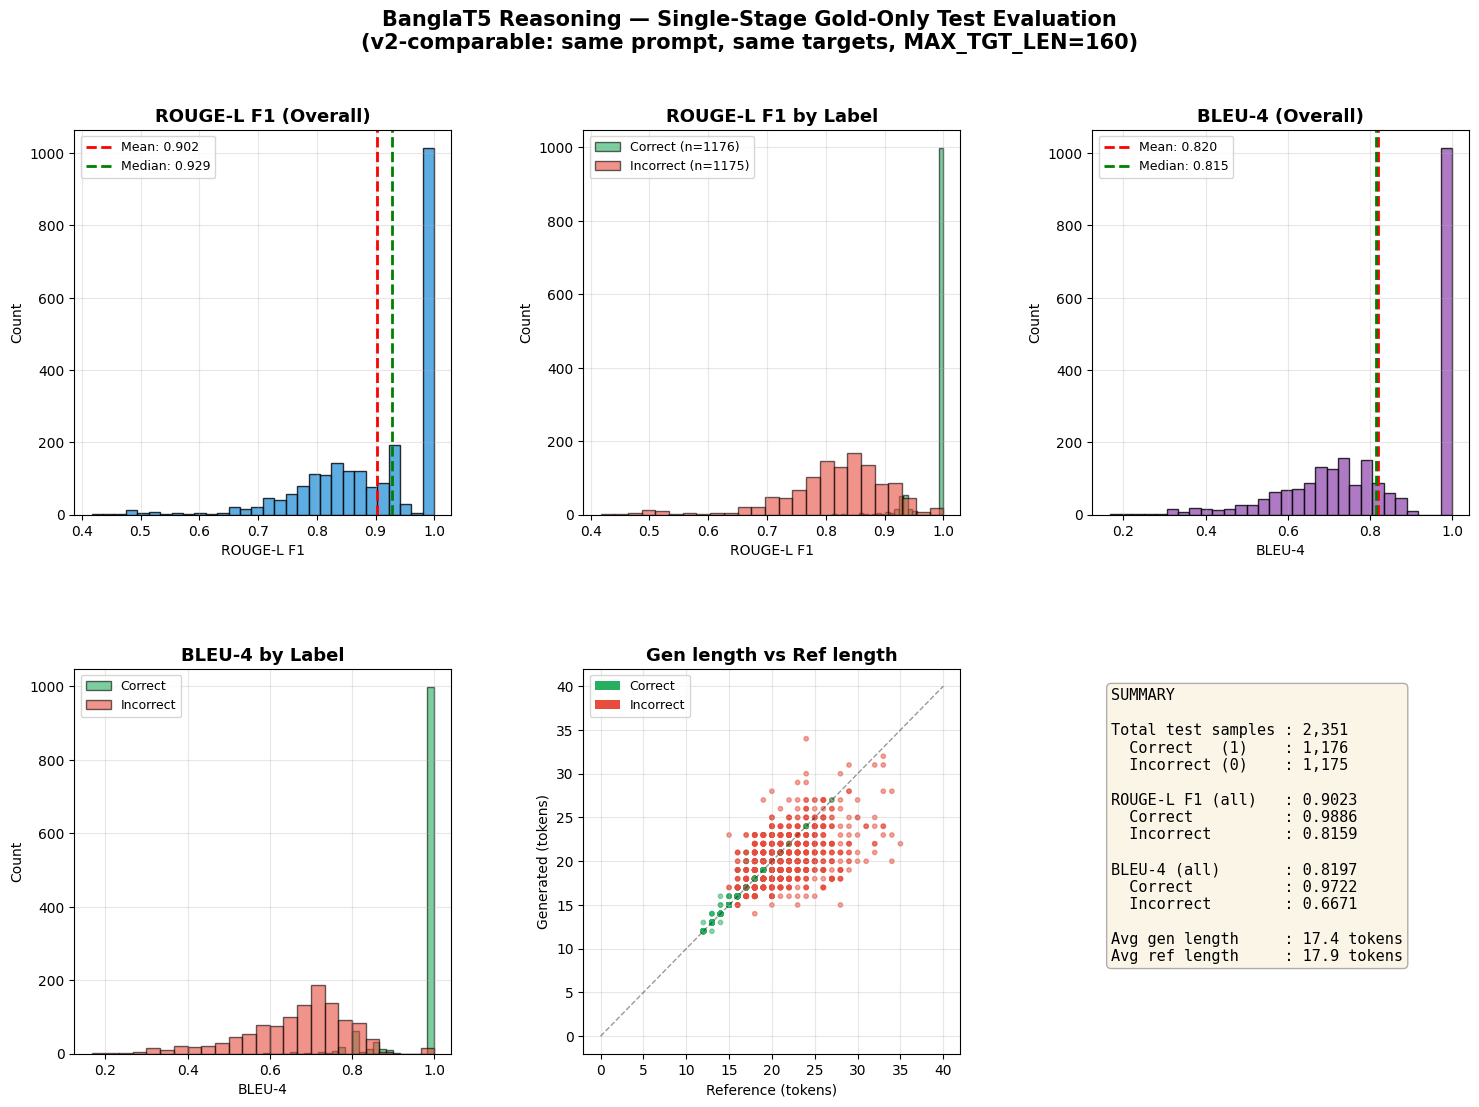


✅ Saved plot   : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_eval_plots_single_v2.png
✅ Saved metrics: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_eval_metrics_single_v2.json
✅ Saved CSV    : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_generations_single_v2.csv


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

OUT_TEST_CSV     = os.path.join(OUT_SINGLE, "test_generations_single_v2.csv")
OUT_TEST_METRICS = os.path.join(OUT_SINGLE, "test_eval_metrics_single_v2.json")
OUT_TEST_PNG     = os.path.join(OUT_SINGLE, "test_eval_plots_single_v2.png")

t_rows      = read_jsonl(TEST_JSONL)
test_inputs = [r["input_text"]  for r in t_rows]
test_refs   = [r["target_text"] for r in t_rows]
test_labels = [int(r.get("s_label", -1)) for r in t_rows]

eval_tokenizer = AutoTokenizer.from_pretrained(os.path.join(OUT_SINGLE, "tokenizer"))
eval_model     = AutoModelForSeq2SeqLM.from_pretrained(os.path.join(OUT_SINGLE, "model"))

print("⏳ Generating on test set…")
test_hyps = generate_batch(eval_model, eval_tokenizer, test_inputs, batch_size=16)
print(f"✅ Generated {len(test_hyps)} outputs")

rouges   = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
bleus    = [bleu4(ref, hyp)      for ref, hyp in zip(test_refs, test_hyps)]
gen_lens = [len(_tok(h)) for h in test_hyps]
ref_lens = [len(_tok(r)) for r in test_refs]

df_out = pd.DataFrame({
    "id":             [r.get("id", f"test_{i}") for i, r in enumerate(t_rows)],
    "s_label":        test_labels,
    "input_text":     test_inputs,
    "target_text":    test_refs,
    "generated_text": test_hyps,
    "rougeL_f1":      rouges,
    "bleu4":          bleus,
    "gen_len_tokens": gen_lens,
    "ref_len_tokens": ref_lens,
})
df_out.to_csv(OUT_TEST_CSV, index=False, encoding="utf-8-sig")

correct_mask   = df_out["s_label"] == 1
incorrect_mask = df_out["s_label"] == 0

metrics_payload = {
    "model":       "single_stage_gold_v2",
    "num_samples": int(len(df_out)),
    "overall": {
        "rougeL_f1":      agg(rouges),
        "bleu4":          agg(bleus),
        "gen_len_tokens": agg(gen_lens),
        "ref_len_tokens": agg(ref_lens),
    },
    "correct_usage": {
        "n":         int(correct_mask.sum()),
        "rougeL_f1": agg(df_out.loc[correct_mask, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_out.loc[correct_mask, "bleu4"].tolist()),
    },
    "incorrect_usage": {
        "n":         int(incorrect_mask.sum()),
        "rougeL_f1": agg(df_out.loc[incorrect_mask, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_out.loc[incorrect_mask, "bleu4"].tolist()),
    },
}
with open(OUT_TEST_METRICS, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print("\n" + "="*60)
print("SINGLE-STAGE METRICS SUMMARY")
print("="*60)
for scope in ["overall", "correct_usage", "incorrect_usage"]:
    d = metrics_payload[scope]
    n = d.get("n", metrics_payload["num_samples"])
    print(f"\n  [{scope.upper()}]  n={n}")
    for metric in ["rougeL_f1", "bleu4"]:
        if metric in d:
            print(f"    {metric:15s}  mean={d[metric]['mean']:.4f}  "
                  f"median={d[metric]['median']:.4f}")

r_correct   = df_out.loc[correct_mask,   "rougeL_f1"].tolist()
r_incorrect = df_out.loc[incorrect_mask, "rougeL_f1"].tolist()
b_correct   = df_out.loc[correct_mask,   "bleu4"].tolist()
b_incorrect = df_out.loc[incorrect_mask, "bleu4"].tolist()

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(rouges, bins=30, color="#3498db", edgecolor="black", alpha=0.8)
ax1.axvline(np.mean(rouges),   color="red",   linestyle="--", lw=2, label=f"Mean: {np.mean(rouges):.3f}")
ax1.axvline(np.median(rouges), color="green", linestyle="--", lw=2, label=f"Median: {np.median(rouges):.3f}")
ax1.set_title("ROUGE-L F1 (Overall)", fontsize=13, fontweight="bold")
ax1.set_xlabel("ROUGE-L F1"); ax1.set_ylabel("Count")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(r_correct,   bins=25, alpha=0.6, color="#27ae60", label=f"Correct (n={len(r_correct)})",   edgecolor="black")
ax2.hist(r_incorrect, bins=25, alpha=0.6, color="#e74c3c", label=f"Incorrect (n={len(r_incorrect)})", edgecolor="black")
ax2.set_title("ROUGE-L F1 by Label", fontsize=13, fontweight="bold")
ax2.set_xlabel("ROUGE-L F1"); ax2.set_ylabel("Count")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(bleus, bins=30, color="#9b59b6", edgecolor="black", alpha=0.8)
ax3.axvline(np.mean(bleus),   color="red",   linestyle="--", lw=2, label=f"Mean: {np.mean(bleus):.3f}")
ax3.axvline(np.median(bleus), color="green", linestyle="--", lw=2, label=f"Median: {np.median(bleus):.3f}")
ax3.set_title("BLEU-4 (Overall)", fontsize=13, fontweight="bold")
ax3.set_xlabel("BLEU-4"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(b_correct,   bins=25, alpha=0.6, color="#27ae60", label="Correct",   edgecolor="black")
ax4.hist(b_incorrect, bins=25, alpha=0.6, color="#e74c3c", label="Incorrect", edgecolor="black")
ax4.set_title("BLEU-4 by Label", fontsize=13, fontweight="bold")
ax4.set_xlabel("BLEU-4"); ax4.set_ylabel("Count")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
scatter_colors = ["#27ae60" if l == 1 else "#e74c3c" for l in test_labels]
ax5.scatter(ref_lens, gen_lens, c=scatter_colors, s=10, alpha=0.5)
max_len = max(max(ref_lens), max(gen_lens)) + 5
ax5.plot([0, max_len], [0, max_len], "k--", lw=1, alpha=0.4)
ax5.set_title("Gen length vs Ref length", fontsize=13, fontweight="bold")
ax5.set_xlabel("Reference (tokens)"); ax5.set_ylabel("Generated (tokens)")
ax5.legend(handles=[Patch(facecolor="#27ae60", label="Correct"),
                    Patch(facecolor="#e74c3c", label="Incorrect")], fontsize=9)
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary_txt = (
    "SUMMARY\n\n"
    f"Total test samples : {len(df_out):,}\n"
    f"  Correct   (1)    : {int(correct_mask.sum()):,}\n"
    f"  Incorrect (0)    : {int(incorrect_mask.sum()):,}\n\n"
    f"ROUGE-L F1 (all)   : {np.mean(rouges):.4f}\n"
    f"  Correct          : {np.mean(r_correct):.4f}\n"
    f"  Incorrect        : {np.mean(r_incorrect):.4f}\n\n"
    f"BLEU-4 (all)       : {np.mean(bleus):.4f}\n"
    f"  Correct          : {np.mean(b_correct):.4f}\n"
    f"  Incorrect        : {np.mean(b_incorrect):.4f}\n\n"
    f"Avg gen length     : {np.mean(gen_lens):.1f} tokens\n"
    f"Avg ref length     : {np.mean(ref_lens):.1f} tokens"
)
ax6.text(0.05, 0.95, summary_txt, transform=ax6.transAxes,
         fontsize=11, verticalalignment="top", family="monospace",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))

fig.suptitle("BanglaT5 Reasoning — Single-Stage Gold-Only Test Evaluation\n"
             "(v2-comparable: same prompt, same targets, MAX_TGT_LEN=160)",
             fontsize=15, fontweight="bold")
plt.savefig(OUT_TEST_PNG, dpi=300, bbox_inches="tight")
plt.show()
print("\n✅ Saved plot   :", OUT_TEST_PNG)
print("✅ Saved metrics:", OUT_TEST_METRICS)
print("✅ Saved CSV    :", OUT_TEST_CSV)

In [ ]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report

BB_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                                "three", "BanglaBERT", "model")
BB_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                                "three", "BanglaBERT", "tokenizer")
RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_CC         = os.path.join(OUT_BASE, "condition_c_single_v2")
OUT_CC_CSV     = os.path.join(OUT_CC,  "test_generations_single_v2.csv")
OUT_CC_METRICS = os.path.join(OUT_CC,  "test_eval_metrics_single_v2.json")
OUT_CC_PNG     = os.path.join(OUT_CC,  "test_eval_plots_single_v2.png")
os.makedirs(OUT_CC, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading BanglaBERT classifier…")
bb_tokenizer = AutoTokenizer.from_pretrained(BB_TOKENIZER_DIR)
bb_model     = AutoModelForSequenceClassification.from_pretrained(BB_MODEL_DIR).to(device)
bb_model.eval()

print("⏳ Loading Single-Stage T5 generator…")
t5_tokenizer = AutoTokenizer.from_pretrained(os.path.join(OUT_SINGLE, "tokenizer"))
t5_model     = AutoModelForSeq2SeqLM.from_pretrained(os.path.join(OUT_SINGLE, "model")).to(device)
t5_model.eval()

s_te = np.load(os.path.join(RAW_DIR, "test", "sentence.npy"),      allow_pickle=True).astype(str)
w_te = np.load(os.path.join(RAW_DIR, "test", "idiom_word.npy"),    allow_pickle=True).astype(str)
m_te = np.load(os.path.join(RAW_DIR, "test", "idiom_meaning.npy"), allow_pickle=True).astype(str)
y_te = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

gold_test_rows = read_jsonl(TEST_JSONL)
test_refs_cc   = [r["target_text"] for r in gold_test_rows]

def bb_predict_batch(sentences, idiom_words, idiom_meanings, batch_size=32):
    all_preds, all_probs = [], []
    texts = [f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {s}"
             for s, iw, im in zip(sentences, idiom_words, idiom_meanings)]
    for i in range(0, len(texts), batch_size):
        enc = bb_tokenizer(texts[i:i+batch_size], max_length=192,
                           truncation=True, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = bb_model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())
    return np.array(all_preds), np.array(all_probs)

print("\n⏳ Step 1: BanglaBERT classifying…")
bb_preds, bb_probs = bb_predict_batch(s_te, w_te, m_te)
bb_acc = accuracy_score(y_te, bb_preds)
bb_f1  = f1_score(y_te, bb_preds, zero_division=0)
print(f"✅ BanglaBERT  Accuracy: {bb_acc:.4f}  F1: {bb_f1:.4f}")
print(classification_report(y_te, bb_preds, zero_division=0))

cc_inputs = [make_input_v2(s, w, m, pred)
             for s, w, m, pred in zip(s_te, w_te, m_te, bb_preds)]

print("\n⏳ Step 2: Single-Stage T5 generating reasons…")
cc_hyps = generate_batch(t5_model, t5_tokenizer, cc_inputs, batch_size=16)
print("✅ Generation complete.")

cc_rouges   = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs_cc, cc_hyps)]
cc_bleus    = [bleu4(ref, hyp)      for ref, hyp in zip(test_refs_cc, cc_hyps)]
cc_gen_lens = [len(_tok(h)) for h in cc_hyps]
cc_ref_lens = [len(_tok(r)) for r in test_refs_cc]

df_cc = pd.DataFrame({
    "id":              [r.get("id", f"test_{i}") for i, r in enumerate(gold_test_rows)],
    "s_label":         y_te,
    "banglabert_pred": bb_preds,
    "banglabert_prob": bb_probs,
    "input_text":      cc_inputs,
    "target_text":     test_refs_cc,
    "generated_text":  cc_hyps,
    "rougeL_f1":       cc_rouges,
    "bleu4":           cc_bleus,
    "gen_len_tokens":  cc_gen_lens,
    "ref_len_tokens":  cc_ref_lens,
})
df_cc.to_csv(OUT_CC_CSV, index=False, encoding="utf-8-sig")

correct_cc   = df_cc["s_label"] == 1
incorrect_cc = df_cc["s_label"] == 0

cc_metrics = {
    "num_samples": int(len(df_cc)),
    "banglabert":  {"accuracy": float(bb_acc), "f1": float(bb_f1)},
    "overall":     {"rougeL_f1": agg(cc_rouges), "bleu4": agg(cc_bleus), "gen_len": agg(cc_gen_lens)},
    "correct_usage":   {"n": int(correct_cc.sum()),
                        "rougeL_f1": agg(df_cc.loc[correct_cc,   "rougeL_f1"].tolist()),
                        "bleu4":     agg(df_cc.loc[correct_cc,   "bleu4"].tolist())},
    "incorrect_usage": {"n": int(incorrect_cc.sum()),
                        "rougeL_f1": agg(df_cc.loc[incorrect_cc, "rougeL_f1"].tolist()),
                        "bleu4":     agg(df_cc.loc[incorrect_cc, "bleu4"].tolist())},
}
with open(OUT_CC_METRICS, "w", encoding="utf-8") as f:
    json.dump(cc_metrics, f, indent=2, ensure_ascii=False)

print("\n✅ Condition-C Single-Stage metrics:")
for scope in ["overall", "correct_usage", "incorrect_usage"]:
    d = cc_metrics[scope]
    n = d.get("n", cc_metrics["num_samples"])
    print(f"  [{scope}] n={n}  "
          f"ROUGE-L={d['rougeL_f1']['mean']:.4f}  "
          f"BLEU-4={d['bleu4']['mean']:.4f}")
print("\n✅ Saved:", OUT_CC_METRICS)

⏳ Loading BanglaBERT classifier…


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

⏳ Loading Single-Stage T5 generator…


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



⏳ Step 1: BanglaBERT classifying…
✅ BanglaBERT  Accuracy: 0.9413  F1: 0.9420
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1175
           1       0.93      0.95      0.94      1176

    accuracy                           0.94      2351
   macro avg       0.94      0.94      0.94      2351
weighted avg       0.94      0.94      0.94      2351


⏳ Step 2: Single-Stage T5 generating reasons…
✅ Generation complete.

✅ Condition-C Single-Stage metrics:
  [overall] n=2351  ROUGE-L=0.8783  BLEU-4=0.7930
  [correct_usage] n=1176  ROUGE-L=0.9652  BLEU-4=0.9435
  [incorrect_usage] n=1175  ROUGE-L=0.7913  BLEU-4=0.6423

✅ Saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/condition_c_single_v2/test_eval_metrics_single_v2.json


In [ ]:
from bert_score import score as bert_score_fn
from sentence_transformers import SentenceTransformer, util as st_util

OUT_EVAL = os.path.join(OUT_SINGLE, "enhanced_eval")
os.makedirs(OUT_EVAL, exist_ok=True)

CORRECT_KEYWORDS = [
    "সঠিক", "সঠিকভাবে", "যথাযথ", "যথার্থ",
    "সামঞ্জস্যপূর্ণ", "উপযুক্ত", "প্রযোজ্য",
    "ব্যবহৃত হয়েছে", "মিল রয়েছে", "অর্থবোধক"
]
INCORRECT_KEYWORDS = [
    "ভুল", "ভুলভাবে", "অসামঞ্জস্য", "অপ্রযোজ্য",
    "সামঞ্জস্যপূর্ণ নয়", "মেলে না", "প্রসঙ্গ",
    "অর্থে ব্যবহৃত হয়নি", "প্রকৃত অর্থ নয়"
]

def compute_bertscore(refs, hyps, batch_size=32):
    print("\n⏳ Computing BERTScore…")
    P, R, F1 = bert_score_fn(hyps, refs,
                              model_type="bert-base-multilingual-cased",
                              lang="bn", batch_size=batch_size, verbose=True)
    print("✅ BERTScore done")
    return F1.numpy()

def compute_labse_similarity(refs, hyps, batch_size=64):
    print("\n⏳ Computing LaBSE Similarity…")
    lm = SentenceTransformer("sentence-transformers/LaBSE")
    ref_emb = lm.encode(refs, batch_size=batch_size, show_progress_bar=True, convert_to_tensor=True)
    hyp_emb = lm.encode(hyps, batch_size=batch_size, show_progress_bar=True, convert_to_tensor=True)
    scores = torch.diag(st_util.cos_sim(ref_emb, hyp_emb)).cpu().numpy()
    print("✅ LaBSE done")
    return scores

def label_reason_consistency(generated_texts, labels):
    print("\n⏳ Computing Consistency Check…")
    scores = []
    for text, label in zip(generated_texts, labels):
        text = str(text).strip()
        has_correct   = any(kw in text for kw in CORRECT_KEYWORDS)
        has_incorrect = any(kw in text for kw in INCORRECT_KEYWORDS)
        consistent = (has_correct and not has_incorrect) if label == 1 else has_incorrect
        scores.append(1.0 if consistent else 0.0)
    scores = np.array(scores); labels = np.array(labels)
    print("✅ Consistency done")
    return {
        "per_sample":          scores,
        "consistency_rate":    float(np.mean(scores)),
        "label_1_consistency": float(np.mean(scores[labels == 1])),
        "label_0_consistency": float(np.mean(scores[labels == 0])),
    }

def lexical_quality_metrics(generated_texts, ref_texts):
    print("\n⏳ Computing Lexical Quality…")
    ttrs, rep_rates, length_ratios, too_short = [], [], [], []
    for gen, ref in zip(generated_texts, ref_texts):
        tokens     = str(gen).strip().split()
        ref_tokens = str(ref).strip().split()
        ttrs.append(len(set(tokens)) / max(len(tokens), 1))
        trigrams = [tuple(tokens[i:i+3]) for i in range(len(tokens) - 2)]
        rep_rates.append((len(trigrams) - len(set(trigrams))) / max(len(trigrams), 1))
        length_ratios.append(len(tokens) / max(len(ref_tokens), 1))
        too_short.append(1.0 if len(tokens) < 5 else 0.0)
    print("✅ Lexical Quality done")
    return {
        "type_token_ratio_mean":   float(np.mean(ttrs)),
        "rep_3gram_rate_mean":     float(np.mean(rep_rates)),
        "length_ratio_mean":       float(np.mean(length_ratios)),
        "too_short_rate":          float(np.mean(too_short)),
        "per_sample_ttr":          np.array(ttrs),
        "per_sample_length_ratio": np.array(length_ratios),
    }

df_eval  = pd.read_csv(OUT_TEST_CSV, encoding="utf-8-sig")
refs_e   = df_eval["target_text"].astype(str).tolist()
hyps_e   = df_eval["generated_text"].astype(str).tolist()
labels_e = df_eval["s_label"].astype(int).tolist()

print(f"\nLoaded {len(df_eval)} test samples")
print(f"  Correct (1): {sum(1 for l in labels_e if l==1)}  "
      f"Incorrect (0): {sum(1 for l in labels_e if l==0)}")

bert_f1     = compute_bertscore(refs_e, hyps_e)
labse_sim   = compute_labse_similarity(refs_e, hyps_e)
consistency = label_reason_consistency(hyps_e, labels_e)
lexical     = lexical_quality_metrics(hyps_e, refs_e)

df_eval["bertscore_f1"]     = bert_f1
df_eval["labse_similarity"] = labse_sim
df_eval["consistent"]       = consistency["per_sample"]
df_eval["type_token_ratio"] = lexical["per_sample_ttr"]
df_eval["length_ratio"]     = lexical["per_sample_length_ratio"]
df_eval.to_csv(os.path.join(OUT_EVAL, "enhanced_eval_results_single_v2.csv"),
               index=False, encoding="utf-8-sig")

correct_mask_e   = df_eval["s_label"] == 1
incorrect_mask_e = df_eval["s_label"] == 0

def split_stats(col):
    return {
        "overall":         {"mean": float(df_eval[col].mean()), "std": float(df_eval[col].std())},
        "correct_usage":   {"mean": float(df_eval.loc[correct_mask_e,   col].mean()),
                            "std":  float(df_eval.loc[correct_mask_e,   col].std())},
        "incorrect_usage": {"mean": float(df_eval.loc[incorrect_mask_e, col].mean()),
                            "std":  float(df_eval.loc[incorrect_mask_e, col].std())},
    }

report = {
    "model":            "single_stage_gold_v2",
    "num_samples":      int(len(df_eval)),
    "bertscore_f1":     split_stats("bertscore_f1"),
    "labse_similarity": split_stats("labse_similarity"),
    "consistency": {
        "overall_rate":  consistency["consistency_rate"],
        "label_1_rate":  consistency["label_1_consistency"],
        "label_0_rate":  consistency["label_0_consistency"],
    },
    "lexical": {
        "type_token_ratio_mean": lexical["type_token_ratio_mean"],
        "rep_3gram_rate_mean":   lexical["rep_3gram_rate_mean"],
        "length_ratio_mean":     lexical["length_ratio_mean"],
        "too_short_rate":        lexical["too_short_rate"],
    },
}
with open(os.path.join(OUT_EVAL, "enhanced_eval_metrics_single_v2.json"),
          "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("\n" + "="*65)
print("ENHANCED EVALUATION RESULTS — SINGLE-STAGE")
print("="*65)
print(f"\n{'Metric':<28} {'Overall':>9} {'Correct':>9} {'Incorrect':>10}")
print("-"*60)
for label_str, col in [("BERTScore F1", "bertscore_f1"), ("LaBSE Similarity", "labse_similarity")]:
    ov = df_eval[col].mean()
    co = df_eval.loc[correct_mask_e,   col].mean()
    ic = df_eval.loc[incorrect_mask_e, col].mean()
    print(f"{label_str:<28} {ov:>9.4f} {co:>9.4f} {ic:>10.4f}")
print(f"\n{'Consistency Rate':<28} "
      f"{consistency['consistency_rate']:>9.4f} "
      f"{consistency['label_1_consistency']:>9.4f} "
      f"{consistency['label_0_consistency']:>10.4f}")
print(f"\nLexical Diversity (TTR)   : {lexical['type_token_ratio_mean']:.4f}")
print(f"Repetition Rate (3-gram)  : {lexical['rep_3gram_rate_mean']:.4f}")
print(f"Length Ratio (gen/ref)    : {lexical['length_ratio_mean']:.4f}")
print(f"Too-Short Rate (<5 tokens): {lexical['too_short_rate']:.4f}")
print(f"\n✅ Enhanced eval saved → {OUT_EVAL}")


Loaded 2351 test samples
  Correct (1): 1176  Incorrect (0): 1175

⏳ Computing BERTScore…


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

✅ LaBSE done

⏳ Computing Consistency Check…
✅ Consistency done

⏳ Computing Lexical Quality…
✅ Lexical Quality done

ENHANCED EVALUATION RESULTS — SINGLE-STAGE

Metric                         Overall   Correct  Incorrect
------------------------------------------------------------
BERTScore F1                    0.9663    0.9970     0.9357
LaBSE Similarity                0.9599    0.9966     0.9231

Consistency Rate                0.9957    0.9915     1.0000

Lexical Diversity (TTR)   : 0.9901
Repetition Rate (3-gram)  : 0.0000
Length Ratio (gen/ref)    : 0.9820
Too-Short Rate (<5 tokens): 0.0000

✅ Enhanced eval saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/enhanced_eval


In [ ]:
OUT_HE   = os.path.join(OUT_BASE, "human_eval")
SEED_HE  = 42
SAMPLE_N = 200
N_RATERS = 2
os.makedirs(OUT_HE, exist_ok=True)

random.seed(SEED_HE); np.random.seed(SEED_HE)

df_gen       = pd.read_csv(OUT_TEST_CSV, encoding="utf-8-sig")
correct_df   = df_gen[df_gen["s_label"] == 1]
incorrect_df = df_gen[df_gen["s_label"] == 0]
n_each       = SAMPLE_N // 2

sample_correct   = correct_df.sample(n=min(n_each, len(correct_df)),   random_state=SEED_HE)
sample_incorrect = incorrect_df.sample(n=min(n_each, len(incorrect_df)), random_state=SEED_HE)

df_sample = (pd.concat([sample_correct, sample_incorrect])
               .sample(frac=1, random_state=SEED_HE)
               .reset_index(drop=True))
df_sample.insert(0, "eval_id", range(1, len(df_sample) + 1))
print(f"Sampled {len(df_sample)} instances  "
      f"({(df_sample.s_label==1).sum()} correct, {(df_sample.s_label==0).sum()} incorrect)")

CRITERION_HEADERS = {
    "fluency":      "Fluency (1–5)\n1=Ungrammatical/unclear  5=Natural Bangla",
    "correctness":  "Correctness (1–5)\n1=Wrong explanation  5=Correctly explains usage",
    "usefulness":   "Usefulness (1–5)\n1=Not helpful  5=Helpful for learners",
}

def extract_field(input_text, field_prefix):
    for line in str(input_text).split("\n"):
        if line.startswith(field_prefix):
            return line[len(field_prefix):].strip()
    return ""

df_sample["_idiom"]    = df_sample["input_text"].apply(lambda t: extract_field(t, "বাগধারা: "))
df_sample["_sentence"] = df_sample["input_text"].apply(lambda t: extract_field(t, "বাক্য: "))

rating_cols = {
    "eval_id":               df_sample["eval_id"],
    "idiom":                 df_sample["_idiom"],
    "sentence":              df_sample["_sentence"],
    "generated_explanation": df_sample["generated_text"],
    CRITERION_HEADERS["fluency"]:     "",
    CRITERION_HEADERS["correctness"]: "",
    CRITERION_HEADERS["usefulness"]:  "",
    "comments (optional)":            "",
}
df_rating = pd.DataFrame(rating_cols)

for k in range(1, N_RATERS + 1):
    path = os.path.join(OUT_HE, f"rater{k}_rating_sheet.xlsx")
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        df_rating.to_excel(writer, sheet_name="Rate Here", index=False)
        instructions = pd.DataFrame({"INSTRUCTIONS": [
            "Rate each generated explanation on three criteria.",
            "",
            "NOTE: These are from the SINGLE-STAGE model.",
            "Use the same 1–5 scale as the two-stage sheets for direct comparison.",
            "",
            "FLUENCY (1–5): 1=Ungrammatical  5=Natural Bangla",
            "CORRECTNESS (1–5): 1=Wrong explanation  5=Fully correct",
            "USEFULNESS (1–5): 1=Not helpful  5=Helpful for learners",
            "",
            "Save completed file as raterN_completed_single.xlsx",
        ]})
        instructions.to_excel(writer, sheet_name="Instructions", index=False)
    print(f"✅ Rating sheet saved: {path}")

print(f"\n→ Distribute rater1/2 sheets, collect back as raterN_completed_single.xlsx")
print(f"→ Then run Section 5B cell below")

Sampled 200 instances  (100 correct, 100 incorrect)
✅ Rating sheet saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/human_eval/rater1_rating_sheet_single.xlsx
✅ Rating sheet saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/human_eval/rater2_rating_sheet_single.xlsx

→ Distribute rater1/2 sheets, collect back as raterN_completed_single.xlsx
→ Then run Section 5B cell below


In [ ]:
def krippendorff_alpha(ratings_matrix):
    m = np.array(ratings_matrix, dtype=float)
    n_raters, n_items = m.shape
    pairable = []
    for item in range(n_items):
        vals = m[:, item]
        valid = vals[~np.isnan(vals)]
        if len(valid) >= 2:
            pairable.append(valid)
    if not pairable:
        return float("nan")
    o_num = o_den = 0.0
    for vals in pairable:
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                o_num += (vals[i] - vals[j]) ** 2; o_den += 1
    Do = o_num / o_den if o_den > 0 else 0.0
    all_vals = np.concatenate(pairable)
    n_total  = len(all_vals)
    e_num = sum((all_vals[i] - all_vals[j]) ** 2
                for i in range(n_total) for j in range(i + 1, n_total))
    De = e_num / (n_total * (n_total - 1) / 2) if n_total > 1 else 0.0
    return 1.0 - Do / De if De != 0 else 1.0

def load_completed_ratings_single(out_he_dir, n_raters=2):
    all_dfs = []
    for k in range(1, n_raters + 1):
        fpath = os.path.join(out_he_dir, f"rater{k}_completed.xlsx")
        if not os.path.exists(fpath):
            print(f"⚠️  Missing: {fpath}")
            all_dfs.append(None)
        else:
            all_dfs.append(pd.read_excel(fpath, sheet_name="Rate Here"))
    if all(d is None for d in all_dfs):
        return None
    n_items  = max(len(d) for d in all_dfs if d is not None)
    matrices = {}
    for cname, cheader in CRITERION_HEADERS.items():
        mat = np.full((n_raters, n_items), np.nan)
        for k, df_r in enumerate(all_dfs):
            if df_r is None: continue
            col = next((c for c in df_r.columns if c.startswith(cheader.split("\n")[0])), None)
            if col is None:
                print(f"⚠️  Column for '{cname}' not found in rater{k+1}.")
                continue
            scores = pd.to_numeric(df_r[col], errors="coerce").values
            mat[k, :len(scores)] = scores
        matrices[cname] = mat
    return matrices

def report_human_eval_single(matrices, out_he_dir, df_sample_local):
    results = {}
    correct_mask_l   = df_sample_local["s_label"].values == 1
    incorrect_mask_l = df_sample_local["s_label"].values == 0
    for cname, mat in matrices.items():
        item_means = np.nanmean(mat, axis=0)
        alpha      = krippendorff_alpha(mat)
        results[cname] = {
            "overall":         {"mean": float(np.nanmean(item_means)),
                                "sd":   float(np.nanstd(item_means))},
            "correct_usage":   {"mean": float(np.nanmean(item_means[correct_mask_l])),
                                "sd":   float(np.nanstd(item_means[correct_mask_l]))},
            "incorrect_usage": {"mean": float(np.nanmean(item_means[incorrect_mask_l])),
                                "sd":   float(np.nanstd(item_means[incorrect_mask_l]))},
            "krippendorff_alpha": float(alpha),
        }
    print("\n" + "="*65)
    print("HUMAN EVALUATION RESULTS — SINGLE-STAGE")
    print("="*65)
    print(f"{'Criterion':<18} {'Mean':>6} {'±SD':>6}  {'α':>6}  "
          f"{'Correct Mean':>13}  {'Incorrect Mean':>15}")
    print("-"*65)
    for cname, d in results.items():
        print(f"{cname:<18} {d['overall']['mean']:>6.3f} ±{d['overall']['sd']:>5.3f}  "
              f"{d['krippendorff_alpha']:>6.3f}  "
              f"{d['correct_usage']['mean']:>13.3f}  "
              f"{d['incorrect_usage']['mean']:>15.3f}")
    report_path = os.path.join(out_he_dir, "human_eval_report_single.json")
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"\n✅ Human eval JSON saved: {report_path}")
    return results

# Toggle this
mode = "report"    # ← change to "report" after raters return files

if mode == "report":
    matrices = load_completed_ratings_single(OUT_HE, N_RATERS)
    if matrices is None:
        print("\n⚠️  No completed files found. Place raterN_completed_single.xlsx in:", OUT_HE)
    else:
        report_human_eval_single(matrices, OUT_HE, df_sample)
else:
    print("mode='prepare' — skipping report generation.")
    print(f"Place completed files in: {OUT_HE}")
    print("Then re-run with mode='report'")


HUMAN EVALUATION RESULTS — SINGLE-STAGE
Criterion            Mean    ±SD       α   Correct Mean   Incorrect Mean
-----------------------------------------------------------------
fluency             4.865 ±0.432  -0.044          4.850            4.880
correctness         4.415 ±0.808  -0.029          4.570            4.260
usefulness          4.380 ±0.834   0.029          4.530            4.230

✅ Human eval JSON saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/human_eval/human_eval_report_single.json


In [ ]:
print("\n✅ ALL SINGLE-STAGE V2-COMPARABLE PIPELINE COMPLETE")
print("\nOutput root:", OUT_BASE)
print(f"  Single-stage model : {OUT_SINGLE}")
print(f"  Test generations   : {OUT_TEST_CSV}")
print(f"  Test metrics JSON  : {OUT_TEST_METRICS}")
print(f"  Test plot          : {OUT_TEST_PNG}")
print(f"  Condition-C        : {OUT_CC}")
print(f"  Enhanced eval      : {OUT_EVAL}")
print(f"  Human eval sheets  : {OUT_HE}")


✅ ALL SINGLE-STAGE V2-COMPARABLE PIPELINE COMPLETE

Output root: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2
  Single-stage model : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold
  Test generations   : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_generations_single_v2.csv
  Test metrics JSON  : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_eval_metrics_single_v2.json
  Test plot          : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/test_eval_plots_single_v2.png
  Condition-C        : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/condition_c_single_v2
  Enhanced eval      : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_single_v2/single_stage_gold/enhanced_eval
  Human eval sheets  : /content/drive

### ✨ 2 STAGE REASONING PIPELINE V2 - IMPROVED✨

#### Section 1 — BUILD IMPROVED T5 DATA (Gold + Pseudo)


In [ ]:
import os, json
import numpy as np
import pandas as pd

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

DATA_PATH  = os.path.join(PROJECT_ROOT, "01_clean", "normalized.jsonl")
SPLIT_DIR  = os.path.join(PROJECT_ROOT, "02_splits")
TEACHER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                           "three", "BanglaBERT")

OUT_BASE  = os.path.join(PROJECT_ROOT, "07_t5_data_reason_v2")
OUT_GOLD  = os.path.join(OUT_BASE, "gold")
OUT_PSEU  = os.path.join(OUT_BASE, "banglabert_pred")
os.makedirs(OUT_GOLD, exist_ok=True)
os.makedirs(OUT_PSEU, exist_ok=True)

def make_input_v2(sentence: str, idiom_word: str, idiom_meaning: str,
                  label_value: int) -> str:
    """
    Enriched prompt that explicitly tells the model:
      - the idiom name
      - its correct meaning
      - the sentence under evaluation
      - the predicted / gold label
      - a Bangla cue phrase that primes correct-vs-incorrect reasoning
    """
    label_cue = "সঠিক" if int(label_value) == 1 else "ভুল"
    return (
        f"বাগধারা: {idiom_word}\n"
        f"বাগধারার অর্থ: {idiom_meaning}\n"
        f"বাক্য: {sentence}\n"
        f"ব্যবহার: {label_cue}\n"
        f"কারণ ব্যাখ্যা করুন:"
    )

def build_target_v2(row: dict) -> str:
    """
    For s_label=1 (correct): keep the existing short confirmation template.
    For s_label=0 (incorrect): generate a richer reason that explicitly
      states (a) the idiom's correct meaning, and
             (b) what the sentence actually expresses (wrong usage).
    The 'reason' field in the dataset already carries this info — we
    normalise and strengthen it here.
    """
    idiom  = str(row.get("idiom_word",    "")).strip()
    meaning = str(row.get("idiom_meaning", "")).strip()
    reason  = str(row.get("reason",        "")).strip()
    label   = int(row.get("s_label", 0))

    if label == 1:
        return (
            f"উক্ত '{idiom}' বাগধারাটির অর্থ হলো '{meaning}' "
            f"এবং বাক্যে এটি সঠিকভাবে ব্যবহৃত হয়েছে।"
        )
    else:
        if reason and "ভুল" in reason and len(reason) > 30:
            return reason
        else:
               return (
                f"উক্ত '{idiom}' বাগধারাটির অর্থ হলো '{meaning}', "
                f"কিন্তু বাক্যে এটি সেই অর্থে ব্যবহৃত হয়নি। "
                f"বাগধারাটির প্রকৃত অর্থ বাক্যের প্রসঙ্গের সাথে সামঞ্জস্যপূর্ণ নয়, "
                f"তাই এটি ভুল ব্যবহার।"
            )

rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

train_idx = np.load(os.path.join(SPLIT_DIR, "train_idx.npy"))
val_idx   = np.load(os.path.join(SPLIT_DIR, "val_idx.npy"))
test_idx  = np.load(os.path.join(SPLIT_DIR, "test_idx.npy"))

def write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

for split, idxs in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    pred_df = pd.read_csv(
        os.path.join(TEACHER_DIR, f"predictions_{split}.csv")
    )

    gold_records   = []
    pseudo_records = []

    for j, dataset_i in enumerate(idxs):
        r = rows[int(dataset_i)]

        gold_label   = int(r["s_label"])
        pseudo_label = int(pred_df.loc[j, "y_pred"])
        pseudo_prob  = float(pred_df.loc[j, "prob_1"])

        target_text  = build_target_v2(r)

        gold_records.append({
            "id":           f"{split}_{j}",
            "input_text":   make_input_v2(
                                r["sentence"], r["idiom_word"],
                                r["idiom_meaning"], gold_label),
            "target_text":  target_text,
            "s_label":      gold_label,
            "label_source": "gold",
        })

        pseudo_records.append({
            "id":              f"{split}_{j}",
            "input_text":      make_input_v2(
                                   r["sentence"], r["idiom_word"],
                                   r["idiom_meaning"], pseudo_label),
            "target_text":     target_text,          # still use gold reason
            "s_label":         pseudo_label,
            "label_source":    "banglabert_pred",
            "teacher_prob_1":  pseudo_prob,
        })

    write_jsonl(os.path.join(OUT_GOLD, f"{split}.jsonl"), gold_records)
    write_jsonl(os.path.join(OUT_PSEU, f"{split}.jsonl"), pseudo_records)

    print(f"\n[{split.upper()}] samples: {len(gold_records)}")
    pos = sum(1 for r in gold_records if r["s_label"] == 1)
    neg = sum(1 for r in gold_records if r["s_label"] == 0)
    print(f"  s_label=1 (correct):   {pos}")
    print(f"  s_label=0 (incorrect): {neg}")
    if gold_records:
        ex1 = next((r for r in gold_records if r["s_label"] == 1), None)
        ex0 = next((r for r in gold_records if r["s_label"] == 0), None)
        if ex1:
            print(f"\n  [CORRECT example]\n  IN:  {ex1['input_text'][:120]}\n  OUT: {ex1['target_text']}")
        if ex0:
            print(f"\n  [INCORRECT example]\n  IN:  {ex0['input_text'][:120]}\n  OUT: {ex0['target_text']}")

print("\n✅ V2 data built")
print("Gold:", OUT_GOLD)
print("Pseudo:", OUT_PSEU)


[TRAIN] samples: 10969
  s_label=1 (correct):   5485
  s_label=0 (incorrect): 5484

  [CORRECT example]
  IN:  বাগধারা: পাথালিকোলা
বাগধারার অর্থ: আড়তোলা
বাক্য: এত দিনের পুরোনো কারবার এবার পাথালিকোলা করার সময় এসেছে
ব্যবহার: সঠিক
ক
  OUT: উক্ত 'পাথালিকোলা' বাগধারাটির অর্থ হলো 'আড়তোলা' এবং বাক্যে এটি সঠিকভাবে ব্যবহৃত হয়েছে।

  [INCORRECT example]
  IN:  বাগধারা: পি পু ফি শু
বাগধারার অর্থ: অত্যন্ত অলস
বাক্য: শিশুটির পিঠে পু নামক কিছু পড়ল এবং সে ফি নামক শব্দ উচ্চারণ করল
ব্
  OUT: উক্ত 'পি পু ফি শু' বাগধারাটির অর্থ হলো 'অত্যন্ত অলস', কিন্তু এটি 'আক্ষরিকভাবে পি, পু, ফি, শু নামক চারটি শব্দ উচ্চারণ' বোঝাতে ব্যবহার করা হয়েছে, যা ভুল

[VAL] samples: 2350
  s_label=1 (correct):   1175
  s_label=0 (incorrect): 1175

  [CORRECT example]
  IN:  বাগধারা: তিলকে তাল করা
বাগধারার অর্থ: বাড়িয়ে বলা
বাক্য: সামান্য ঘটনাকে তিলকে তাল করে পরিবেশন করা তার স্বভাব
ব্যবহার: স
  OUT: উক্ত 'তিলকে তাল করা' বাগধারাটির অর্থ হলো 'বাড়িয়ে বলা' এবং বাক্যে এটি সঠিকভাবে ব্যবহৃত হয়েছে।

  [INCORRECT example]
  IN: 

#### Section 2 — TWO-STAGE BANGLA-T5 TRAINING (V2)

In [ ]:
import os, json, random
import numpy as np
import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME     = "csebuetnlp/banglat5"
MAX_SRC_LEN    = 256
MAX_TGT_LEN    = 160      # slightly longer to allow richer incorrect-usage reasons
EPOCHS_STAGE1  = 2        # pseudo warm-up
EPOCHS_STAGE2  = 3        # gold fine-tune
BATCH          = 8
LR             = 3e-5

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
DATA_BASE    = os.path.join(PROJECT_ROOT, "07_t5_data_reason_v2")
PSEU_DIR     = os.path.join(DATA_BASE, "banglabert_pred")
GOLD_DIR     = os.path.join(DATA_BASE, "gold")

OUT_BASE   = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_v2")
OUT_STAGE1 = os.path.join(OUT_BASE, "stage1_pseudo")
OUT_STAGE2 = os.path.join(OUT_BASE, "stage2_gold")
os.makedirs(OUT_STAGE1, exist_ok=True)
os.makedirs(OUT_STAGE2, exist_ok=True)

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

class T5ReasonDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_src_len, max_tgt_len):
        self.rows        = rows
        self.tok         = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r   = self.rows[idx]
        src = str(r["input_text"])
        tgt = str(r["target_text"])

        model_inputs = self.tok(
            src, max_length=self.max_src_len,
            truncation=True, padding=False
        )
        labels = self.tok(
            text_target=tgt, max_length=self.max_tgt_len,
            truncation=True, padding=False
        )
        model_inputs["labels"] = labels["input_ids"]
        return {k: torch.tensor(v) for k, v in model_inputs.items()}

def train_stage(model, tokenizer, train_rows, val_rows,
                out_dir, epochs, stage_name):

    train_ds = T5ReasonDataset(train_rows, tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)
    val_ds   = T5ReasonDataset(val_rows,   tokenizer, MAX_SRC_LEN, MAX_TGT_LEN)

    args = Seq2SeqTrainingArguments(
        output_dir             = os.path.join(out_dir, "runs"),
        eval_strategy          = "epoch",
        save_strategy          = "no",
        load_best_model_at_end = False,
        num_train_epochs       = epochs,
        per_device_train_batch_size = BATCH,
        per_device_eval_batch_size  = BATCH,
        learning_rate          = LR,
        predict_with_generate  = True,
        logging_steps          = 50,
        seed                   = SEED,
        report_to              = "none",
    )

    trainer = Seq2SeqTrainer(
        model          = model,
        args           = args,
        train_dataset  = train_ds,
        eval_dataset   = val_ds,
        processing_class = tokenizer,
        data_collator  = DataCollatorForSeq2Seq(
                             tokenizer=tokenizer, model=model),
    )

    trainer.train()

    train_eval = trainer.evaluate(train_ds)
    val_eval   = trainer.evaluate(val_ds)

    model.save_pretrained(os.path.join(out_dir, "model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "tokenizer"))

    payload = {
        "stage":       stage_name,
        "epochs":      epochs,
        "MODEL_NAME":  MODEL_NAME,
        "train_eval":  {k: float(v) for k, v in train_eval.items()},
        "val_eval":    {k: float(v) for k, v in val_eval.items()},
        "MAX_SRC_LEN": MAX_SRC_LEN,
        "MAX_TGT_LEN": MAX_TGT_LEN,
        "BATCH":       BATCH,
        "LR":          LR,
    }
    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(payload, f, indent=2)

    print(f"\n✅ [{stage_name}] saved → {out_dir}")
    print(f"   train_loss: {train_eval.get('eval_loss', 'N/A'):.4f}  "
          f"val_loss: {val_eval.get('eval_loss', 'N/A'):.4f}")
    return model

p_train = read_jsonl(os.path.join(PSEU_DIR, "train.jsonl"))
p_val   = read_jsonl(os.path.join(PSEU_DIR, "val.jsonl"))
g_train = read_jsonl(os.path.join(GOLD_DIR,  "train.jsonl"))
g_val   = read_jsonl(os.path.join(GOLD_DIR,  "val.jsonl"))

print(f"Pseudo  → train: {len(p_train)}  val: {len(p_val)}")
print(f"Gold    → train: {len(g_train)}  val: {len(g_val)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("\n" + "="*60)
print("STAGE 1 — Pseudo-label warm-up")
print("="*60)
model = train_stage(model, tokenizer,
                    p_train, p_val,
                    OUT_STAGE1, EPOCHS_STAGE1, "stage1_pseudo_v2")

print("\n" + "="*60)
print("STAGE 2 — Gold fine-tune")
print("="*60)
model = train_stage(model, tokenizer,
                    g_train, g_val,
                    OUT_STAGE2, EPOCHS_STAGE2, "stage2_gold_v2")

print("\n✅ Two-stage V2 training complete")
print("Stage 1:", OUT_STAGE1)
print("Stage 2:", OUT_STAGE2)

Pseudo  → train: 10969  val: 2350
Gold    → train: 10969  val: 2350


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.469720,0.317634
2,0.523718,0.297224
3,0.441653,0.292199


Training Loss,Validation Loss,Epoch
0.441653,0.276393,3


Training Loss,Validation Loss,Epoch
0.441653,0.292199,3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ [stage2_gold_v2] saved → /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold
   train_loss: 0.2764  val_loss: 0.2922

✅ Two-stage V2 training complete
Stage 1: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage1_pseudo
Stage 2: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold


#### Section 3 — EVALUATE ON TEST SET — SEPARATE CORRECT / INCORRECT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

TEST_JSONL       = os.path.join(GOLD_DIR, "test.jsonl")
OUT_TEST_CSV     = os.path.join(OUT_STAGE2, "test_generations_v2.csv")
OUT_TEST_METRICS = os.path.join(OUT_STAGE2, "test_eval_metrics_v2.json")
OUT_TEST_PNG     = os.path.join(OUT_STAGE2, "test_eval_plots_v2.png")

def _tok(s):
    return str(s).strip().split()

def lcs_length(a, b):
    n, m = len(a), len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n):
        for j in range(m):
            if a[i] == b[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    return dp[n][m]

def rouge_l_f1(ref, hyp):
    r, h = _tok(ref), _tok(hyp)
    if not r or not h:
        return 0.0
    lcs  = lcs_length(r, h)
    prec = lcs / max(len(h), 1)
    rec  = lcs / max(len(r), 1)
    return 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def bleu4(ref, hyp, smooth=1.0):
    r, h = _tok(ref), _tok(hyp)
    if not h:
        return 0.0
    precisions = []
    for n in [1, 2, 3, 4]:
        rc = {}
        for ng in ngrams(r, n):
            rc[ng] = rc.get(ng, 0) + 1
        hc = {}
        for ng in ngrams(h, n):
            hc[ng] = hc.get(ng, 0) + 1
        overlap = sum(min(c, rc.get(ng, 0)) for ng, c in hc.items())
        total   = sum(hc.values())
        precisions.append((overlap + smooth) / (total + smooth))
    bp = 1.0 if len(h) > len(r) else np.exp(1 - len(r) / max(len(h), 1))
    return float(bp * np.exp(np.mean(np.log(precisions))))

def generate_batch(model, tokenizer, texts,
                   max_src_len=MAX_SRC_LEN, max_new_tokens=MAX_TGT_LEN,
                   batch_size=16):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc   = tokenizer(
                batch, max_length=max_src_len,
                truncation=True, padding=True, return_tensors="pt"
            ).to(device)
            gen = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )
            dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
            outs.extend([d.strip() for d in dec])
    return outs

t_rows      = read_jsonl(TEST_JSONL)
test_inputs = [r["input_text"]  for r in t_rows]
test_refs   = [r["target_text"] for r in t_rows]
test_labels = [int(r.get("s_label", -1)) for r in t_rows]

eval_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(OUT_STAGE2, "tokenizer"))
eval_model     = AutoModelForSeq2SeqLM.from_pretrained(
    os.path.join(OUT_STAGE2, "model"))

print("\n⏳ Generating on test set…")
test_hyps = generate_batch(eval_model, eval_tokenizer, test_inputs, batch_size=16)
print(f"✅ Generated {len(test_hyps)} outputs")

rouges   = [rouge_l_f1(ref, hyp) for ref, hyp in zip(test_refs, test_hyps)]
bleus    = [bleu4(ref, hyp)       for ref, hyp in zip(test_refs, test_hyps)]
gen_lens = [len(_tok(h)) for h in test_hyps]
ref_lens = [len(_tok(r)) for r in test_refs]

df_out = pd.DataFrame({
    "id":             [r.get("id", f"test_{i}") for i, r in enumerate(t_rows)],
    "s_label":        test_labels,
    "input_text":     test_inputs,
    "target_text":    test_refs,
    "generated_text": test_hyps,
    "rougeL_f1":      rouges,
    "bleu4":          bleus,
    "gen_len_tokens": gen_lens,
    "ref_len_tokens": ref_lens,
})
df_out.to_csv(OUT_TEST_CSV, index=False, encoding="utf-8-sig")

def agg(vals):
    return {
        "mean":   float(np.mean(vals))   if vals else 0.0,
        "median": float(np.median(vals)) if vals else 0.0,
    }

correct_mask   = df_out["s_label"] == 1
incorrect_mask = df_out["s_label"] == 0

metrics_payload = {
    "model":    "stage2_gold_v2",
    "num_samples": int(len(df_out)),

    "overall": {
        "rougeL_f1":      agg(rouges),
        "bleu4":          agg(bleus),
        "gen_len_tokens": agg(gen_lens),
        "ref_len_tokens": agg(ref_lens),
    },

    "correct_usage": {
        "n": int(correct_mask.sum()),
        "rougeL_f1": agg(df_out.loc[correct_mask, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_out.loc[correct_mask, "bleu4"].tolist()),
    },

    "incorrect_usage": {
        "n": int(incorrect_mask.sum()),
        "rougeL_f1": agg(df_out.loc[incorrect_mask, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_out.loc[incorrect_mask, "bleu4"].tolist()),
    },
}

with open(OUT_TEST_METRICS, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print("\n✅ Saved generations:", OUT_TEST_CSV)
print("✅ Saved metrics:    ", OUT_TEST_METRICS)

print("\n" + "="*60)
print("METRICS SUMMARY")
print("="*60)
for scope in ["overall", "correct_usage", "incorrect_usage"]:
    d = metrics_payload[scope]
    n = d.get("n", metrics_payload["num_samples"])
    print(f"\n  [{scope.upper()}]  n={n}")
    for metric in ["rougeL_f1", "bleu4"]:
        if metric in d:
            print(f"    {metric:15s}  mean={d[metric]['mean']:.4f}  "
                  f"median={d[metric]['median']:.4f}")

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(rouges, bins=30, color="#3498db", edgecolor="black", alpha=0.8)
ax1.axvline(np.mean(rouges), color="red",   linestyle="--", lw=2,
            label=f"Mean: {np.mean(rouges):.3f}")
ax1.axvline(np.median(rouges), color="green", linestyle="--", lw=2,
            label=f"Median: {np.median(rouges):.3f}")
ax1.set_title("ROUGE-L F1 (Overall)", fontsize=13, fontweight="bold")
ax1.set_xlabel("ROUGE-L F1"); ax1.set_ylabel("Count")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
r_correct   = df_out.loc[correct_mask,   "rougeL_f1"].tolist()
r_incorrect = df_out.loc[incorrect_mask, "rougeL_f1"].tolist()
ax2.hist(r_correct,   bins=25, alpha=0.6, color="#27ae60",
         label=f"Correct (n={len(r_correct)})",   edgecolor="black")
ax2.hist(r_incorrect, bins=25, alpha=0.6, color="#e74c3c",
         label=f"Incorrect (n={len(r_incorrect)})", edgecolor="black")
ax2.set_title("ROUGE-L F1 by Label", fontsize=13, fontweight="bold")
ax2.set_xlabel("ROUGE-L F1"); ax2.set_ylabel("Count")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(bleus, bins=30, color="#9b59b6", edgecolor="black", alpha=0.8)
ax3.axvline(np.mean(bleus),   color="red",   linestyle="--", lw=2,
            label=f"Mean: {np.mean(bleus):.3f}")
ax3.axvline(np.median(bleus), color="green", linestyle="--", lw=2,
            label=f"Median: {np.median(bleus):.3f}")
ax3.set_title("BLEU-4 (Overall)", fontsize=13, fontweight="bold")
ax3.set_xlabel("BLEU-4"); ax3.set_ylabel("Count")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
b_correct   = df_out.loc[correct_mask,   "bleu4"].tolist()
b_incorrect = df_out.loc[incorrect_mask, "bleu4"].tolist()
ax4.hist(b_correct,   bins=25, alpha=0.6, color="#27ae60",
         label=f"Correct",   edgecolor="black")
ax4.hist(b_incorrect, bins=25, alpha=0.6, color="#e74c3c",
         label=f"Incorrect", edgecolor="black")
ax4.set_title("BLEU-4 by Label", fontsize=13, fontweight="bold")
ax4.set_xlabel("BLEU-4"); ax4.set_ylabel("Count")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
scatter_colors = ["#27ae60" if l == 1 else "#e74c3c"
                  for l in test_labels]
ax5.scatter(ref_lens, gen_lens, c=scatter_colors, s=10, alpha=0.5)
max_len = max(max(ref_lens), max(gen_lens)) + 5
ax5.plot([0, max_len], [0, max_len], "k--", lw=1, alpha=0.4)
ax5.set_title("Gen length vs Ref length", fontsize=13, fontweight="bold")
ax5.set_xlabel("Reference (tokens)"); ax5.set_ylabel("Generated (tokens)")
from matplotlib.patches import Patch
ax5.legend(handles=[
    Patch(facecolor="#27ae60", label="Correct"),
    Patch(facecolor="#e74c3c", label="Incorrect"),
], fontsize=9)
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary_txt = (
    "SUMMARY\n\n"
    f"Total test samples : {len(df_out):,}\n"
    f"  Correct   (1)    : {int(correct_mask.sum()):,}\n"
    f"  Incorrect (0)    : {int(incorrect_mask.sum()):,}\n\n"
    f"ROUGE-L F1 (all)   : {np.mean(rouges):.4f}\n"
    f"  Correct          : {np.mean(r_correct):.4f}\n"
    f"  Incorrect        : {np.mean(r_incorrect):.4f}\n\n"
    f"BLEU-4 (all)       : {np.mean(bleus):.4f}\n"
    f"  Correct          : {np.mean(b_correct):.4f}\n"
    f"  Incorrect        : {np.mean(b_incorrect):.4f}\n\n"
    f"Avg gen length     : {np.mean(gen_lens):.1f} tokens\n"
    f"Avg ref length     : {np.mean(ref_lens):.1f} tokens"
)
ax6.text(0.05, 0.95, summary_txt, transform=ax6.transAxes,
         fontsize=11, verticalalignment="top", family="monospace",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))

fig.suptitle("BanglaT5 Reasoning V2 — Test Evaluation\n"
             "(Two-Stage: Pseudo → Gold, Enriched Incorrect-Usage Targets)",
             fontsize=15, fontweight="bold")

plt.savefig(OUT_TEST_PNG, dpi=300, bbox_inches="tight")
plt.close(fig)
print("✅ Saved plot:", OUT_TEST_PNG)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



⏳ Generating on test set…
✅ Generated 2351 outputs

✅ Saved generations: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold/test_generations_v2.csv
✅ Saved metrics:     /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold/test_eval_metrics_v2.json

METRICS SUMMARY

  [OVERALL]  n=2351
    rougeL_f1        mean=0.9050  median=0.9286
    bleu4            mean=0.8255  median=0.8232

  [CORRECT_USAGE]  n=1176
    rougeL_f1        mean=0.9908  median=1.0000
    bleu4            mean=0.9777  median=1.0000

  [INCORRECT_USAGE]  n=1175
    rougeL_f1        mean=0.8191  median=0.8333
    bleu4            mean=0.6733  median=0.6979
✅ Saved plot: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold/test_eval_plots_v2.png


#### Section 4 — CONDITION-C V2  (BanglaBERT → BanglaT5-v2)

In [ ]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

BB_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                                "three", "BanglaBERT", "model")
BB_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "transformers",
                                "three", "BanglaBERT", "tokenizer")

T5_MODEL_DIR     = os.path.join(OUT_STAGE2, "model")
T5_TOKENIZER_DIR = os.path.join(OUT_STAGE2, "tokenizer")

RAW_DIR   = os.path.join(PROJECT_ROOT, "04_features", "text_raw")
LABEL_DIR = os.path.join(PROJECT_ROOT, "03_labels")

OUT_CC = os.path.join(OUT_BASE, "condition_c_v2")
os.makedirs(OUT_CC, exist_ok=True)

OUT_CC_CSV     = os.path.join(OUT_CC, "test_generations_v2.csv")
OUT_CC_METRICS = os.path.join(OUT_CC, "test_eval_metrics_v2.json")
OUT_CC_PNG     = os.path.join(OUT_CC, "test_eval_plots_v2.png")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDevice: {device}")

print("\n⏳ Loading BanglaBERT classifier…")
bb_tokenizer = AutoTokenizer.from_pretrained(BB_TOKENIZER_DIR)
bb_model     = AutoModelForSequenceClassification.from_pretrained(
                   BB_MODEL_DIR).to(device)
bb_model.eval()

print("⏳ Loading BanglaT5-V2 generator…")
t5_tokenizer = AutoTokenizer.from_pretrained(T5_TOKENIZER_DIR)
t5_model     = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_DIR).to(device)
t5_model.eval()

s_te = np.load(os.path.join(RAW_DIR, "test", "sentence.npy"),
               allow_pickle=True).astype(str)
w_te = np.load(os.path.join(RAW_DIR, "test", "idiom_word.npy"),
               allow_pickle=True).astype(str)
m_te = np.load(os.path.join(RAW_DIR, "test", "idiom_meaning.npy"),
               allow_pickle=True).astype(str)
y_te = np.load(os.path.join(LABEL_DIR, "y_test.npy")).astype(int)

gold_test_rows = read_jsonl(TEST_JSONL)
test_refs_cc   = [r["target_text"] for r in gold_test_rows]

def bb_predict_batch(sentences, idiom_words, idiom_meanings, batch_size=32):
    all_preds, all_probs = [], []
    texts = [
        f"বাগধারা: {iw} । অর্থ: {im} । বাক্য: {s}"
        for s, iw, im in zip(sentences, idiom_words, idiom_meanings)
    ]
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = bb_tokenizer(
            batch_texts, max_length=192,
            truncation=True, padding=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = bb_model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())
    return np.array(all_preds), np.array(all_probs)

print("\n⏳ Step 1: BanglaBERT classifying…")
bb_preds, bb_probs = bb_predict_batch(s_te, w_te, m_te)
bb_acc = accuracy_score(y_te, bb_preds)
bb_f1  = f1_score(y_te, bb_preds, zero_division=0)
print(f"✅ BanglaBERT  Accuracy: {bb_acc:.4f}  F1: {bb_f1:.4f}")
print(classification_report(y_te, bb_preds, zero_division=0))

cc_inputs = [
    make_input_v2(s, w, m, pred)
    for s, w, m, pred in zip(s_te, w_te, m_te, bb_preds)
]

print("\n⏳ Step 2: BanglaT5-V2 generating reasons…")
cc_hyps = generate_batch(t5_model, t5_tokenizer, cc_inputs, batch_size=16)
print("✅ Generation complete.")

cc_rouges = [rouge_l_f1(ref, hyp)
             for ref, hyp in zip(test_refs_cc, cc_hyps)]
cc_bleus  = [bleu4(ref, hyp)
             for ref, hyp in zip(test_refs_cc, cc_hyps)]
cc_gen_lens = [len(_tok(h)) for h in cc_hyps]
cc_ref_lens = [len(_tok(r)) for r in test_refs_cc]

df_cc = pd.DataFrame({
    "id":              [r.get("id", f"test_{i}")
                        for i, r in enumerate(gold_test_rows)],
    "s_label":         y_te,
    "banglabert_pred": bb_preds,
    "banglabert_prob": bb_probs,
    "input_text":      cc_inputs,
    "target_text":     test_refs_cc,
    "generated_text":  cc_hyps,
    "rougeL_f1":       cc_rouges,
    "bleu4":           cc_bleus,
    "gen_len_tokens":  cc_gen_lens,
    "ref_len_tokens":  cc_ref_lens,
})
df_cc.to_csv(OUT_CC_CSV, index=False, encoding="utf-8-sig")

correct_cc   = df_cc["s_label"] == 1
incorrect_cc = df_cc["s_label"] == 0

cc_metrics = {
    "num_samples":   int(len(df_cc)),
    "banglabert": {"accuracy": float(bb_acc), "f1": float(bb_f1)},
    "overall": {
        "rougeL_f1": agg(cc_rouges),
        "bleu4":     agg(cc_bleus),
        "gen_len":   agg(cc_gen_lens),
    },
    "correct_usage": {
        "n":         int(correct_cc.sum()),
        "rougeL_f1": agg(df_cc.loc[correct_cc, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_cc.loc[correct_cc, "bleu4"].tolist()),
    },
    "incorrect_usage": {
        "n":         int(incorrect_cc.sum()),
        "rougeL_f1": agg(df_cc.loc[incorrect_cc, "rougeL_f1"].tolist()),
        "bleu4":     agg(df_cc.loc[incorrect_cc, "bleu4"].tolist()),
    },
}
with open(OUT_CC_METRICS, "w", encoding="utf-8") as f:
    json.dump(cc_metrics, f, indent=2, ensure_ascii=False)

print("\n✅ Condition-C V2 metrics:")
for scope in ["overall", "correct_usage", "incorrect_usage"]:
    d = cc_metrics[scope]
    n = d.get("n", cc_metrics["num_samples"])
    print(f"  [{scope}] n={n}  "
          f"ROUGE-L={d['rougeL_f1']['mean']:.4f}  "
          f"BLEU-4={d['bleu4']['mean']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, vals, title, color in [
    (axes[0], cc_rouges, "ROUGE-L F1 (Condition-C V2)", "#3498db"),
    (axes[1], cc_bleus,  "BLEU-4 (Condition-C V2)",     "#9b59b6"),
]:
    ax.hist(vals, bins=30, color=color, edgecolor="black", alpha=0.8)
    ax.axvline(np.mean(vals),   color="red",   linestyle="--", lw=2,
               label=f"Mean: {np.mean(vals):.3f}")
    ax.axvline(np.median(vals), color="green", linestyle="--", lw=2,
               label=f"Median: {np.median(vals):.3f}")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax3 = axes[2]
groups = ["Correct\n(s_label=1)", "Incorrect\n(s_label=0)"]
rL = [cc_metrics["correct_usage"]["rougeL_f1"]["mean"],
      cc_metrics["incorrect_usage"]["rougeL_f1"]["mean"]]
b4 = [cc_metrics["correct_usage"]["bleu4"]["mean"],
      cc_metrics["incorrect_usage"]["bleu4"]["mean"]]
x = np.arange(len(groups))
w = 0.35
ax3.bar(x - w/2, rL, w, label="ROUGE-L",
        color=["#27ae60", "#e74c3c"], edgecolor="black", alpha=0.8)
ax3.bar(x + w/2, b4, w, label="BLEU-4",
        color=["#2980b9", "#c0392b"], edgecolor="black", alpha=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(groups, fontsize=10)
ax3.set_title("Metrics by Label (Condition-C V2)",
              fontsize=12, fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3, axis="y")
for xi, (rl_v, b4_v) in enumerate(zip(rL, b4)):
    ax3.text(xi - w/2, rl_v + 0.005, f"{rl_v:.3f}",
             ha="center", fontsize=9, fontweight="bold")
    ax3.text(xi + w/2, b4_v + 0.005, f"{b4_v:.3f}",
             ha="center", fontsize=9, fontweight="bold")

fig.suptitle("BanglaBERT → BanglaT5-V2 (Condition-C) Test Results",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_CC_PNG, dpi=300, bbox_inches="tight")
plt.close(fig)

print("✅ Saved Condition-C V2 plot:", OUT_CC_PNG)
print("\n✅ ALL V2 PIPELINE COMPLETE")
print(f"\nOutput root: {OUT_BASE}")
print("  Stage 1 (pseudo):    ", OUT_STAGE1)
print("  Stage 2 (gold):      ", OUT_STAGE2)
print("  Condition-C V2:      ", OUT_CC)


Device: cuda

⏳ Loading BanglaBERT classifier…


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

⏳ Loading BanglaT5-V2 generator…


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



⏳ Step 1: BanglaBERT classifying…
✅ BanglaBERT  Accuracy: 0.9413  F1: 0.9420
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1175
           1       0.93      0.95      0.94      1176

    accuracy                           0.94      2351
   macro avg       0.94      0.94      0.94      2351
weighted avg       0.94      0.94      0.94      2351


⏳ Step 2: BanglaT5-V2 generating reasons…
✅ Generation complete.

✅ Condition-C V2 metrics:
  [overall] n=2351  ROUGE-L=0.8811  BLEU-4=0.7987
  [correct_usage] n=1176  ROUGE-L=0.9676  BLEU-4=0.9491
  [incorrect_usage] n=1175  ROUGE-L=0.7945  BLEU-4=0.6482
✅ Saved Condition-C V2 plot: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/condition_c_v2/test_eval_plots_v2.png

✅ ALL V2 PIPELINE COMPLETE

Output root: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2
  Stage 1 (pseudo):     /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reaso

#### Section 5 — QUICK INFERENCE DEMO (run anytime after training)

In [ ]:
import os, torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"
T5_MODEL_DIR     = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_v2",
                                "stage2_gold", "model")
T5_TOKENIZER_DIR = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_v2",
                                "stage2_gold", "tokenizer")

device     = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer  = AutoTokenizer.from_pretrained(T5_TOKENIZER_DIR)
model      = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_DIR).to(device)
model.eval()

def infer(sentence, idiom_word, idiom_meaning, label, max_new_tokens=128):
    inp  = make_input_v2(sentence, idiom_word, idiom_meaning, label)
    enc  = tokenizer(inp, return_tensors="pt",
                     truncation=True, max_length=256).to(device)
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens,
            num_beams=4, early_stopping=True, no_repeat_ngram_size=3
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

print("\n" + "="*60)
print("DEMO — Example from bug report")
print("="*60)

demo_cases = [
    ("ঘরটিকে আষ্টেপৃষ্ঠে পরিষ্কার করা হলো",
     "আষ্টেপৃষ্ঠে", "সর্বাঙ্গে", 0),

    ("মার চাকরি চলে যাওয়ায় পরিবার অথৈ জলে পড়েছে",
     "অথৈ জলে পড়া", "চরম বিপদে পড়া", 1),

    ("আকাশে আজ অর্ধচন্দ্র দেখা গেছে",
     "অর্ধচন্দ্র", "ঘাড় ধাক্কা দেওয়া", 0),

    ("পুকুরে গভীর জলের মাছ আছে",
     "গভীর জলের মাছ", "চালাক ব্যক্তি", 0),
]

for sentence, idiom, meaning, label in demo_cases:
    label_str = "সঠিক" if label == 1 else "ভুল"
    reason    = infer(sentence, idiom, meaning, label)
    print(f"\nবাগধারা   : {idiom}  ({meaning})")
    print(f"বাক্য     : {sentence}")
    print(f"ব্যবহার   : {label_str}")
    print(f"উৎপন্ন কারণ: {reason}")
    print("-" * 60)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



DEMO — Example from bug report

বাগধারা   : আষ্টেপৃষ্ঠে  (সর্বাঙ্গে)
বাক্য     : ঘরটিকে আষ্টেপৃষ্ঠে পরিষ্কার করা হলো
ব্যবহার   : ভুল
উৎপন্ন কারণ: উক্ত 'আঁকড়া' বাগধারাটির অর্থ হলো 'সর্বাঙ্গে', কিন্তু এটি 'পরিষ্কার করা' বোঝাতে ব্যবহার করা হয়েছে, যা ভুল
------------------------------------------------------------

বাগধারা   : অথৈ জলে পড়া  (চরম বিপদে পড়া)
বাক্য     : মার চাকরি চলে যাওয়ায় পরিবার অথৈ জলে পড়েছে
ব্যবহার   : সঠিক
উৎপন্ন কারণ: উক্ত 'অথৈ জলে পড়া' বাগধারাটির অর্থ হলো 'চরম বিপদে পড়া' এবং বাক্যে এটি সঠিকভাবে ব্যবহৃত হয়েছে।
------------------------------------------------------------

বাগধারা   : অর্ধচন্দ্র  (ঘাড় ধাক্কা দেওয়া)
বাক্য     : আকাশে আজ অর্ধচন্দ্র দেখা গেছে
ব্যবহার   : ভুল
উৎপন্ন কারণ: উক্ত 'অর্ধচন্দ্র' বাগধারাটির অর্থ হলো 'ঘাড় ধাক্কা দেওয়া', কিন্তু এটি 'আকাশে চাঁদ দেখা' বোঝাতে ব্যবহার করা হয়েছে, যা ভুল
------------------------------------------------------------

বাগধারা   : গভীর জলের মাছ  (চালাক ব্যক্তি)
বাক্য     : পুকুরে গভীর জলের মাছ আছে
ব্যবহার   : ভু

#### HUMAN EVALUATION OF GENERATED EXPLANATIONS

In [ ]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

OUT_BASE      = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_v2")
OUT_STAGE2    = os.path.join(OUT_BASE, "stage2_gold")
GOLD_DIR      = os.path.join(PROJECT_ROOT, "07_t5_data_reason_v2", "gold")

TEST_JSONL    = os.path.join(GOLD_DIR, "test.jsonl")
TEST_GEN_CSV  = os.path.join(OUT_STAGE2, "test_generations_v2.csv")

OUT_HE        = os.path.join(OUT_BASE, "human_eval")
os.makedirs(OUT_HE, exist_ok=True)

SEED          = 42
SAMPLE_N      = 200          # total instances to rate
CRITERIA      = ["fluency", "correctness", "usefulness"]
N_RATERS      = 2

def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(l) for l in f]

random.seed(SEED)
np.random.seed(SEED)

df_gen = pd.read_csv(TEST_GEN_CSV, encoding="utf-8-sig")

correct_df   = df_gen[df_gen["s_label"] == 1]
incorrect_df = df_gen[df_gen["s_label"] == 0]

n_each = SAMPLE_N // 2      # 100 per class
sample_correct   = correct_df.sample(
    n=min(n_each, len(correct_df)),   random_state=SEED)
sample_incorrect = incorrect_df.sample(
    n=min(n_each, len(incorrect_df)), random_state=SEED)

df_sample = (
    pd.concat([sample_correct, sample_incorrect])
      .sample(frac=1, random_state=SEED)       # shuffle order
      .reset_index(drop=True)
)
df_sample.insert(0, "eval_id", range(1, len(df_sample) + 1))

print(f"Sampled {len(df_sample)} instances "
      f"({(df_sample.s_label==1).sum()} correct, "
      f"{(df_sample.s_label==0).sum()} incorrect)")

CRITERION_HEADERS = {
    "fluency":      "Fluency (1–5)\n1=Ungrammatical/unclear  5=Natural Bangla",
    "correctness":  "Correctness (1–5)\n1=Wrong explanation  5=Correctly explains usage",
    "usefulness":   "Usefulness (1–5)\n1=Not helpful  5=Helpful for learners",
}

def extract_field(input_text, field_prefix):
    for line in str(input_text).split("\n"):
        if line.startswith(field_prefix):
            return line[len(field_prefix):].strip()
    return ""

df_sample["_idiom"]    = df_sample["input_text"].apply(
    lambda t: extract_field(t, "বাগধারা: "))
df_sample["_sentence"] = df_sample["input_text"].apply(
    lambda t: extract_field(t, "বাক্য: "))

rating_cols = {
    "eval_id":            df_sample["eval_id"],
    "idiom":              df_sample["_idiom"],
    "sentence":           df_sample["_sentence"],
    "generated_explanation": df_sample["generated_text"],
    CRITERION_HEADERS["fluency"]:     "",   # rater fills in
    CRITERION_HEADERS["correctness"]: "",
    CRITERION_HEADERS["usefulness"]:  "",
    "comments (optional)":            "",
}
df_rating = pd.DataFrame(rating_cols)

for k in range(1, N_RATERS + 1):
    path = os.path.join(OUT_HE, f"rater{k}_rating_sheet.xlsx")
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        df_rating.to_excel(writer, sheet_name="Rate Here", index=False)
        instructions = pd.DataFrame({
            "INSTRUCTIONS": [
                "Please rate each generated explanation on three criteria.",
                "",
                "FLUENCY (1–5)",
                "  1 = Ungrammatical or incomprehensible Bangla",
                "  3 = Understandable but stilted",
                "  5 = Natural, fluent Bangla",
                "",
                "CORRECTNESS (1–5)",
                "  1 = Explanation contradicts or ignores the idiom meaning",
                "  3 = Partially correct",
                "  5 = Correctly and completely explains why the usage is right or wrong",
                "",
                "USEFULNESS (1–5)",
                "  1 = Would not help a learner understand the idiom",
                "  3 = Somewhat helpful",
                "  5 = Clearly helpful for a language learner",
                "",
                "Enter your integer score (1, 2, 3, 4, or 5) in the coloured columns.",
                "Do NOT change eval_id, idiom, sentence, or generated_explanation.",
                "Save the file as raterN_completed.xlsx before returning it.",
            ]
        })
        instructions.to_excel(writer, sheet_name="Instructions", index=False)
    print(f"Rating sheet saved: {path}")

def krippendorff_alpha(ratings_matrix, level="interval"):
    """
    ratings_matrix : numpy array of shape (n_raters, n_items).
    NaN = missing.
    Returns Krippendorff's alpha for interval-level data.
    """
    m = np.array(ratings_matrix, dtype=float)
    n_raters, n_items = m.shape

    pairable = []
    for item in range(n_items):
        vals = m[:, item]
        valid = vals[~np.isnan(vals)]
        if len(valid) >= 2:
            pairable.append(valid)

    if not pairable:
        return float("nan")

    o_num, o_den = 0.0, 0.0
    for vals in pairable:
        n_c = len(vals)
        for i in range(n_c):
            for j in range(i + 1, n_c):
                d = (vals[i] - vals[j]) ** 2
                o_num += d
                o_den += 1
    Do = o_num / o_den if o_den > 0 else 0.0

    all_vals = np.concatenate(pairable)
    n_total  = len(all_vals)
    e_num = 0.0
    for i in range(n_total):
        for j in range(i + 1, n_total):
            e_num += (all_vals[i] - all_vals[j]) ** 2
    De = e_num / (n_total * (n_total - 1) / 2) if n_total > 1 else 0.0

    return 1.0 - Do / De if De != 0 else 1.0


def load_completed_ratings(out_he_dir, n_raters=3, criterion_headers=None):
    """
    Load completed rating files and return a dict:
      { criterion: np.array of shape (n_raters, n_items) }
    """
    if criterion_headers is None:
        criterion_headers = CRITERION_HEADERS

    all_dfs = []
    for k in range(1, n_raters + 1):
        fpath = os.path.join(out_he_dir, f"rater{k}_completed.xlsx")
        if not os.path.exists(fpath):
            print(f"⚠️  Missing: {fpath}  — skipping rater {k}")
            all_dfs.append(None)
        else:
            df = pd.read_excel(fpath, sheet_name="Rate Here")
            all_dfs.append(df)

    if all(d is None for d in all_dfs):
        return None    # no rater data at all

    n_items = max(len(d) for d in all_dfs if d is not None)
    matrices = {}

    for cname, cheader in criterion_headers.items():
        mat = np.full((n_raters, n_items), np.nan)
        for k, df in enumerate(all_dfs):
            if df is None:
                continue
            col = next(
                (c for c in df.columns if c.startswith(cheader.split("\n")[0])),
                None
            )
            if col is None:
                print(f"⚠️  Column for '{cname}' not found in rater{k+1} file.")
                continue
            scores = pd.to_numeric(df[col], errors="coerce").values
            mat[k, :len(scores)] = scores
        matrices[cname] = mat

    return matrices


def report_human_eval(matrices, out_he_dir, df_sample):
    """
    Compute mean ± SD per criterion (overall + by label),
    compute Krippendorff's α per criterion,
    save JSON + PNG report.
    """
    results = {}

    for cname, mat in matrices.items():
        item_means = np.nanmean(mat, axis=0)     # shape: (n_items,)

        correct_mask   = df_sample["s_label"].values == 1
        incorrect_mask = df_sample["s_label"].values == 0

        alpha = krippendorff_alpha(mat)

        results[cname] = {
            "overall": {
                "mean": float(np.nanmean(item_means)),
                "sd":   float(np.nanstd(item_means)),
            },
            "correct_usage": {
                "mean": float(np.nanmean(item_means[correct_mask])),
                "sd":   float(np.nanstd(item_means[correct_mask])),
            },
            "incorrect_usage": {
                "mean": float(np.nanmean(item_means[incorrect_mask])),
                "sd":   float(np.nanstd(item_means[incorrect_mask])),
            },
            "krippendorff_alpha": float(alpha),
        }

    print("\n" + "=" * 65)
    print("HUMAN EVALUATION RESULTS")
    print("=" * 65)
    print(f"{'Criterion':<18} {'Mean':>6} {'±SD':>6}  {'α':>6}  "
          f"{'Correct Mean':>13}  {'Incorrect Mean':>15}")
    print("-" * 65)
    for cname, d in results.items():
        print(
            f"{cname:<18} "
            f"{d['overall']['mean']:>6.3f} "
            f"±{d['overall']['sd']:>5.3f}  "
            f"{d['krippendorff_alpha']:>6.3f}  "
            f"{d['correct_usage']['mean']:>13.3f}  "
            f"{d['incorrect_usage']['mean']:>15.3f}"
        )

    report_path = os.path.join(out_he_dir, "human_eval_report.json")
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"\n✅ Human eval JSON saved: {report_path}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes[0]
    cnames   = list(results.keys())
    means    = [results[c]["overall"]["mean"] for c in cnames]
    sds      = [results[c]["overall"]["sd"]   for c in cnames]
    x        = np.arange(len(cnames))
    bars     = ax1.bar(x, means, yerr=sds, capsize=6,
                       color=["#3498db", "#2ecc71", "#e67e22"],
                       edgecolor="black", alpha=0.85, width=0.5)
    ax1.set_ylim(0, 5.5)
    ax1.set_xticks(x)
    ax1.set_xticklabels([c.capitalize() for c in cnames], fontsize=11)
    ax1.set_ylabel("Mean Likert Score (1–5)", fontsize=11)
    ax1.set_title("Human Evaluation — Overall Mean ± SD\n"
                  "(200 instances, 3 raters)", fontsize=12, fontweight="bold")
    for bar, m, sd in zip(bars, means, sds):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 m + sd + 0.08,
                 f"{m:.2f}±{sd:.2f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.axhline(y=3, color="grey", linestyle="--", lw=1, alpha=0.6,
                label="Midpoint (3)")
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    ax2 = axes[1]
    w = 0.3
    r_correct   = [results[c]["correct_usage"]["mean"]   for c in cnames]
    r_incorrect = [results[c]["incorrect_usage"]["mean"] for c in cnames]
    bars1 = ax2.bar(x - w/2, r_correct,   w, label="Correct usage (s_label=1)",
                    color="#27ae60", edgecolor="black", alpha=0.85)
    bars2 = ax2.bar(x + w/2, r_incorrect, w, label="Incorrect usage (s_label=0)",
                    color="#e74c3c", edgecolor="black", alpha=0.85)
    ax2.set_ylim(0, 5.5)
    ax2.set_xticks(x)
    ax2.set_xticklabels([c.capitalize() for c in cnames], fontsize=11)
    ax2.set_ylabel("Mean Likert Score (1–5)", fontsize=11)
    ax2.set_title("Human Evaluation — Correct vs Incorrect Usage\n"
                  "(100 + 100 instances)", fontsize=12, fontweight="bold")
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                 f"{h:.2f}", ha="center", va="bottom",
                 fontsize=8, fontweight="bold")

    alpha_str = "  |  ".join(
        f"α_{c}={results[c]['krippendorff_alpha']:.3f}" for c in cnames
    )
    fig.text(0.5, -0.02,
             f"Inter-rater reliability (Krippendorff's α, interval):  {alpha_str}",
             ha="center", fontsize=10, style="italic",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))

    ax2.legend(fontsize=9)
    ax2.grid(axis="y", alpha=0.3)

    fig.suptitle("BanglaT5-V2 Explanation Quality — Human Evaluation\n"
                 "(Three native Bangla evaluators, Likert 1–5)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    png_path = os.path.join(out_he_dir, "human_eval_report.png")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"✅ Human eval plot saved: {png_path}")
    return results

LIMITATION_TEXT = """
LIMITATION NOTE — Explanation-Generation Evaluation
=====================================================

The explanation-generation results reported above should be
interpreted cautiously because ROUGE-L and BLEU-4 reward lexical
overlap with reference explanations. Since many reference
explanations follow structured templates (particularly for the
correct-usage class, where targets are generated from a fixed
template), high automatic scores may partly reflect template
alignment rather than deeper explanatory reasoning.

To obtain a valid quality signal, we recommend human evaluation
of generated explanations. A random stratified subset of 200 test
instances (100 correct-usage / 100 incorrect-usage) should be
rated independently by three native Bangla evaluators on three
1–5 Likert-scale criteria:

  Criterion            Score 1                    Score 5
  ─────────────────────────────────────────────────────────
  Linguistic Fluency   Ungrammatical or unclear   Natural Bangla
  Factual Correctness  Wrong explanation           Correctly explains usage
  Pedagogical Usefulness Not helpful              Helpful for learners

Mean scores and standard deviations should be reported per
criterion, both overall and separately for correct-usage and
incorrect-usage instances. Inter-rater reliability should be
measured with Krippendorff's α (interval level); an α ≥ 0.667
is conventionally considered acceptable for content analysis.

This evaluation directly assesses whether the generated explanations
are useful to language learners beyond surface-level textual
similarity to template references.
""".strip()

def run_section6(mode="prepare"):
    """
    mode = "prepare"  → create rating sheets (run before raters score)
    mode = "report"   → ingest completed sheets and produce report
    mode = "limit"    → just save the limitation note (if HE not done)
    """

    if mode == "prepare":
        print("\n" + "=" * 65)
        print("STEP: Rating sheets created.")
        print(f"  Location: {OUT_HE}/rater{{1,2,3}}_rating_sheet.xlsx")
        print("  → Distribute one file per rater.")
        print("  → Each rater fills the Fluency / Correctness / "
              "Usefulness columns (integers 1–5).")
        print("  → Raters save their file as raterN_completed.xlsx "
              "in the same folder.")
        print("  → Then re-run with mode='report'.")

    elif mode == "report":
        matrices = load_completed_ratings(OUT_HE, N_RATERS)

        if matrices is None:
            print("\n⚠️  No completed rating files found.")
            print("   Save the limitation note and re-run in 'prepare' mode.")
            mode = "limit"       # fall through to limitation note
        else:
            report_human_eval(matrices, OUT_HE, df_sample)

    if mode == "limit":
        limit_path = os.path.join(OUT_HE, "LIMITATION_NOTE.txt")
        with open(limit_path, "w", encoding="utf-8") as f:
            f.write(LIMITATION_TEXT)
        print("\n⚠️  Human evaluation not yet conducted.")
        print("   Limitation note saved to:", limit_path)
        print("\n" + LIMITATION_TEXT)


# Change to mode="report" once raters have returned their files.
# Change to mode="limit"  to emit only the cautionary limitation.
run_section6(mode="report")

Sampled 200 instances (100 correct, 100 incorrect)
Rating sheet saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/human_eval/rater1_rating_sheet.xlsx
Rating sheet saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/human_eval/rater2_rating_sheet.xlsx

HUMAN EVALUATION RESULTS
Criterion            Mean    ±SD       α   Correct Mean   Incorrect Mean
-----------------------------------------------------------------
fluency             4.865 ±0.432  -0.044          4.850            4.880
correctness         4.415 ±0.808  -0.029          4.570            4.260
usefulness          4.380 ±0.834   0.029          4.530            4.230

✅ Human eval JSON saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/human_eval/human_eval_report.json
✅ Human eval plot saved: /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/human_eval/human_eval_report.png


####  ENHANCED EVALUATION — BanglaT5-V2 Reasoning

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from bert_score import score as bert_score_fn
from sentence_transformers import SentenceTransformer, util

PROJECT_ROOT = "/content/drive/MyDrive/THESIS/THESIS_PIPELINE"

OUT_STAGE2  = os.path.join(PROJECT_ROOT, "06_results", "t5_reason_v2", "stage2_gold")
GOLD_DIR    = os.path.join(PROJECT_ROOT, "07_t5_data_reason_v2", "gold")
TEST_GEN_CSV = os.path.join(OUT_STAGE2, "test_generations_v2.csv")
TEST_JSONL   = os.path.join(GOLD_DIR, "test.jsonl")
OUT_EVAL     = os.path.join(OUT_STAGE2, "enhanced_eval")
os.makedirs(OUT_EVAL, exist_ok=True)

CORRECT_KEYWORDS = [
    "সঠিক", "সঠিকভাবে", "যথাযথ", "যথার্থ",
    "সামঞ্জস্যপূর্ণ", "উপযুক্ত", "প্রযোজ্য",
    "ব্যবহৃত হয়েছে", "মিল রয়েছে", "অর্থবোধক"
]

INCORRECT_KEYWORDS = [
    "ভুল", "ভুলভাবে", "অসামঞ্জস্য", "অপ্রযোজ্য",
    "সামঞ্জস্যপূর্ণ নয়", "মেলে না", "প্রসঙ্গ",
    "অর্থে ব্যবহৃত হয়নি", "প্রকৃত অর্থ নয়"
]

def compute_bertscore(refs, hyps, batch_size=32):
    print("\n⏳ Computing BERTScore...")
    P, R, F1 = bert_score_fn(
        hyps, refs,
        model_type="bert-base-multilingual-cased",
        lang="bn",
        batch_size=batch_size,
        verbose=True
    )
    print("✅ BERTScore done")
    return F1.numpy()

def compute_labse_similarity(refs, hyps, batch_size=64):
    print("\n⏳ Computing LaBSE Similarity...")
    model = SentenceTransformer("sentence-transformers/LaBSE")
    ref_emb = model.encode(refs, batch_size=batch_size,
                           show_progress_bar=True, convert_to_tensor=True)
    hyp_emb = model.encode(hyps, batch_size=batch_size,
                           show_progress_bar=True, convert_to_tensor=True)
    scores = torch.diag(util.cos_sim(ref_emb, hyp_emb)).cpu().numpy()
    print("✅ LaBSE done")
    return scores

def label_reason_consistency(generated_texts, labels):
    print("\n⏳ Computing Consistency Check...")
    scores = []
    for text, label in zip(generated_texts, labels):
        text = str(text).strip()
        has_correct   = any(kw in text for kw in CORRECT_KEYWORDS)
        has_incorrect = any(kw in text for kw in INCORRECT_KEYWORDS)

        if label == 1:
            consistent = has_correct and not has_incorrect
        else:
            consistent = has_incorrect

        scores.append(1.0 if consistent else 0.0)

    scores = np.array(scores)
    labels = np.array(labels)
    print("✅ Consistency done")

    return {
        "per_sample":          scores,
        "consistency_rate":    float(np.mean(scores)),
        "label_1_consistency": float(np.mean(scores[labels == 1])),
        "label_0_consistency": float(np.mean(scores[labels == 0])),
    }

def lexical_quality_metrics(generated_texts, ref_texts):
    print("\n⏳ Computing Lexical Quality...")
    ttrs, rep_rates, length_ratios, too_short = [], [], [], []

    for gen, ref in zip(generated_texts, ref_texts):
        tokens     = str(gen).strip().split()
        ref_tokens = str(ref).strip().split()

        ttr = len(set(tokens)) / max(len(tokens), 1)
        ttrs.append(ttr)

        trigrams = [tuple(tokens[i:i+3]) for i in range(len(tokens) - 2)]
        rep = (len(trigrams) - len(set(trigrams))) / max(len(trigrams), 1)
        rep_rates.append(rep)

        lr = len(tokens) / max(len(ref_tokens), 1)
        length_ratios.append(lr)

        too_short.append(1.0 if len(tokens) < 5 else 0.0)

    print("✅ Lexical Quality done")
    return {
        "type_token_ratio_mean":   float(np.mean(ttrs)),
        "rep_3gram_rate_mean":     float(np.mean(rep_rates)),
        "length_ratio_mean":       float(np.mean(length_ratios)),
        "too_short_rate":          float(np.mean(too_short)),
        "per_sample_ttr":          np.array(ttrs),
        "per_sample_length_ratio": np.array(length_ratios),
    }

def plot_dashboard(df, consistency, lexical, out_dir):
    correct_mask   = df["s_label"] == 1
    incorrect_mask = df["s_label"] == 0

    fig = plt.figure(figsize=(16, 20))
    gs  = GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.32)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(df.loc[correct_mask,   "bertscore_f1"], bins=25, alpha=0.65,
             color="#27ae60", label=f"Correct (n={correct_mask.sum()})",
             edgecolor="black")
    ax1.hist(df.loc[incorrect_mask, "bertscore_f1"], bins=25, alpha=0.65,
             color="#e74c3c", label=f"Incorrect (n={incorrect_mask.sum()})",
             edgecolor="black")
    ax1.axvline(df["bertscore_f1"].mean(), color="navy",
                linestyle="--", lw=2, label=f"Mean: {df['bertscore_f1'].mean():.3f}")
    ax1.set_title("BERTScore F1 by Label", fontweight="bold", fontsize=12)
    ax1.set_xlabel("BERTScore F1"); ax1.set_ylabel("Count")
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(df.loc[correct_mask,   "labse_similarity"], bins=25, alpha=0.65,
             color="#27ae60", label="Correct",   edgecolor="black")
    ax2.hist(df.loc[incorrect_mask, "labse_similarity"], bins=25, alpha=0.65,
             color="#e74c3c", label="Incorrect", edgecolor="black")
    ax2.axvline(df["labse_similarity"].mean(), color="navy",
                linestyle="--", lw=2, label=f"Mean: {df['labse_similarity'].mean():.3f}")
    ax2.set_title("LaBSE Cosine Similarity by Label", fontweight="bold", fontsize=12)
    ax2.set_xlabel("Cosine Similarity"); ax2.set_ylabel("Count")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    groups = ["Overall", "Correct\n(label=1)", "Incorrect\n(label=0)"]
    rates  = [
        consistency["consistency_rate"],
        consistency["label_1_consistency"],
        consistency["label_0_consistency"]
    ]
    bars3 = ax3.bar(groups, rates,
                    color=["#3498db", "#27ae60", "#e74c3c"],
                    edgecolor="black", alpha=0.85, width=0.5)
    for bar, rate in zip(bars3, rates):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 rate + 0.015, f"{rate:.3f}",
                 ha="center", fontweight="bold", fontsize=11)
    ax3.set_ylim(0, 1.2)
    ax3.set_title("Label-Reason Consistency Rate\n(Novel Metric)", fontweight="bold", fontsize=12)
    ax3.set_ylabel("Rate (0–1)"); ax3.grid(axis="y", alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    scatter_colors = ["#27ae60" if l==1 else "#e74c3c" for l in df["s_label"]]
    ax4.scatter(df["bertscore_f1"], df["labse_similarity"],
                c=scatter_colors, s=14, alpha=0.5)
    ax4.set_xlabel("BERTScore F1"); ax4.set_ylabel("LaBSE Similarity")
    ax4.set_title("BERTScore vs LaBSE (per sample)\nGreen=Correct  Red=Incorrect",
                  fontweight="bold", fontsize=12)
    ax4.grid(alpha=0.3)

    ax5 = fig.add_subplot(gs[2, :])
    lex_labels = ["Type-Token Ratio\n(diversity)",
                  "Repetition Rate\n(lower=better)",
                  "Length Ratio\n(1.0=ideal)"]
    lex_values = [
        lexical["type_token_ratio_mean"],
        lexical["rep_3gram_rate_mean"],
        lexical["length_ratio_mean"]
    ]
    bars5 = ax5.bar(lex_labels, lex_values,
                    color=["#9b59b6", "#e67e22", "#1abc9c"],
                    edgecolor="black", alpha=0.85, width=0.4)
    for bar, v in zip(bars5, lex_values):
        ax5.text(bar.get_x() + bar.get_width()/2,
                 v + 0.01, f"{v:.3f}",
                 ha="center", fontweight="bold", fontsize=11)
    ax5.set_title("Lexical Quality Indicators", fontweight="bold", fontsize=12)
    ax5.grid(axis="y", alpha=0.3)

    ax7 = fig.add_subplot(gs[3, :])
    rouge_mean = df["rougeL_f1"].mean()     if "rougeL_f1" in df.columns else 0.0
    bleu_mean  = df["bleu4"].mean()          if "bleu4"     in df.columns else 0.0
    bert_mean  = df["bertscore_f1"].mean()
    labse_mean = df["labse_similarity"].mean()
    cons_rate  = consistency["consistency_rate"]

    metric_names = [
        "ROUGE-L F1\n(word overlap — old)",
        "BLEU-4\n(word overlap — old)",
        "BERTScore F1\n(semantic — new)",
        "LaBSE Similarity\n(semantic — new)",
        "Consistency Rate\n(correctness — novel)",
    ]
    values      = [rouge_mean, bleu_mean, bert_mean, labse_mean, cons_rate]
    bar_colors  = ["#bdc3c7", "#bdc3c7", "#2ecc71", "#27ae60", "#3498db"]

    bars7 = ax7.bar(metric_names, values, color=bar_colors,
                    edgecolor="black", alpha=0.88, width=0.55)
    for bar, v in zip(bars7, values):
        ax7.text(bar.get_x() + bar.get_width()/2,
                 v + 0.012, f"{v:.4f}",
                 ha="center", fontweight="bold", fontsize=11)
    ax7.set_ylim(0, 1.18)
    ax7.set_title(
        "Metric Comparison — Old (grey) vs New (coloured)\n"
        "Grey = surface overlap only   |   Coloured = semantic meaning + correctness",
        fontsize=13, fontweight="bold"
    )
    ax7.set_ylabel("Score (0–1)"); ax7.grid(axis="y", alpha=0.3)

    fig.suptitle(
        "BanglaT5-V2 Enhanced Reasoning Evaluation Dashboard\n"
        "(Two-Stage: Pseudo → Gold  |  Bangla Idiom Usage Explanation)",
        fontsize=15, fontweight="bold"
    )

    png_path = os.path.join(out_dir, "enhanced_eval_dashboard.png")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"\n✅ Dashboard saved: {png_path}")

def run_enhanced_evaluation():

    print("\n" + "=" * 65)
    print("ENHANCED EVALUATION — BanglaT5-V2 Reasoning")
    print("=" * 65)

    df     = pd.read_csv(TEST_GEN_CSV, encoding="utf-8-sig")
    refs   = df["target_text"].astype(str).tolist()
    hyps   = df["generated_text"].astype(str).tolist()
    labels = df["s_label"].astype(int).tolist()

    print(f"\nLoaded {len(df)} test samples")
    print(f"  Correct   (label=1): {sum(1 for l in labels if l==1)}")
    print(f"  Incorrect (label=0): {sum(1 for l in labels if l==0)}")

    bert_f1    = compute_bertscore(refs, hyps)
    labse_sim  = compute_labse_similarity(refs, hyps)
    consistency = label_reason_consistency(hyps, labels)
    lexical    = lexical_quality_metrics(hyps, refs)

    df["bertscore_f1"]    = bert_f1
    df["labse_similarity"] = labse_sim
    df["consistent"]      = consistency["per_sample"]
    df["type_token_ratio"] = lexical["per_sample_ttr"]
    df["length_ratio"]    = lexical["per_sample_length_ratio"]

    df.to_csv(
        os.path.join(OUT_EVAL, "enhanced_eval_results.csv"),
        index=False, encoding="utf-8-sig"
    )

    correct_mask   = df["s_label"] == 1
    incorrect_mask = df["s_label"] == 0

    def split_stats(col):
        return {
            "overall":         {"mean": float(df[col].mean()),
                                "std":  float(df[col].std())},
            "correct_usage":   {"mean": float(df.loc[correct_mask, col].mean()),
                                "std":  float(df.loc[correct_mask, col].std())},
            "incorrect_usage": {"mean": float(df.loc[incorrect_mask, col].mean()),
                                "std":  float(df.loc[incorrect_mask, col].std())},
        }

    report = {
        "num_samples":      int(len(df)),
        "bertscore_f1":     split_stats("bertscore_f1"),
        "labse_similarity": split_stats("labse_similarity"),
        "consistency": {
            "overall_rate":    consistency["consistency_rate"],
            "label_1_rate":    consistency["label_1_consistency"],
            "label_0_rate":    consistency["label_0_consistency"],
        },
        "lexical": {
            "type_token_ratio_mean": lexical["type_token_ratio_mean"],
            "rep_3gram_rate_mean":   lexical["rep_3gram_rate_mean"],
            "length_ratio_mean":     lexical["length_ratio_mean"],
            "too_short_rate":        lexical["too_short_rate"],
        },
    }

    with open(os.path.join(OUT_EVAL, "enhanced_eval_metrics.json"),
              "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    print("\n" + "=" * 65)
    print("FINAL RESULTS SUMMARY")
    print("=" * 65)
    print(f"\n{'Metric':<28} {'Overall':>9} {'Correct':>9} {'Incorrect':>10}")
    print("-" * 60)

    for label_str, col in [("BERTScore F1",     "bertscore_f1"),
                            ("LaBSE Similarity", "labse_similarity")]:
        ov = df[col].mean()
        co = df.loc[correct_mask,   col].mean()
        ic = df.loc[incorrect_mask, col].mean()
        print(f"{label_str:<28} {ov:>9.4f} {co:>9.4f} {ic:>10.4f}")

    print(f"\n{'Consistency Rate':<28} "
          f"{consistency['consistency_rate']:>9.4f} "
          f"{consistency['label_1_consistency']:>9.4f} "
          f"{consistency['label_0_consistency']:>10.4f}")

    print(f"\nLexical Diversity (TTR)   : {lexical['type_token_ratio_mean']:.4f}  "
          f"(higher = more diverse vocab)")
    print(f"Repetition Rate (3-gram)  : {lexical['rep_3gram_rate_mean']:.4f}  "
          f"(lower = less repetitive)")
    print(f"Length Ratio (gen/ref)    : {lexical['length_ratio_mean']:.4f}  "
          f"(1.0 = same length as reference)")
    print(f"Too-Short Rate (<5 tokens): {lexical['too_short_rate']:.4f}  "
          f"(lower = fewer degenerate outputs)")

    print(f"\n✅ Report saved : {OUT_EVAL}/enhanced_eval_metrics.json")
    print(f"✅ CSV saved    : {OUT_EVAL}/enhanced_eval_results.csv")

    plot_dashboard(df, consistency, lexical, OUT_EVAL)

    return report

report = run_enhanced_evaluation()


ENHANCED EVALUATION — BanglaT5-V2 Reasoning

Loaded 2351 test samples
  Correct   (label=1): 1176
  Incorrect (label=0): 1175

⏳ Computing BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/101 [00:00<?, ?it/s]

...

done in 13.26 seconds, 177.30 sentences/sec
✅ BERTScore done

⏳ Computing LaBSE Similarity...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

✅ LaBSE done

⏳ Computing Consistency Check...
✅ Consistency done

⏳ Computing Lexical Quality...
✅ Lexical Quality done

FINAL RESULTS SUMMARY

Metric                         Overall   Correct  Incorrect
------------------------------------------------------------
BERTScore F1                    0.9673    0.9975     0.9370
LaBSE Similarity                0.9614    0.9972     0.9256

Consistency Rate                0.9957    0.9915     1.0000

Lexical Diversity (TTR)   : 0.9906  (higher = more diverse vocab)
Repetition Rate (3-gram)  : 0.0000  (lower = less repetitive)
Length Ratio (gen/ref)    : 0.9814  (1.0 = same length as reference)
Too-Short Rate (<5 tokens): 0.0000  (lower = fewer degenerate outputs)

✅ Report saved : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold/enhanced_eval/enhanced_eval_metrics.json
✅ CSV saved    : /content/drive/MyDrive/THESIS/THESIS_PIPELINE/06_results/t5_reason_v2/stage2_gold/enhanced_eval/enhanced_eval_results.csv

✅ D